# 6A &mdash; Evaluation of *Experiment A* (reduced dataset, proof of concept)

This notebook evaluates **Experiment A**: the noise-injection runs stored under
`complete_experiments/Experiment_A`. Experiment A is the *proof-of-concept*
phase of the thesis (see `CLAUDE.md`): it uses a **feature-reduced** version of
the CAVAS dataset (redundant / zero-variance features removed) and a limited
grid of **5 random seeds**. Its purpose is to show that injecting controlled
noise with **PuckTrick** *can* affect &mdash; and in places *improve* &mdash; the
behaviour of the two IDS models (**TabNet** and **CNN-LSTM**).

> Experiment A is *not* the main contribution; it motivates the larger
> Experiment B (notebook `6B`). Conclusions drawn here should be read as
> indicative, not definitive, given the small seed count.

---

### What this notebook does (and why)

The evaluation is built to be **completely dynamic**: it discovers every
`*_artifacts.json` written under the experiment folder and recomputes all
tables, plots and confidence intervals from scratch. *Add more runs (new seeds,
new noise levels, new methods) and a single **Restart &amp; Run All** updates
every result &mdash; no code edits required.* This directly satisfies the
requirement that the confidence of the results refresh automatically as the
folder grows.

| Section | Question it answers | Why it matters for the thesis |
|---|---|---|
| 1. Dynamic loading | What runs exist on disk? | Reproducible, self-updating basis for everything below. |
| 2. Coverage | How many seeds back each cell? | A confidence interval over 2 seeds is not the same as over 20; this is reported honestly. |
| 3. Leaderboard (mean &plusmn; CI) | What are the headline numbers? | Thesis-ready point estimates *with* uncertainty. |
| 4. Metric vs. noise level | For each feature, how do **F1** and **MCC** evolve as noise grows, per PuckTrick method? | The central research question of the chapter. |
| 5. Heatmaps | Where does noise help vs. hurt? | Compact figures for the manuscript. |
| 6. Paired significance | Are observed changes *real* or within noise? | Lets us claim *improvement* rather than read it off overlapping error bars. |
| 7. Model comparison | Is TabNet or CNN-LSTM more noise-robust? | Architectural insight. |
| 8. Per-class analysis | Which attack classes benefit / suffer? | The macro metric can hide per-class effects on rare attacks. |
| 9. Feature-importance drift | Does corrupting a feature change what the model relies on? | Mechanistic explanation of the trends. |
| 9b. Rank-drift | How does each corrupted feature's *importance rank* move? | Reads off the mechanism feature-by-feature. |
| 10. Export | LaTeX/CSV artefacts | Drop-in tables/figures for `temp-latex`. |
| 11. Auto-summary | A written digest with the key numbers | Starting point for the chapter's conclusions. |
| 12. Confusion breakdown | For a chosen method, how do TP/TN/FP/FN move vs. the baseline at each noise level? | Shows the FP/FN trade-off behind a &Delta;MCC. |

*Note on language:* the narrative is written in English so it can be lifted
straight into the (English) thesis in `temp-latex`.


In [21]:
# --- imports & configuration -------------------------------------------------
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import experiment_eval_utils as eu   # shared helpers (see experiment_eval_utils.py)

# ---- knobs you may want to change ------------------------------------------
PHASE        = 'A'                  # "A" or "B"
SCENARIO     = None               # None | "single" | "multi" (Experiment B only)
ROOT_DIR     = 'complete_experiments/Experiment_A'
CONF_LEVEL   = 0.95                       # confidence level for all CIs
RESULTS_DIR  = "evaluation_results/Experiment_A"   # CSV/figure exports
SAVE_FIGURES = False                      # True -> also write PNGs under RESULTS_DIR/figures

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

os.makedirs(RESULTS_DIR, exist_ok=True)
print("Phase            : Experiment", PHASE)
print("Scenario         :", SCENARIO if SCENARIO else "(all)")
print("Reading from     :", ROOT_DIR)
print("Confidence level :", CONF_LEVEL)
print("Exports ->       :", RESULTS_DIR)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Phase            : Experiment A
Scenario         : (all)
Reading from     : complete_experiments/Experiment_A
Confidence level : 0.95
Exports ->       : evaluation_results/Experiment_A


## 1. Dynamic data loading

`load_experiment_dataframe` walks the experiment tree and turns every artifact
into **two tidy rows** (one for the *binary* task, one for the *multiclass*
task). Every downstream table and figure is derived from this single
`DataFrame`, so the whole notebook stays consistent and refreshes together.

Each artifact stores the metrics (`accuracy`, `f1`, `mcc`, `auc`) per task; the
experimental coordinates (model / method / corrupted feature / noise %) are
parsed from the file name.

In [22]:
df = eu.load_experiment_dataframe(ROOT_DIR)
df.head()

[load] 983/985 artifact files parsed (0 skipped, 2 baselines handled separately) -> 1966 task-rows.
       models   : ['cnn_lstm', 'tabnet']
       methods  : ['duplicated', 'labels', 'missing', 'noise', 'outliers']
       features : ['Down_Up Ratio', 'FIN Flag Cnt', 'Protocol', 'Timestamp']
       noise %  : [np.float64(1.0), np.float64(5.0), np.float64(10.0), np.float64(20.0), np.float64(30.0), np.float64(50.0), np.float64(75.0)]
       seeds    : [np.int64(1), np.int64(2), np.int64(42), np.int64(51), np.int64(84)]


,model,method,feature,noise_percentage,seed,scenario,is_labels_variant,task,n_classes,path,accuracy,f1,mcc,auc
0,cnn_lstm,duplicated,Timestamp,1.0,1,na,False,binary,2,complete_experiments/Experiment_A/experiment_r...,0.928149,0.745325,0.726871,0.943280
1,cnn_lstm,duplicated,Timestamp,1.0,1,na,False,multiclass,13,complete_experiments/Experiment_A/experiment_r...,0.879481,0.326996,0.552961,NaN
2,cnn_lstm,duplicated,Timestamp,10.0,1,na,False,binary,2,complete_experiments/Experiment_A/experiment_r...,0.926366,0.739416,0.719332,0.936583
3,cnn_lstm,duplicated,Timestamp,10.0,1,na,False,multiclass,13,complete_experiments/Experiment_A/experiment_r...,0.894602,0.228426,0.603935,0.856931
4,cnn_lstm,duplicated,Timestamp,20.0,1,na,False,binary,2,complete_experiments/Experiment_A/experiment_r...,0.924546,0.727857,0.711886,0.945070


In [23]:
# Guard used throughout: if nothing is on disk yet, the rest still runs cleanly.
HAS_DATA = not df.empty
if not HAS_DATA:
    print("[!] No artifacts found - downstream sections will be empty until runs exist.")
    MODELS, TASKS = [], ["binary", "multiclass"]
else:
    MODELS = sorted(df["model"].dropna().unique())
    TASKS  = ["binary", "multiclass"]
    print("Models  :", MODELS)
    print("Methods :", sorted(df["method"].dropna().unique()))
    print("Features:", sorted(df["feature"].dropna().unique()))
    print("Noise % :", sorted(df["noise_percentage"].dropna().unique()))
    print("Seeds   :", sorted(df["seed"].dropna().unique()),
          f"(n={df['seed'].nunique()})")

Models  : ['cnn_lstm', 'tabnet']
Methods : ['duplicated', 'labels', 'missing', 'noise', 'outliers']
Features: ['Down_Up Ratio', 'FIN Flag Cnt', 'Protocol', 'Timestamp']
Noise % : [np.float64(1.0), np.float64(5.0), np.float64(10.0), np.float64(20.0), np.float64(30.0), np.float64(50.0), np.float64(75.0)]
Seeds   : [np.int64(1), np.int64(2), np.int64(42), np.int64(51), np.int64(84)] (n=5)


### 1b. Clean baseline (0% noise)

The `Baselines/` sub-folder holds the models trained on the **uncorrupted**
dataset (one per model). This is the *genuine* clean reference the noise
experiments are measured against &mdash; earlier versions of this notebook had to
fall back to the lowest available noise level as a proxy. It is loaded
separately (it carries no method/feature/noise coordinates) and is **excluded**
from the noisy-run `DataFrame`, then used as a reference line in the trend plots,
as the centre of the heatmaps, and as the null value in the significance tests
below.

In [24]:
BL = eu.load_baselines(ROOT_DIR)
HAS_BASELINE = not BL.empty
if HAS_BASELINE:
    display(BL[["model", "task", "accuracy", "f1", "mcc", "auc"]]
            .round(4).reset_index(drop=True))
else:
    print("[!] No clean baseline found under Baselines/ - "
          "plots fall back to the lowest-noise proxy reference.")

[baseline] loaded 2 baseline file(s) -> models=['cnn_lstm', 'tabnet']


,model,task,accuracy,f1,mcc,auc
0,cnn_lstm,binary,0.9290,0.7484,0.7303,0.9406
1,cnn_lstm,multiclass,0.8874,0.2612,0.5801,NaN
2,tabnet,binary,0.9704,0.9142,0.8963,0.9788
3,tabnet,multiclass,0.9648,0.5816,0.8859,NaN


## 2. Coverage &mdash; how trustworthy is each cell?

Before averaging anything we check **how many seeds** actually back each
`(method, feature, noise%)` combination. This is the empirical basis of every
confidence interval below:

* a cell with **1 seed** has *no* CI (reported as `NaN`) and must be read with
  caution;
* cells with uneven seed counts are expected while the grid is still filling in.

Surfacing this keeps the thesis honest: we never present a mean over two runs as
if it were as solid as a mean over twenty.

In [25]:
if HAS_DATA:
    for model in MODELS:
        print(f"\n=== Seed coverage - {model} (binary task) ===")
        cov = eu.coverage_table(df, model, task="binary")
        display(cov.style.background_gradient(cmap="Greens", axis=None))
    seeds_per_cell = (df.groupby(["model", "task", "method", "feature", "noise_percentage"])
                        ["seed"].nunique())
    print("\nSeeds per cell - min / median / max:",
          int(seeds_per_cell.min()), "/", int(seeds_per_cell.median()), "/",
          int(seeds_per_cell.max()))


=== Seed coverage - cnn_lstm (binary task) ===



=== Seed coverage - tabnet (binary task) ===



Seeds per cell - min / median / max: 3 / 5 / 5


## 3. Aggregated results with confidence intervals

`aggregate_with_ci` groups the long table and reports, for every metric,
`mean`, `std`, the seed count `n`, and a **two-sided Student-t confidence
interval** whose width adapts to `n`. Student-t (rather than a normal
approximation) is the right choice for the small seed counts used here.

Below: the headline **MCC** and **F1** per `(model, task, method, feature,
noise%)`, formatted as `mean ± half-CI`.

In [26]:
def leaderboard(metric):
    if not HAS_DATA:
        return pd.DataFrame()
    agg = eu.aggregate_with_ci(
        df, ["model", "task", "method", "feature", "noise_percentage"],
        metric, conf=CONF_LEVEL)
    agg = agg.sort_values("mean", ascending=False)
    agg[f"{metric} (mean +/- CI)"] = [
        eu.format_mean_ci(m, h) for m, h in zip(agg["mean"], agg["ci_half"])]
    return agg

mcc_board = leaderboard("mcc")
if HAS_DATA:
    print("Top-15 configurations by mean MCC:")
    display(mcc_board[["model", "task", "method", "feature", "noise_percentage",
                       "n", "mcc (mean +/- CI)"]].head(15).reset_index(drop=True))

Top-15 configurations by mean MCC:


,model,task,method,feature,noise_percentage,n,mcc (mean +/- CI)
0,tabnet,binary,missing,Down_Up Ratio,75.0,4,0.948 ± 0.000
1,tabnet,binary,noise,Timestamp,1.0,5,0.939 ± 0.000
2,cnn_lstm,binary,outliers,Timestamp,50.0,4,0.935 ± 0.012
3,tabnet,binary,noise,Protocol,50.0,4,0.933 ± 0.000
4,tabnet,binary,missing,Protocol,50.0,4,0.933 ± 0.000
5,tabnet,binary,labels,Protocol,50.0,4,0.933 ± 0.000
6,cnn_lstm,multiclass,outliers,Timestamp,50.0,4,0.933 ± 0.014
7,tabnet,binary,missing,Timestamp,30.0,5,0.933 ± 0.000
8,tabnet,binary,duplicated,Timestamp,30.0,5,0.929 ± 0.000
9,tabnet,multiclass,missing,Down_Up Ratio,75.0,4,0.924 ± 0.000


In [27]:
f1_board = leaderboard("f1")
if HAS_DATA:
    print("Top-15 configurations by mean F1:")
    display(f1_board[["model", "task", "method", "feature", "noise_percentage",
                      "n", "f1 (mean +/- CI)"]].head(15).reset_index(drop=True))

Top-15 configurations by mean F1:


,model,task,method,feature,noise_percentage,n,f1 (mean +/- CI)
0,tabnet,binary,missing,Down_Up Ratio,75.0,4,0.956 ± 0.000
1,tabnet,binary,noise,Timestamp,1.0,5,0.949 ± 0.000
2,cnn_lstm,binary,outliers,Timestamp,50.0,4,0.945 ± 0.010
3,tabnet,binary,missing,Timestamp,30.0,5,0.944 ± 0.000
4,tabnet,binary,missing,Protocol,50.0,4,0.944 ± 0.000
5,tabnet,binary,noise,Protocol,50.0,4,0.944 ± 0.000
6,tabnet,binary,labels,Protocol,50.0,4,0.944 ± 0.000
7,tabnet,binary,duplicated,Timestamp,30.0,5,0.940 ± 0.000
8,tabnet,binary,outliers,FIN Flag Cnt,20.0,5,0.936 ± 0.026
9,tabnet,binary,noise,Protocol,75.0,4,0.936 ± 0.000


## 4. Core trends &mdash; F1 / MCC vs. noise level, per feature & method

This is the central figure family of the chapter. For each **model** and
**task** we plot the metric (**MCC**, then **F1**) against the **noise level**,
with:

* **one subplot per corrupted feature**,
* **one line per PuckTrick method**,
* a **shaded band** = the Student-t confidence interval across seeds,
* a **dashed horizontal line** = the clean-baseline value for this model/task.

Reading guide: a curve **above** the dashed baseline means that corruption makes
the model *better than training on clean data* (the surprising effect the proof
of concept is after); a curve that *falls* with noise is the intuitive
degradation; flat-within-band means the model is *robust* to that corruption.

(The legend lists every method present anywhere in the figure plus the baseline,
so no curve is omitted even when a method is missing from the first subplot.)

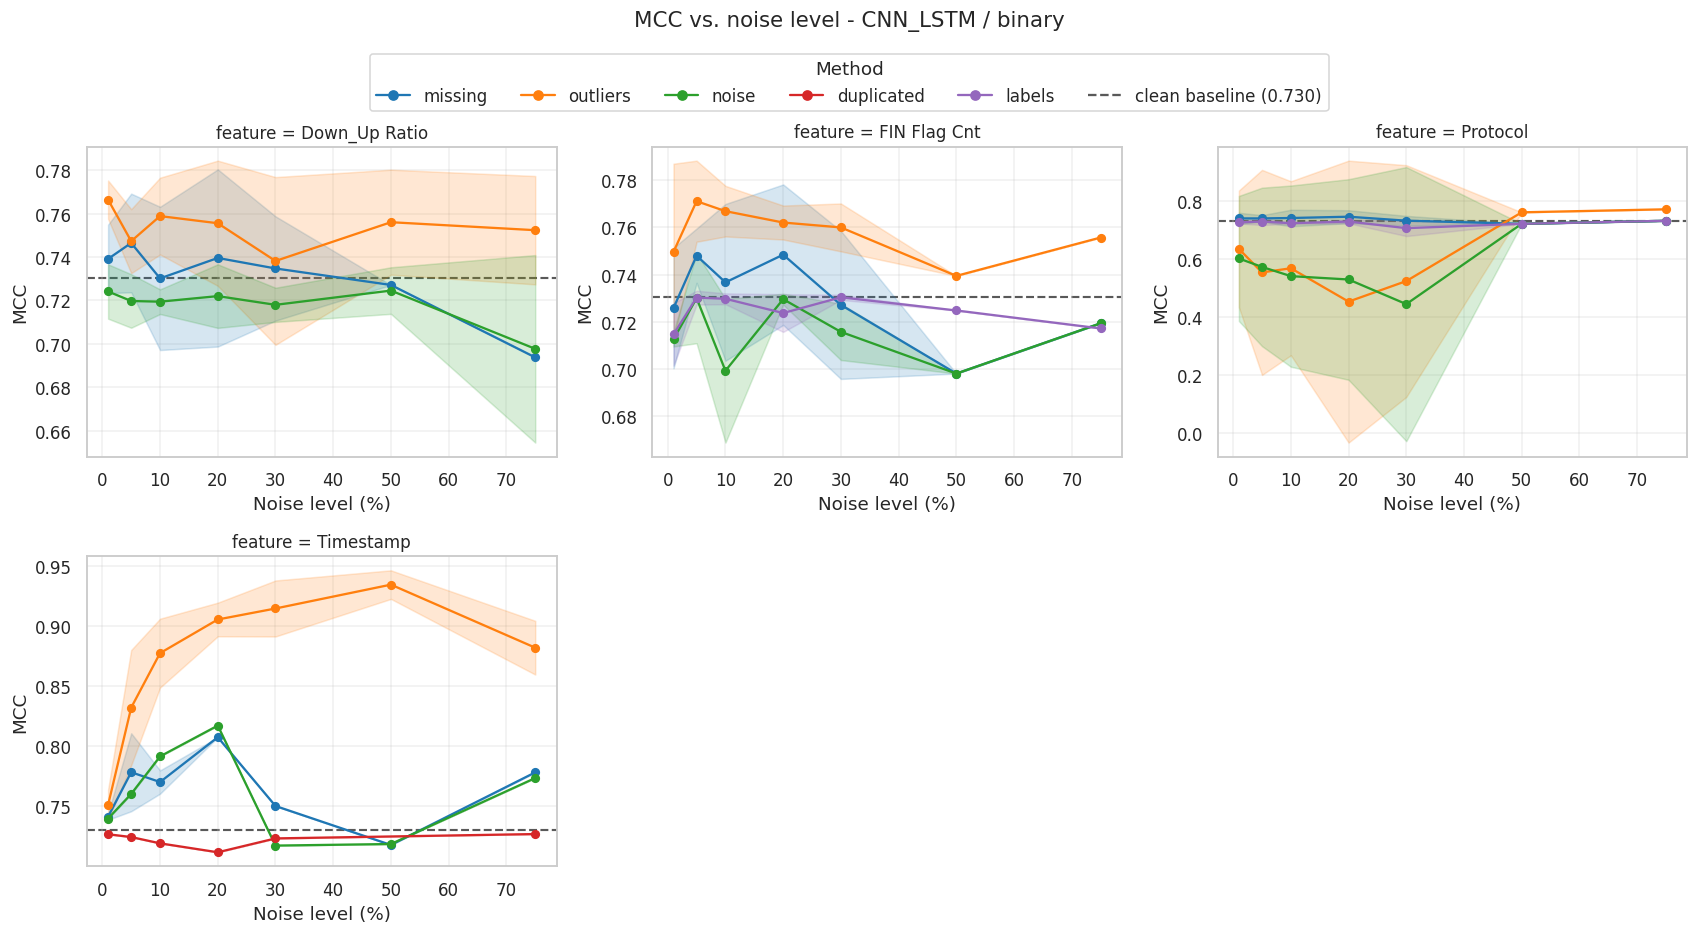

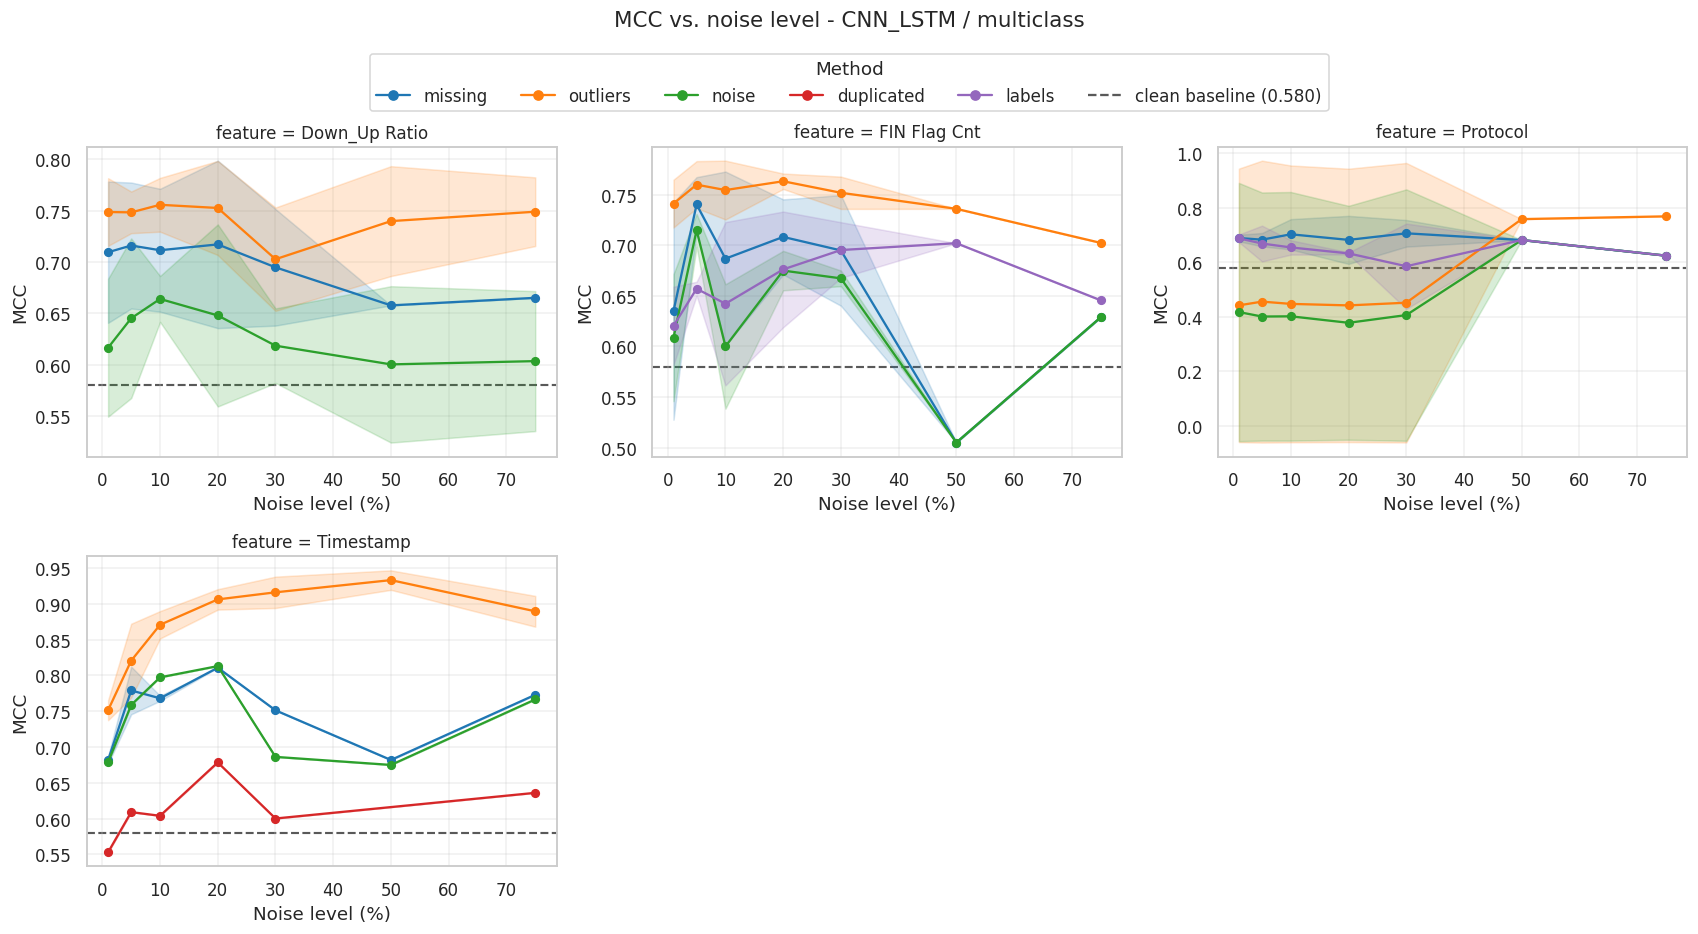

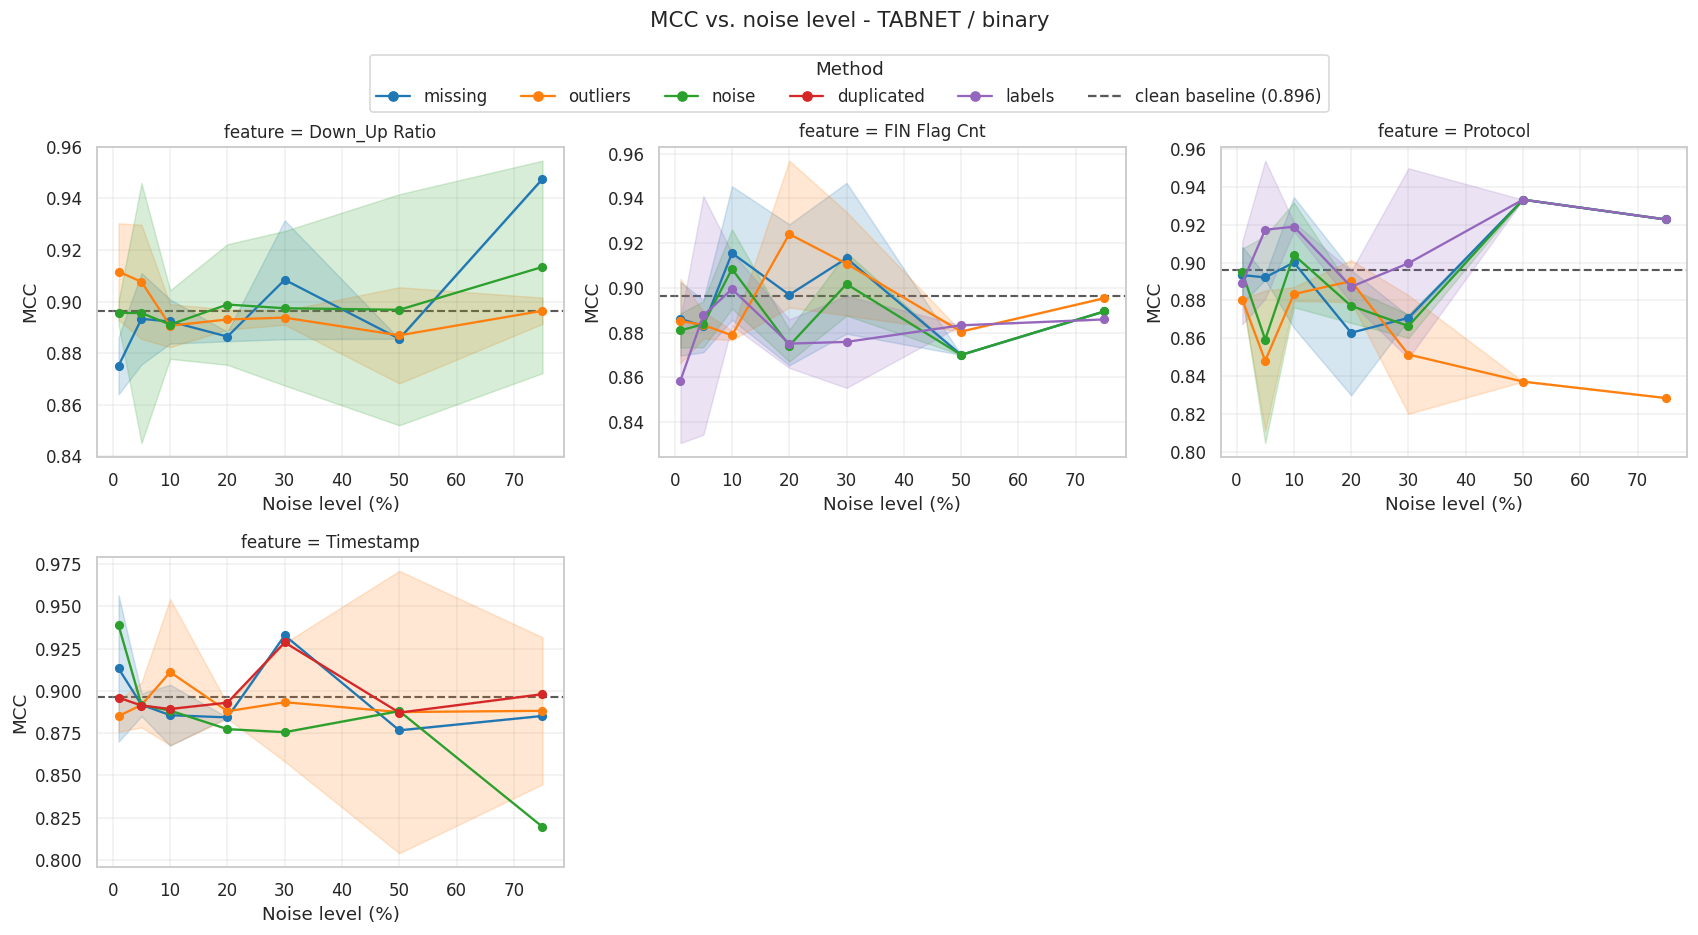

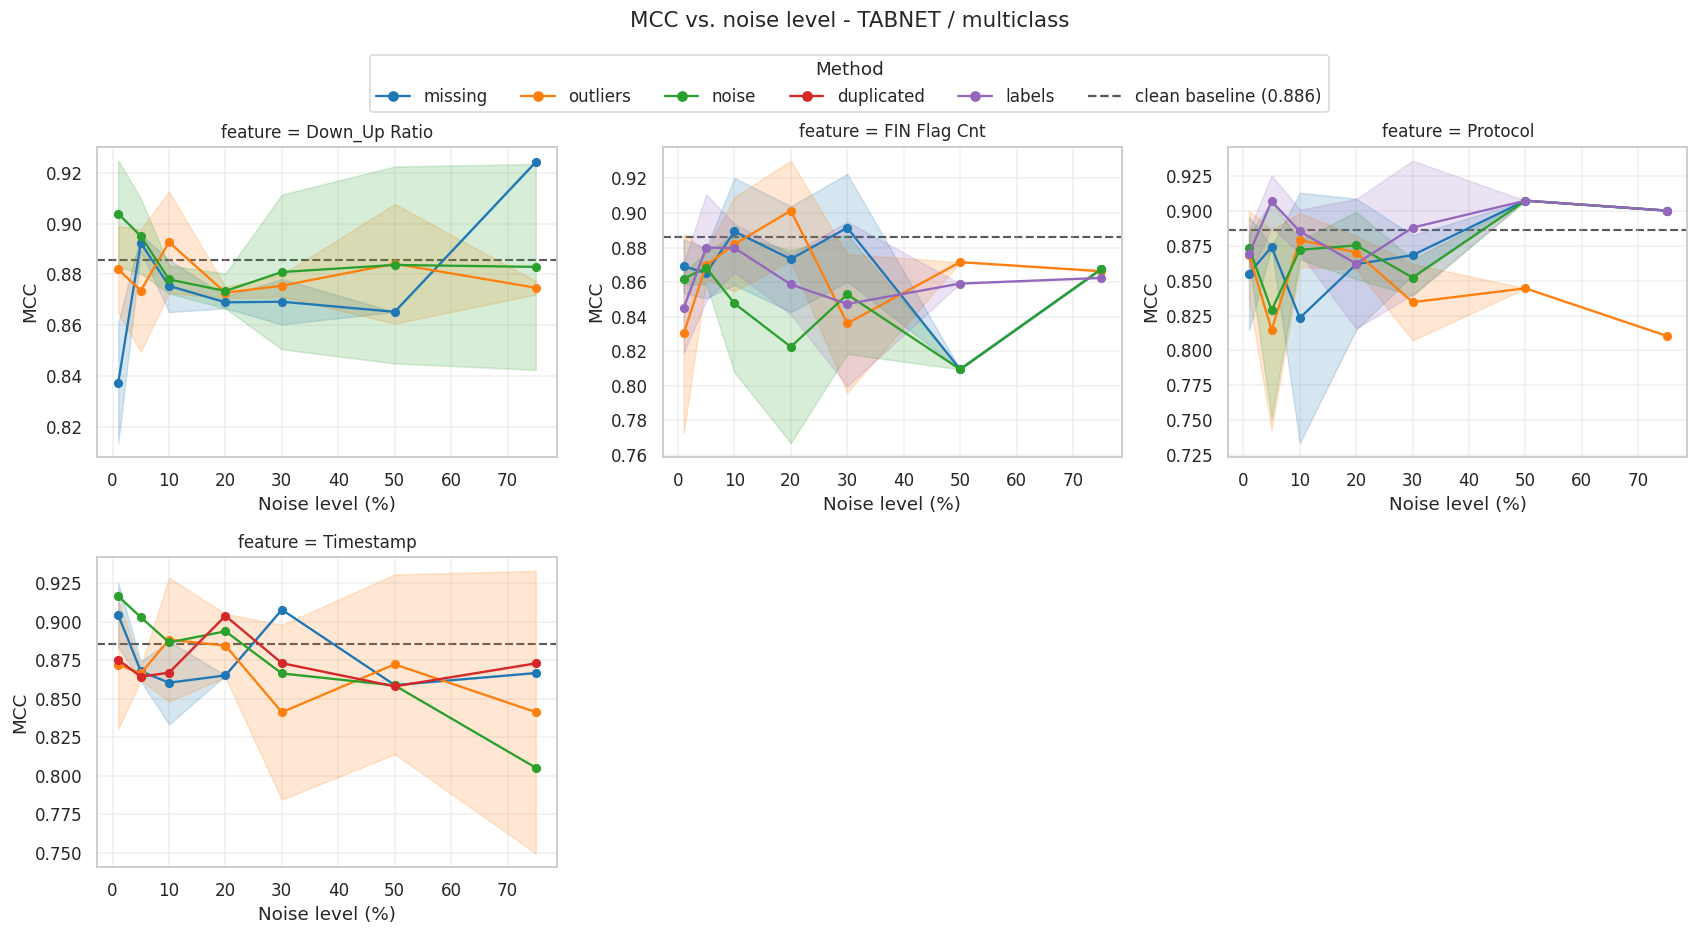

In [28]:
def trend_figs(metric):
    if not HAS_DATA:
        print("No data yet."); return
    for model in MODELS:
        for task in TASKS:
            save = (os.path.join(RESULTS_DIR, "figures",
                                 f"{metric}_{model}_{task}_by_feature.png")
                    if SAVE_FIGURES else None)
            fig = eu.plot_metric_vs_noise(df, model, task, metric,
                                          conf=CONF_LEVEL, facet_by="feature",
                                          hue="method", baselines=BL, savepath=save)
            if fig is not None:
                plt.show()

trend_figs("mcc")

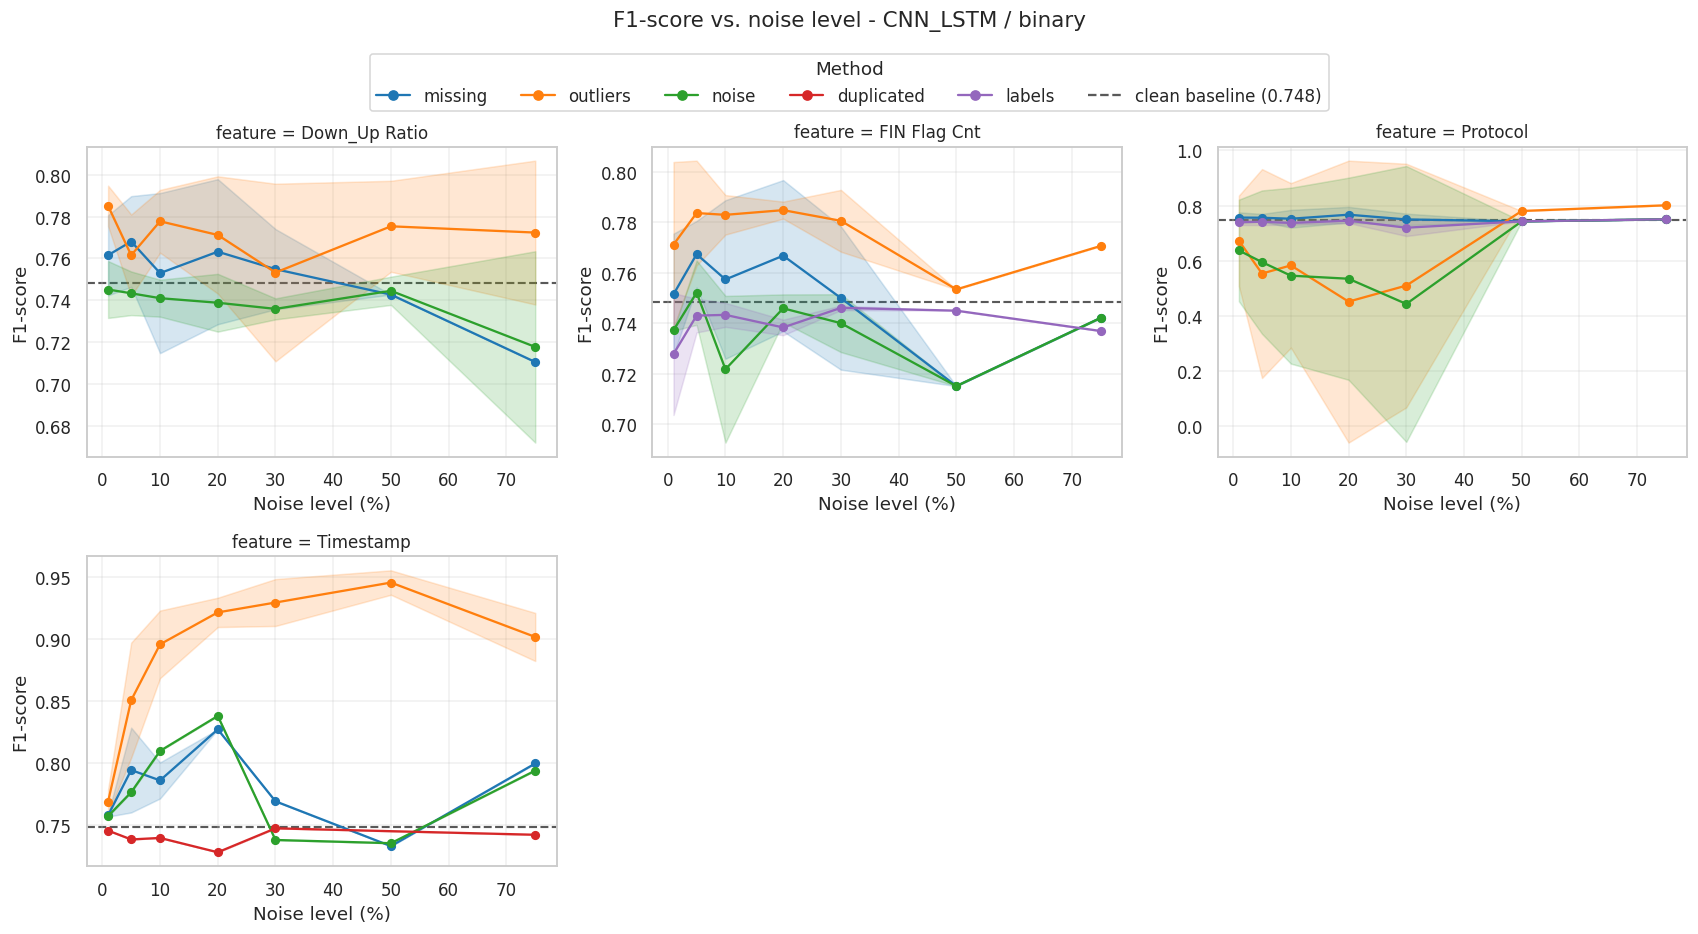

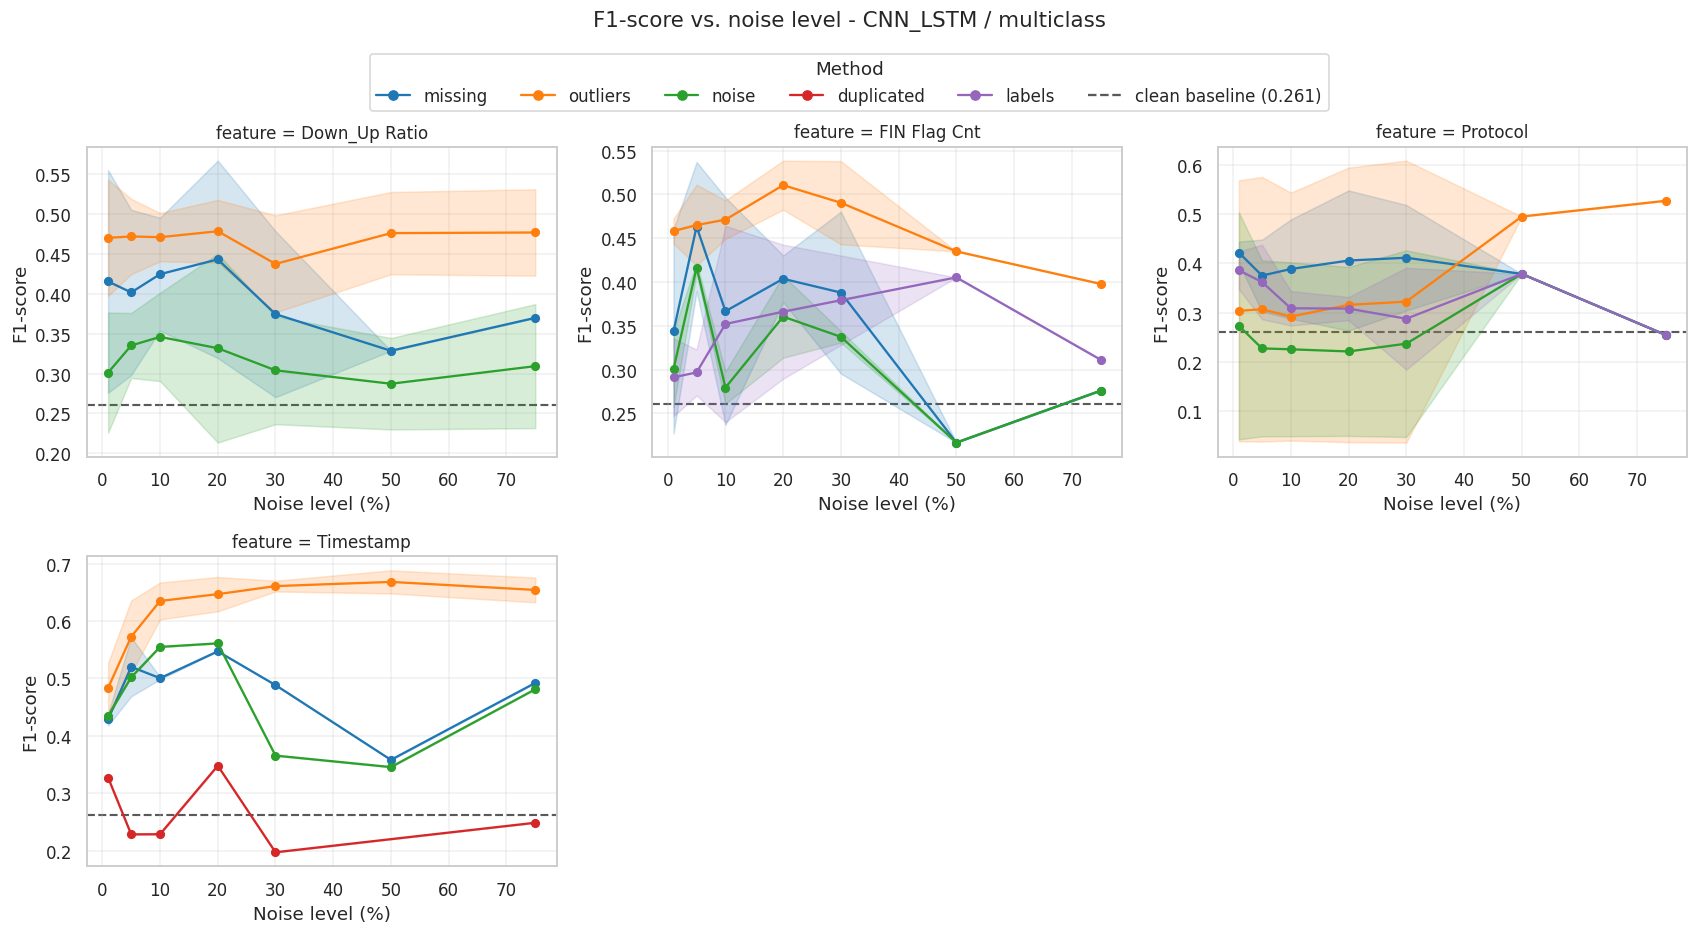

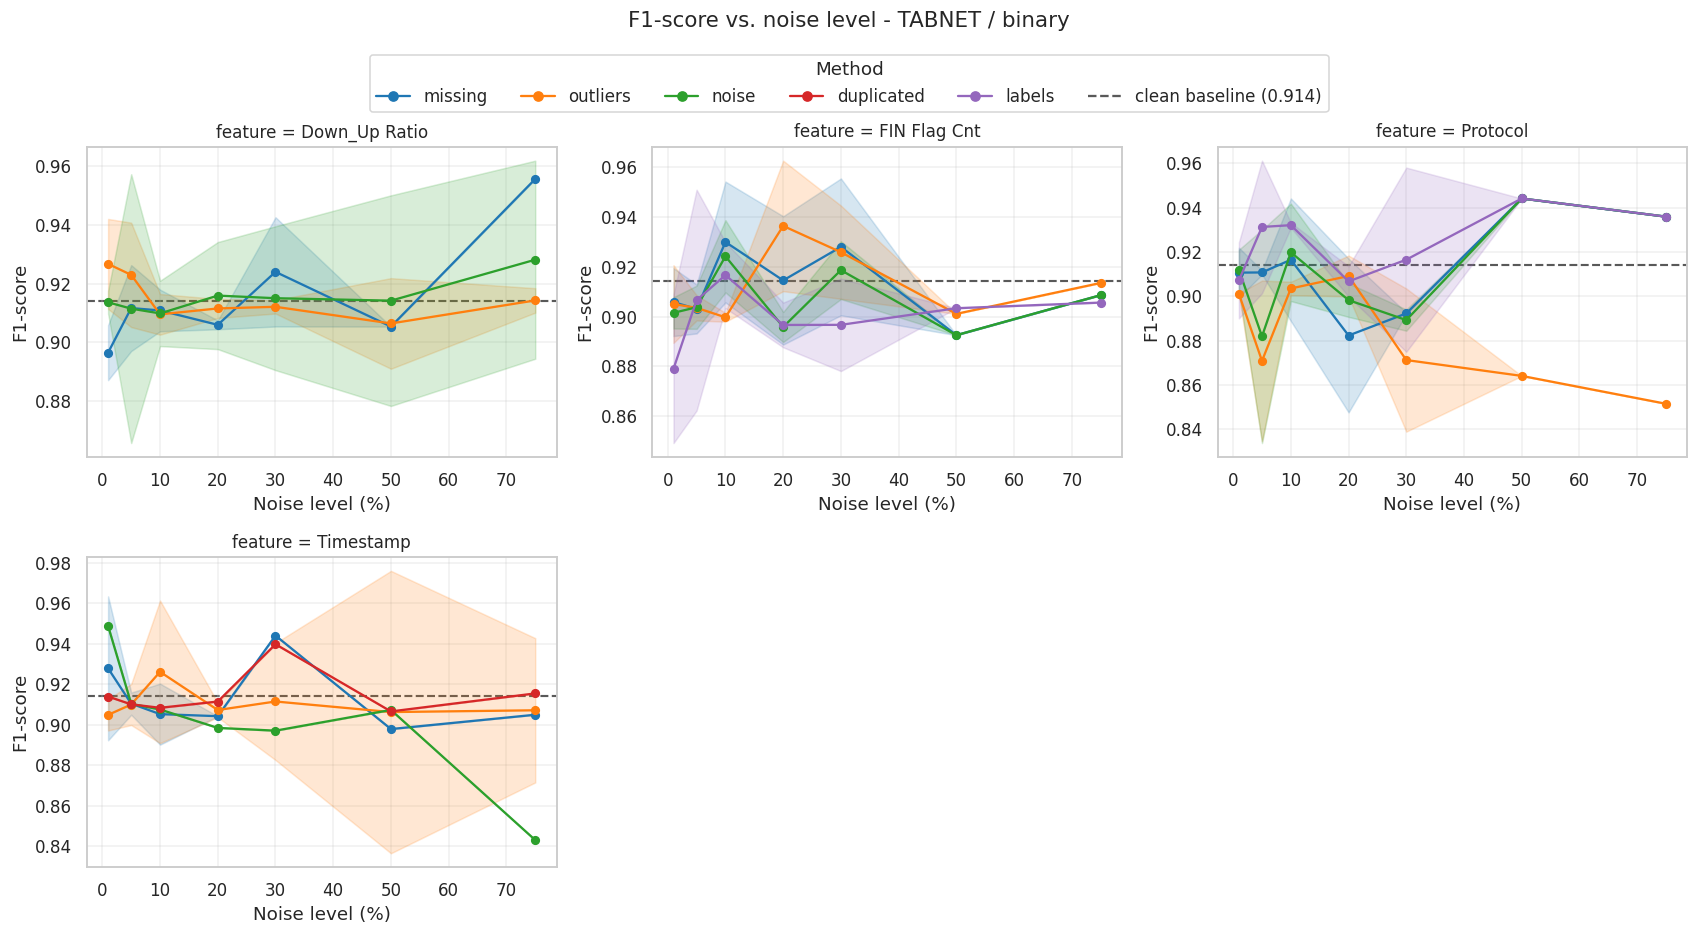

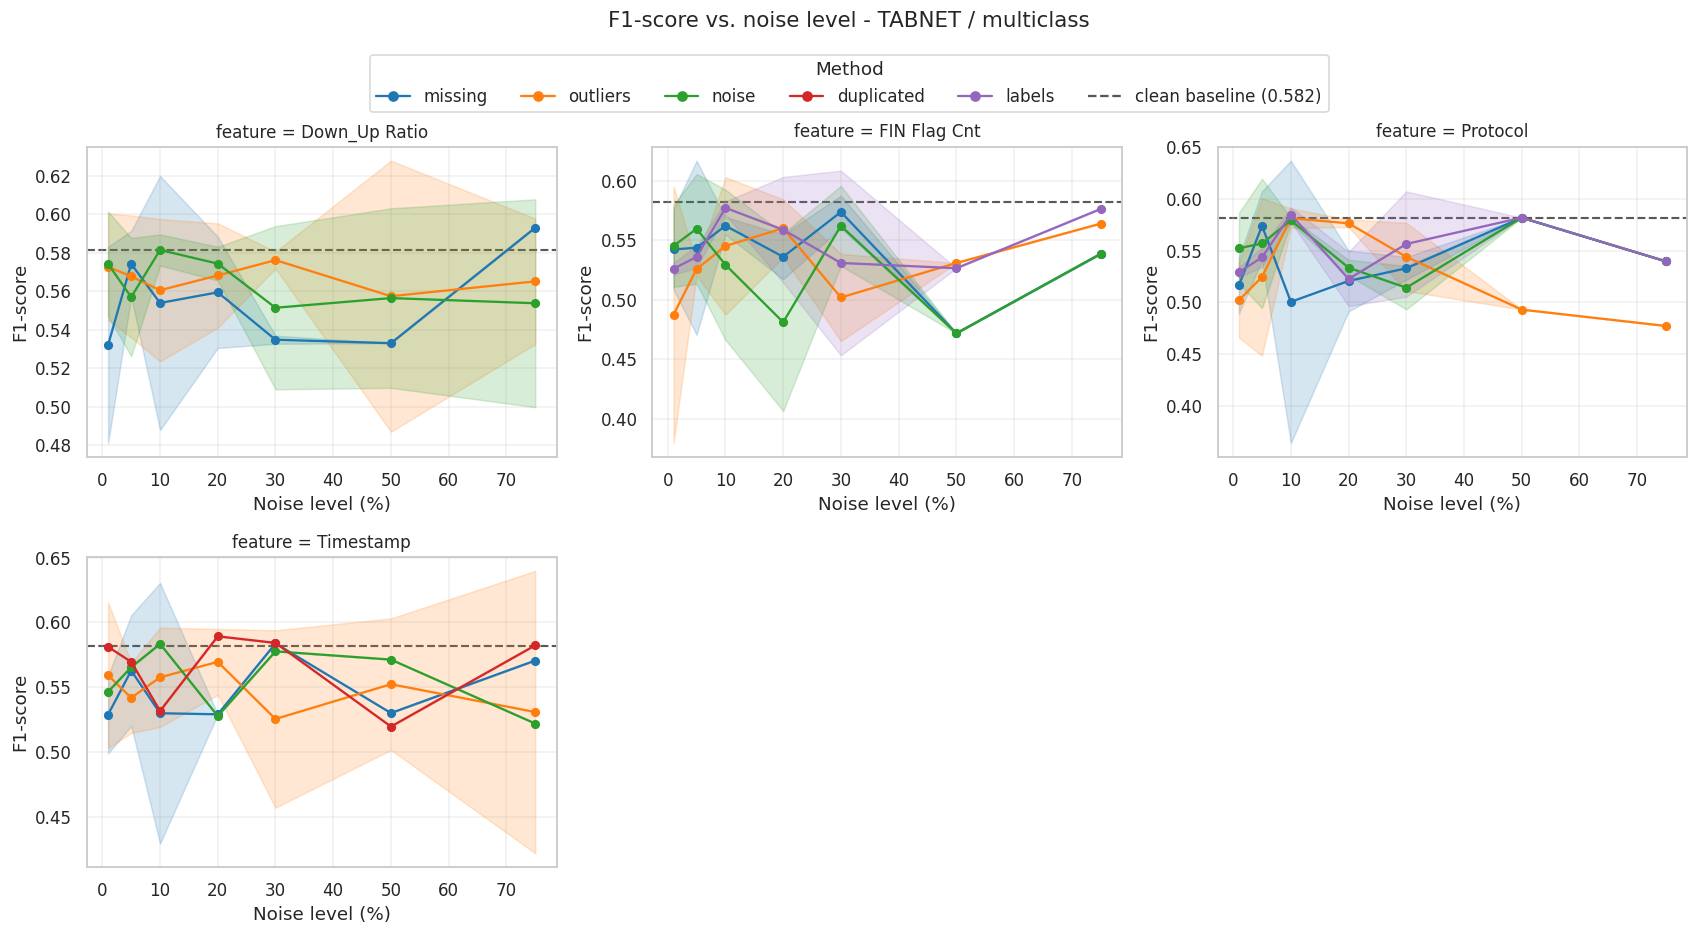

In [29]:
trend_figs("f1")

### Alternative view: one subplot per method, one line per feature

Swapping the facet and hue answers the dual question: *for a given corruption
method, which features are the most sensitive?* (shown for the binary task; edit
`task`/`metric` to explore).

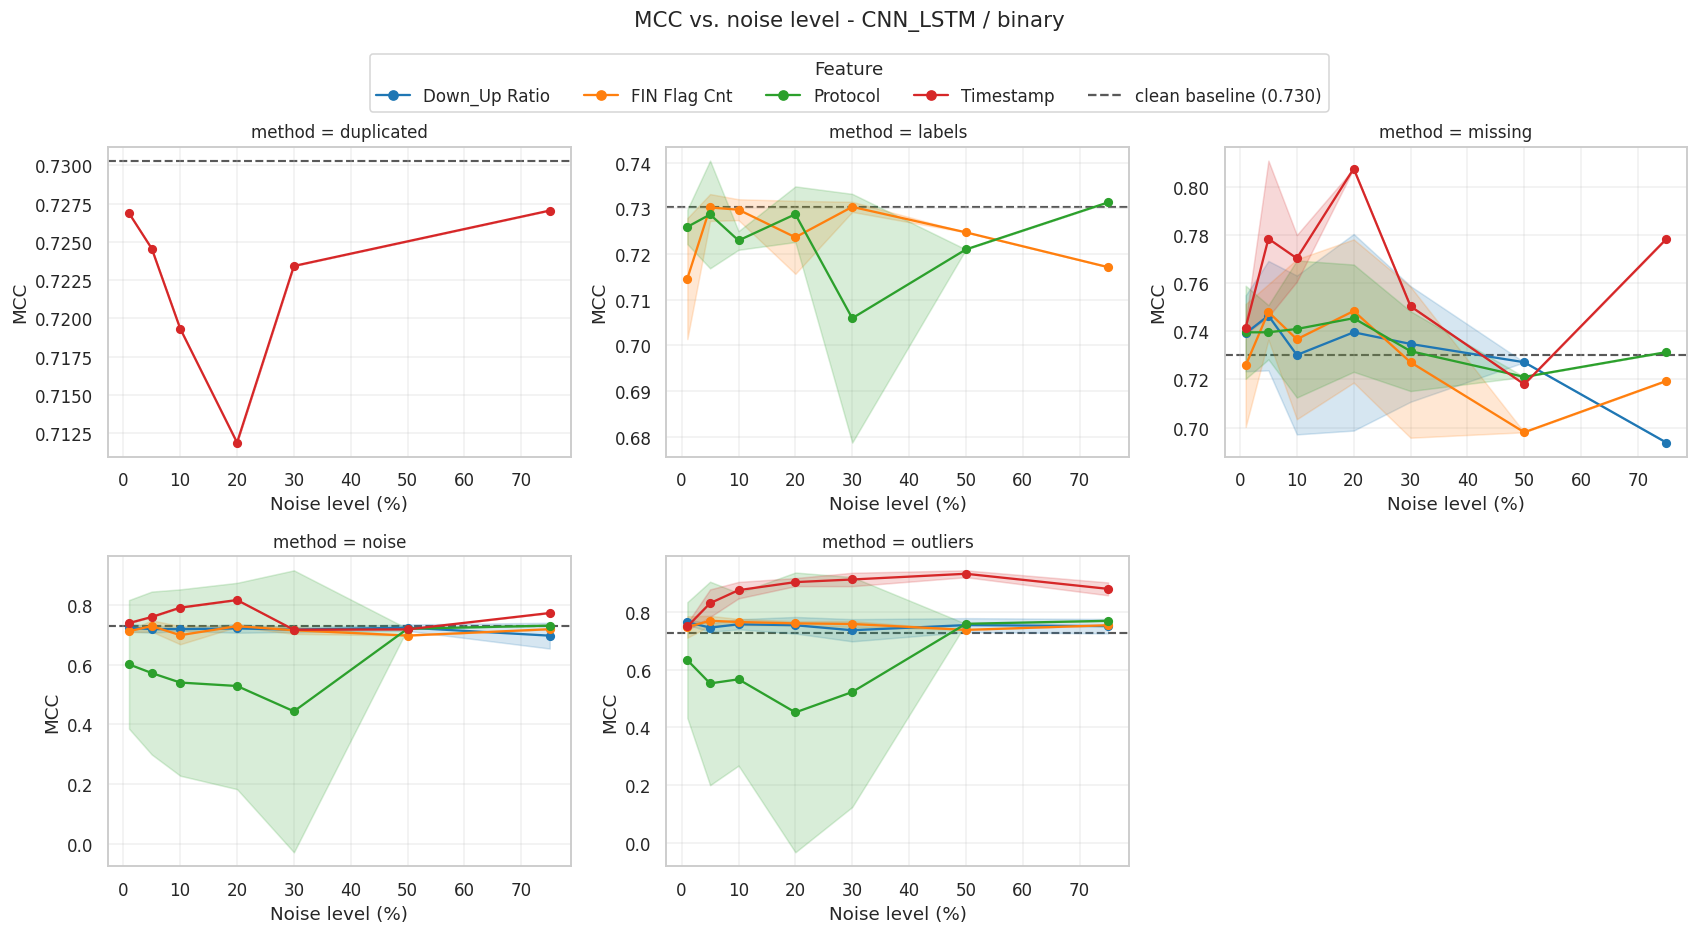

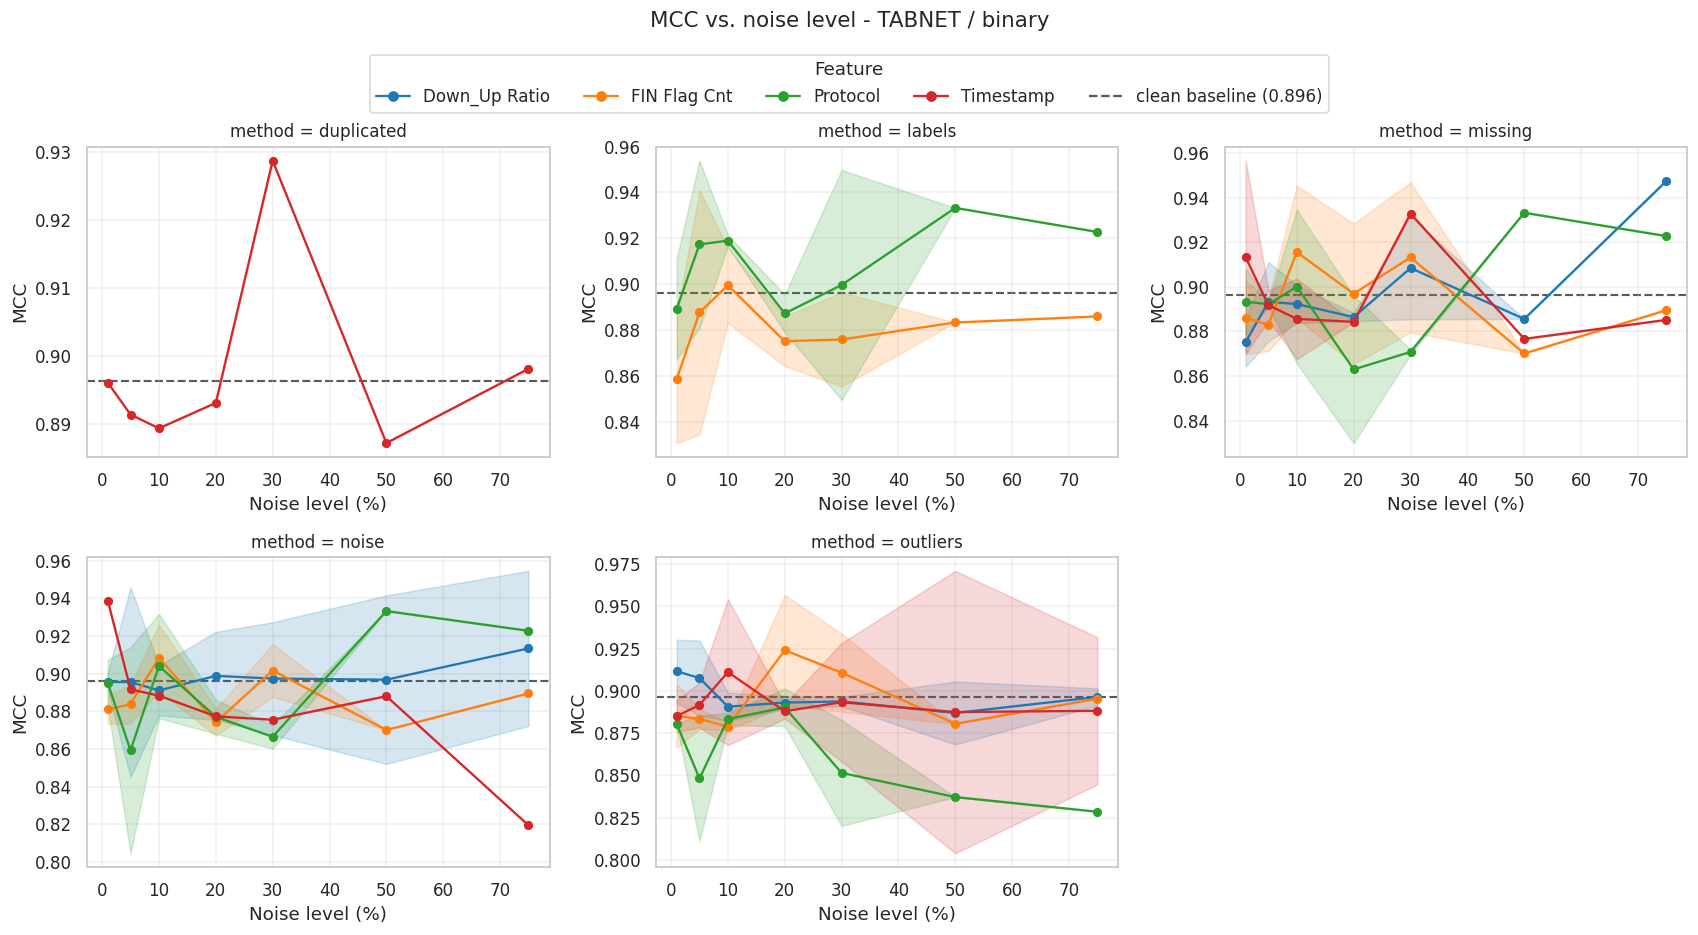

In [30]:
if HAS_DATA:
    for model in MODELS:
        fig = eu.plot_metric_vs_noise(df, model, "binary", "mcc",
                                      conf=CONF_LEVEL, facet_by="method",
                                      hue="feature", baselines=BL)
        if fig is not None:
            plt.show()

## 5. Heatmaps &mdash; method &times; noise level

Heatmaps condense the same information into compact, manuscript-friendly
figures. We show the **delta vs. the clean baseline** (diverging colour map
centred at zero): **blue = beats the clean model, red = worse than clean**. This
makes the "noise helped here" cells pop out at a glance.

> If the clean baseline is missing the function falls back to the lowest noise
> level as a proxy reference (`delta_vs_ref`).

Heatmaps show the change vs the CLEAN baseline (blue = beats clean).


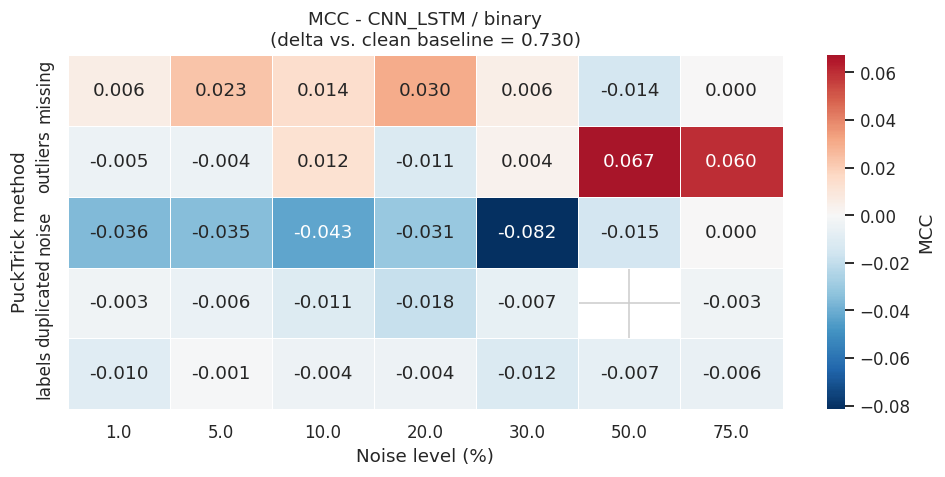

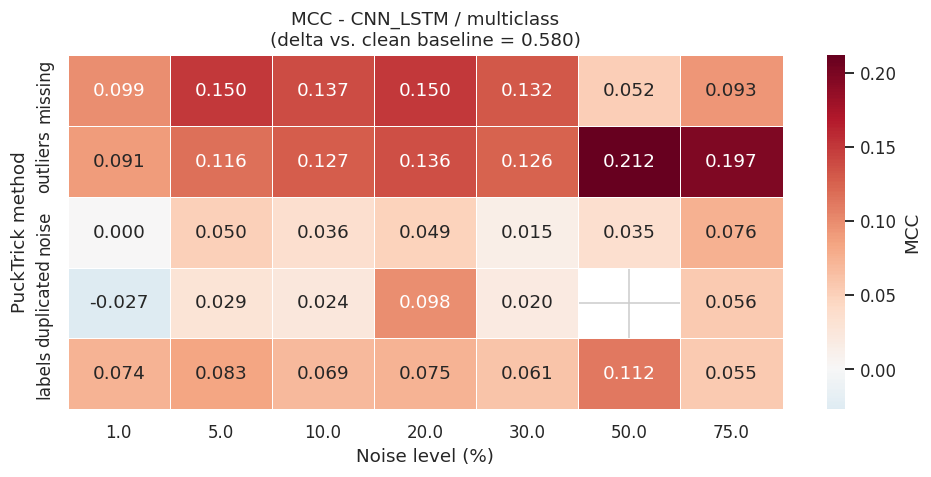

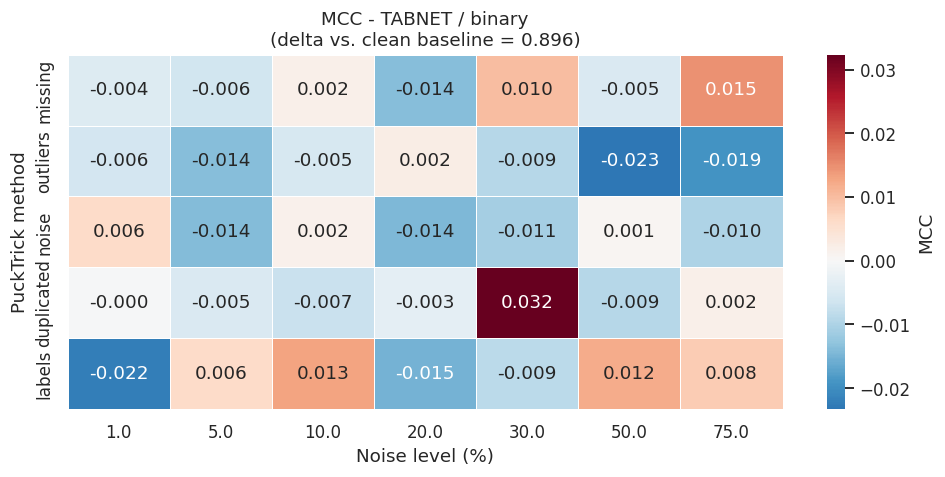

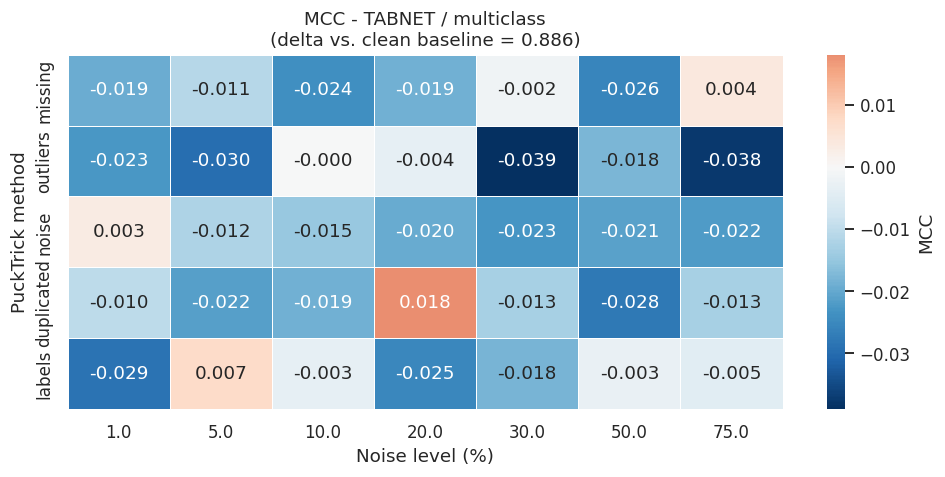

In [31]:
if HAS_DATA:
    if HAS_BASELINE:
        print("Heatmaps show the change vs the CLEAN baseline (blue = beats clean).")
    else:
        ref = eu.reference_level(df)
        print(f"No clean baseline; using lowest noise level {ref:g}% as proxy reference.")
    for model in MODELS:
        for task in TASKS:
            fig = eu.plot_metric_heatmap(df, model, task, "mcc",
                                         delta_vs_baseline=HAS_BASELINE, baselines=BL,
                                         delta_vs_ref=not HAS_BASELINE)
            if fig is not None:
                plt.show()

## 6. Is the change real? &mdash; significance tests

Overlapping error bars are not a verdict. We run **two complementary Wilcoxon
signed-rank tests**, both at the 5% level:

**(6a) vs. the clean baseline &mdash; the headline test.** For each
`(method, feature, noise%)` we test whether the per-seed metric values differ
from the **clean-baseline scalar** (one-sample Wilcoxon of `value - baseline`
against zero). This answers the thesis' core question directly: *does injecting
this noise beat (or hurt) the model trained on clean data?* The configurations
with `median_delta > 0` and `p < 0.05` are the defensible **"noise helped vs.
clean"** claims.

**(6b) vs. the lowest noise level &mdash; a within-grid trend check.** Pairs each
seed's metric with the *same seed's* metric at the lowest noise level. Pairing by
seed cancels seed-to-seed variance; it tells us whether *increasing* the noise
beyond the mildest setting moves the metric.

> With few seeds the test has limited power, so absence of significance is *not*
> evidence of no effect; always read it next to `n`.

In [32]:
# (6a) vs the CLEAN baseline -- the headline 'does noise beat clean?' test.
def baseline_significance(metric, task="binary"):
    if not (HAS_DATA and HAS_BASELINE):
        return pd.DataFrame()
    out = [eu.baseline_delta_significance(df, BL, m, task, metric) for m in MODELS]
    out = [o for o in out if not o.empty]
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

bsig_mcc = baseline_significance("mcc", task="binary")
if HAS_DATA and HAS_BASELINE and not bsig_mcc.empty:
    beats = bsig_mcc[(bsig_mcc["median_delta"] > 0) & (bsig_mcc["significant"])]
    print(f"Configurations that SIGNIFICANTLY BEAT the clean baseline "
          f"(binary MCC): {len(beats)} of {len(bsig_mcc)} tested")
    display(beats.sort_values("median_delta", ascending=False).reset_index(drop=True))
    print("\nConfigurations significantly WORSE than clean (for completeness):")
    worse = bsig_mcc[(bsig_mcc["median_delta"] < 0) & (bsig_mcc["significant"])]
    display(worse.sort_values("median_delta").head(20).reset_index(drop=True))
elif HAS_DATA and not HAS_BASELINE:
    print("No clean baseline available - skipping the vs-baseline test (see 6b).")

Configurations that SIGNIFICANTLY BEAT the clean baseline (binary MCC): 0 of 209 tested


,model,method,feature,noise_percentage,n,baseline,median_value,median_delta,mean_delta,p_value,significant



Configurations significantly WORSE than clean (for completeness):


,model,method,feature,noise_percentage,n,baseline,median_value,median_delta,mean_delta,p_value,significant


In [33]:
# (6b) vs the lowest noise level -- paired within-grid trend check.
def significance(metric, task="binary"):
    if not HAS_DATA:
        return pd.DataFrame()
    ref = eu.reference_level(df)
    out = []
    for model in MODELS:
        s = eu.paired_delta_significance(df, model, task, metric, ref)
        if not s.empty:
            s.insert(0, "model", model)
            out.append(s)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

sig_mcc = significance("mcc", task="binary")
if HAS_DATA and not sig_mcc.empty:
    ref = eu.reference_level(df)
    improved = sig_mcc[(sig_mcc["median_delta"] > 0) & (sig_mcc["significant"])]
    print(f"Significant MCC changes vs the {ref:g}% level (binary): "
          f"{len(improved)} improvements of {len(sig_mcc)} tested configs")
    display(improved.sort_values("median_delta", ascending=False).reset_index(drop=True))
elif HAS_DATA:
    print("Not enough paired data to run the within-grid test yet.")

Significant MCC changes vs the 1% level (binary): 0 improvements of 179 tested configs


,model,method,feature,noise_percentage,n_pairs,median_delta,mean_delta,p_value,significant


## 7. Model comparison &mdash; TabNet vs. CNN-LSTM

Two complementary robustness summaries, averaged over all features/methods:

* **Mean metric across the whole noise grid** &mdash; overall quality under noise;
* **Degradation slope** &mdash; the linear trend of the metric vs. noise level
  (slope &approx; 0 &rarr; robust; strongly negative &rarr; fragile; positive
  &rarr; noise tends to help).

In [34]:
if HAS_DATA:
    rows = []
    for model in MODELS:
        for task in TASKS:
            sub = df[(df.model == model) & (df.task == task)]
            for metric in ["mcc", "f1"]:
                per_level = (sub.groupby("noise_percentage")[metric]
                               .mean().reset_index().dropna())
                slope = np.nan
                if len(per_level) >= 2:
                    slope = np.polyfit(per_level["noise_percentage"],
                                       per_level[metric], 1)[0]
                rows.append({"model": model, "task": task, "metric": metric,
                             "mean_over_grid": sub[metric].mean(),
                             "slope_per_pct": slope})
    comp = pd.DataFrame(rows)
    display(comp.pivot_table(index=["task", "metric"], columns="model",
                             values=["mean_over_grid", "slope_per_pct"]))

mean_over_grid           slope_per_pct          
model                   cnn_lstm    tabnet      cnn_lstm    tabnet
task       metric                                                 
binary     f1            0.74366  0.909919      0.000345  0.000007
           mcc           0.72603  0.891847      0.000329  0.000016
multiclass f1            0.38846  0.547831     -0.000204 -0.000065
           mcc           0.67140  0.870189      0.000392 -0.000058

## 8. Per-class behaviour (multiclass)

The macro MCC/F1 can mask what happens to individual **attack classes**, some
of which are rare. The artifacts do not store a per-class report, but they do
store the multiclass confusion matrix (`cm_mul`), from which per-class
precision/recall/F1 follow directly. Here we check which classes gain or lose F1
as noise increases &mdash; important because an IDS that improves overall while
collapsing on a rare-but-critical attack is *not* an improvement in practice.
(Classes are identified by integer index, since names are not stored.)

In [35]:
pcd = eu.per_class_dataframe(ROOT_DIR)
if SCENARIO is not None and not pcd.empty:
    pcd = pcd[pcd["scenario"] == SCENARIO]
if pcd.empty:
    print("No per-class data available yet.")
else:
    ref = eu.reference_level(df)
    hi = sorted(pcd["noise_percentage"].dropna().unique())[-1]
    piv = (pcd[pcd["noise_percentage"].isin([ref, hi])]
           .groupby(["model", "class", "noise_percentage"])["f1"].mean()
           .unstack("noise_percentage"))
    if ref in piv.columns and hi in piv.columns:
        piv["delta(F1)"] = piv[hi] - piv[ref]
        piv = piv.rename(columns={ref: f"F1@{ref:g}%", hi: f"F1@{hi:g}%"})
        print(f"Per-class F1 (mean over methods/features): reference {ref:g}% -> highest {hi:g}% noise")
        display(piv.sort_values("delta(F1)").round(4))

Per-class F1 (mean over methods/features): reference 1% -> highest 75% noise


noise_percentage   F1@1%  F1@75%  delta(F1)
model    class                             
cnn_lstm 6        0.7685  0.5811    -0.1874
         8        0.9002  0.7847    -0.1155
         9        0.3245  0.2714    -0.0531
tabnet   9        0.5224  0.5133    -0.0092
cnn_lstm 5        0.6223  0.6147    -0.0076
tabnet   3        0.7076  0.7011    -0.0065
         5        0.7467  0.7403    -0.0064
         1        0.9968  0.9961    -0.0007
         0        0.9818  0.9817    -0.0001
         4        0.9842  0.9867     0.0026
         7        0.0048  0.0077     0.0028
         2        0.9391  0.9420     0.0029
         8        0.5531  0.5561     0.0031
cnn_lstm 0        0.9556  0.9597     0.0042
tabnet   6        0.9640  0.9691     0.0051
cnn_lstm 1        0.8819  0.9072     0.0253
tabnet   10       0.4564  0.5021     0.0457
cnn_lstm 3        0.8104  0.8719     0.0615
         2        0.0104  0.1385     0.1282
         4        0.3492  0.5779     0.2287
         7           NaN  0.2136        NaN
         10          NaN     NaN        NaN
         11          NaN     NaN        NaN
         12          NaN     NaN        NaN
tabnet   11          NaN     NaN        NaN
         12          NaN     NaN        NaN
         13          NaN     NaN        NaN
         14          NaN     NaN        NaN

## 9. Feature-importance drift

A mechanistic check: when PuckTrick corrupts a feature, does the model's
**permutation importance** for that feature drop (it learns to ignore the
unreliable signal) or stay high (it keeps relying on noise)? We track the mean
importance of the *corrupted* feature as the noise level grows. (`is_corrupted`
is name-normalised, so the file's `Down_Up Ratio` matches the importance dict's
`Down/Up Ratio`.)

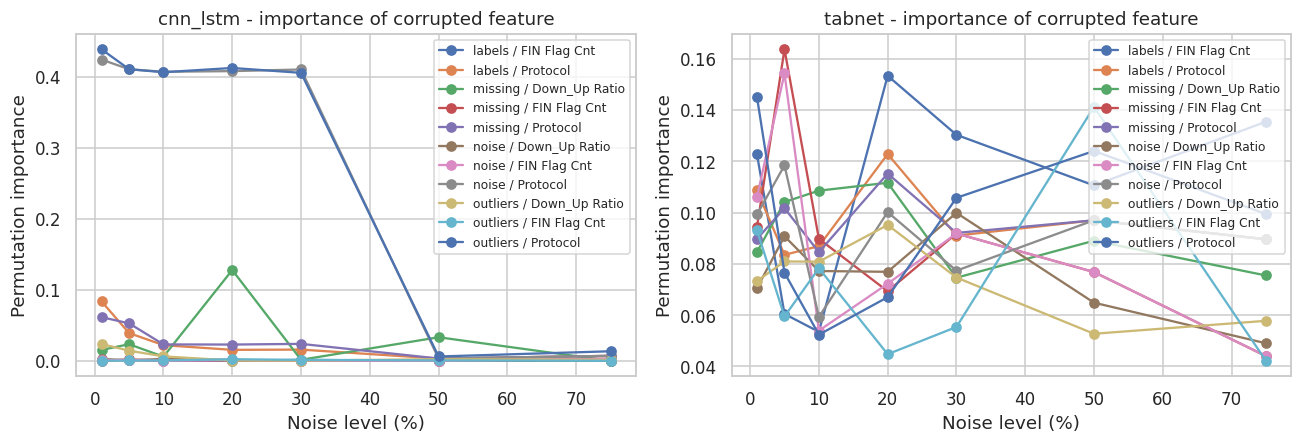

In [36]:
fid = eu.feature_importance_dataframe(ROOT_DIR)
if SCENARIO is not None and not fid.empty:
    fid = fid[fid["scenario"] == SCENARIO]
if fid.empty:
    print("No feature-importance data available yet.")
else:
    self_imp = fid[fid["is_corrupted"]]
    if self_imp.empty:
        print("Corrupted feature not found among reported importances "
              "(e.g. row-level 'duplicated'/'labels' runs); showing top features instead.")
        top = (fid.groupby(["model", "fi_feature"])["importance"].mean()
                  .reset_index().sort_values("importance", ascending=False))
        display(top.groupby("model").head(8).reset_index(drop=True))
    else:
        tab = (self_imp.groupby(["model", "method", "corrupted_feature",
                                 "noise_percentage"])["importance"]
                       .mean().reset_index())
        models_here = sorted(tab["model"].dropna().unique())
        fig, axes = plt.subplots(1, len(models_here),
                                 figsize=(6 * len(models_here), 4.2), squeeze=False)
        for ax, model in zip(axes[0], models_here):
            for (mth, feat), g in tab[tab.model == model].groupby(["method", "corrupted_feature"]):
                g = g.sort_values("noise_percentage")
                ax.plot(g["noise_percentage"], g["importance"], marker="o",
                        label=f"{mth} / {feat}")
            ax.set_title(f"{model} - importance of corrupted feature")
            ax.set_xlabel("Noise level (%)"); ax.set_ylabel("Permutation importance")
            ax.legend(fontsize=8)
        plt.tight_layout(); plt.show()

## 9b. Importance-rank drift of the corrupted feature

Section 9 plots *absolute* permutation importance, which is hard to compare
across noise levels (the whole importance vector can rescale). Here we instead
track the corrupted feature's **position (rank)** in the importance ordering
(rank 1 = the feature the model relies on most), which is a stable, directly
interpretable signal.

* **one subplot per corrupted feature**, the panels **ordered by clean-baseline
  importance** (most important feature top-left, then left-to-right and down);
* **one line per PuckTrick method**;
* the **y-axis runs from 1 (top) to 10 (bottom)**, so rank 1 is at the top, and
  **each point is annotated with the exact position it sits on** (dot and label
  always agree);
* a **dashed line** marks the feature's position in the clean baseline (also
  shown as `baseline #k` in each panel title).

**How the position is computed.** For each (method, noise level) we first average
each feature's permutation importance over the seeds, *then* rank those averages.
This gives a genuine integer position in the ordering. (Averaging the per-seed
ranks instead would give a fractional number that corresponds to no real
position &mdash; the dot would not match its own label.)

Reading guide: a line that *descends* (position number grows) means that
corrupting the feature makes the model **demote** it &mdash; it learns to stop
trusting an unreliable input; a line that stays near the top means the model
keeps leaning on the feature despite the noise.

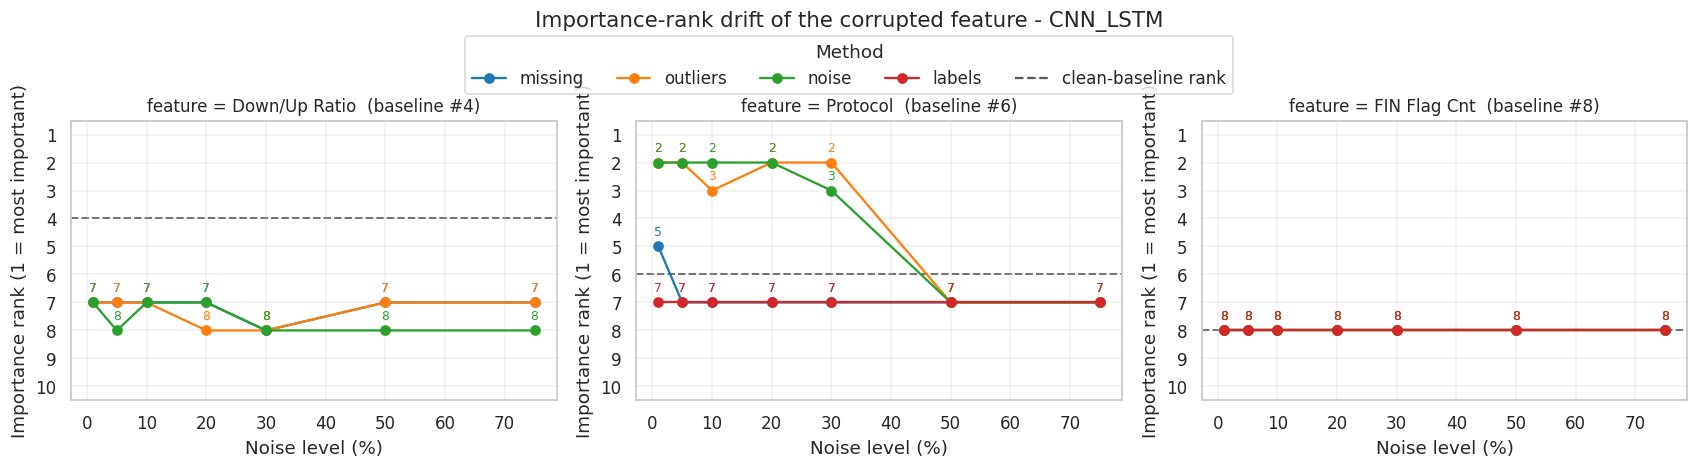

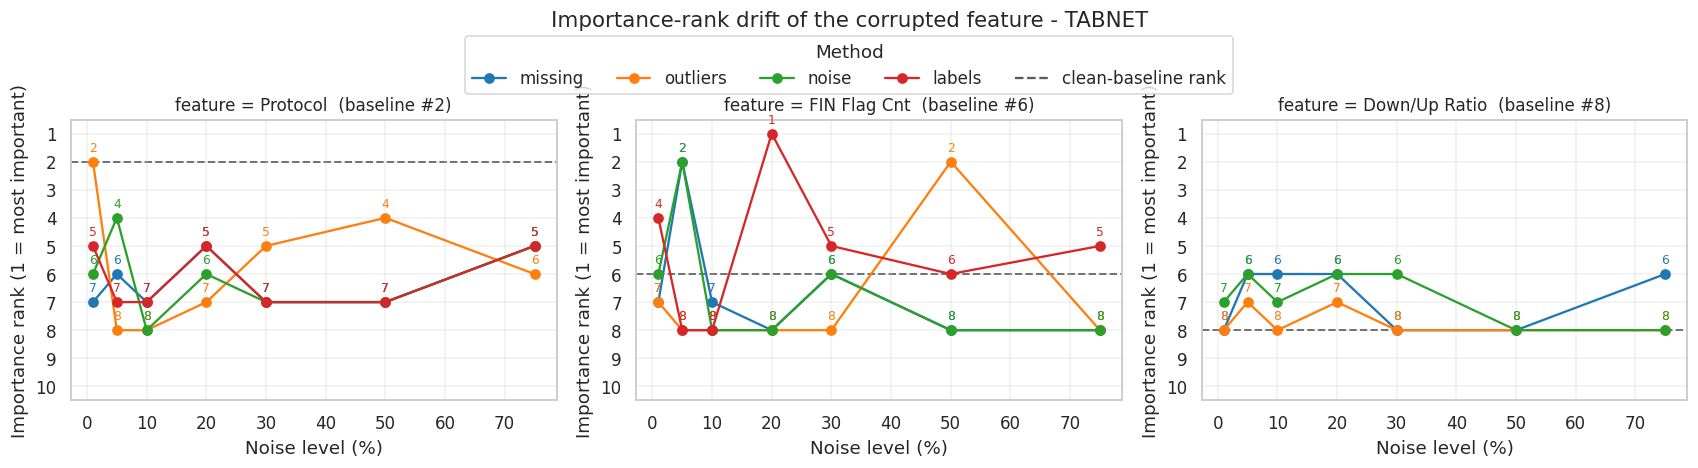

In [37]:
# fid was filtered to SCENARIO in section 9; build the clean-baseline ranks too.
bfi = eu.baseline_feature_importance(ROOT_DIR)
if 'fid' not in dir() or fid is None or fid.empty:
    print("No feature-importance data available yet.")
else:
    for model in sorted(fid["model"].dropna().unique()):
        save = (os.path.join(RESULTS_DIR, "figures", f"rank_drift_{model}.png")
                if SAVE_FIGURES else None)
        fig = eu.plot_feature_rank_drift(fid, model, baseline_fi=bfi, savepath=save)
        if fig is not None:
            plt.show()

## 10. Export for the thesis

Aggregated tables are written to CSV under `RESULTS_DIR` so they can be pulled
straight into the LaTeX sources in `temp-latex` (e.g. with `pandas.to_latex` or
`pgfplots`). Re-running regenerates them from whatever is currently on disk.

In [38]:
if HAS_DATA:
    for metric in ["mcc", "f1", "accuracy"]:
        eu.export_aggregate(df, metric, RESULTS_DIR, conf=CONF_LEVEL)
    if not sig_mcc.empty:
        sig_mcc.to_csv(os.path.join(RESULTS_DIR, "significance_mcc_binary_vs_lownoise.csv"),
                       index=False)
        print("[export] significance_mcc_binary_vs_lownoise.csv")
    if HAS_BASELINE and not bsig_mcc.empty:
        bsig_mcc.to_csv(os.path.join(RESULTS_DIR, "significance_mcc_binary_vs_baseline.csv"),
                        index=False)
        print("[export] significance_mcc_binary_vs_baseline.csv")
    if HAS_BASELINE:
        BL.to_csv(os.path.join(RESULTS_DIR, "baseline_metrics.csv"), index=False)
        print("[export] baseline_metrics.csv")
    print("\nExports written to:", RESULTS_DIR)

[export] mcc: 418 rows -> evaluation_results/Experiment_A/aggregate_mcc.csv
[export] f1: 418 rows -> evaluation_results/Experiment_A/aggregate_f1.csv
[export] accuracy: 418 rows -> evaluation_results/Experiment_A/aggregate_accuracy.csv
[export] significance_mcc_binary_vs_lownoise.csv
[export] significance_mcc_binary_vs_baseline.csv
[export] baseline_metrics.csv

Exports written to: evaluation_results/Experiment_A


## 11. Auto-generated summary &amp; conclusions

A programmatic digest of the key numbers &mdash; a *starting point* for the
chapter's prose, recomputed every run so it never goes stale. Treat it as
scaffolding to be edited into academic English, not as final text.

In [39]:
def auto_summary():
    if not HAS_DATA:
        print("No data yet - nothing to summarise.")
        return
    ref = eu.reference_level(df)
    lines = []
    lines.append(f"Experiment {PHASE} - automatic evaluation summary")
    lines.append("=" * 60)
    lines.append(f"Runs parsed        : {len(df)//2} artifacts "
                 f"({df['seed'].nunique()} seeds, models={sorted(df['model'].dropna().unique())})")
    if HAS_BASELINE:
        for model in sorted(BL['model'].dropna().unique()):
            bv = eu.baseline_value(BL, model, 'binary', 'mcc')
            lines.append(f"Clean baseline MCC : {bv:.3f}  ({model}, binary)")
    else:
        lines.append(f"Reference level    : {ref:g}% (no clean baseline on disk; proxy)")

    bb = eu.aggregate_with_ci(df[df.task == 'binary'],
                              ['model','method','feature','noise_percentage'], 'mcc')
    if not bb.empty:
        top = bb.sort_values('mean', ascending=False).iloc[0]
        lines.append("")
        lines.append(f"Best binary MCC    : {top['mean']:.3f} "
                     f"({top['model']}, {top['method']} on {top['feature']} "
                     f"@ {top['noise_percentage']:g}%, n={int(top['n'])})")

    if HAS_BASELINE:
        n_beat = 0
        for model in df['model'].dropna().unique():
            s = eu.baseline_delta_significance(df, BL, model, 'binary', 'mcc')
            if not s.empty:
                n_beat += int(((s['median_delta'] > 0) & s['significant']).sum())
        lines.append(f"Beat clean baseline: {n_beat} (model x method x feature x level) "
                     f"configurations significantly beat clean (Wilcoxon p<0.05)")
    n_imp = 0
    for model in df['model'].dropna().unique():
        s = eu.paired_delta_significance(df, model, 'binary', 'mcc', ref)
        if not s.empty:
            n_imp += int(((s['median_delta'] > 0) & s['significant']).sum())
    lines.append(f"Sig. vs {ref:g}% level : {n_imp} configs improve over the lowest noise level")
    print("\n".join(lines))

auto_summary()

Experiment A - automatic evaluation summary
Runs parsed        : 983 artifacts (5 seeds, models=['cnn_lstm', 'tabnet'])
Clean baseline MCC : 0.730  (cnn_lstm, binary)
Clean baseline MCC : 0.896  (tabnet, binary)

Best binary MCC    : 0.948 (tabnet, missing on Down_Up Ratio @ 75%, n=4)
Beat clean baseline: 0 (model x method x feature x level) configurations significantly beat clean (Wilcoxon p<0.05)
Sig. vs 1% level : 0 configs improve over the lowest noise level


## 12. Confusion breakdown vs. the clean baseline (per noise level)

This section opens up the binary confusion matrix that the headline MCC/F1
summarise. For a **chosen PuckTrick method** it produces, **for both models**,
**every corrupted feature** and **every noise percentage**, a *baseline vs.
experiment* figure:

* two stacked bars per panel &mdash; *Benign (actual)* split into correct=**TN**
  and wrong=**FP**, *Malicious (actual)* split into correct=**TP** and
  wrong=**FN**;
* each count is the **mean over the 5 random seeds** of that cell;
* every experiment segment is annotated with its **signed change vs. the clean
  baseline** (so you see exactly how far each mean has moved &mdash; e.g. fewer
  false positives, more false negatives);
* the footer reports **&Delta;MCC** (as requested, in place of &Delta;F1) and
  **&Delta;FP**, all relative to the clean baseline.

This is the operational read of the trade-off behind a change in MCC: a tiny
MCC shift can hide a meaningful redistribution between false alarms (FP) and
missed attacks (FN), which matters a great deal for an IDS.

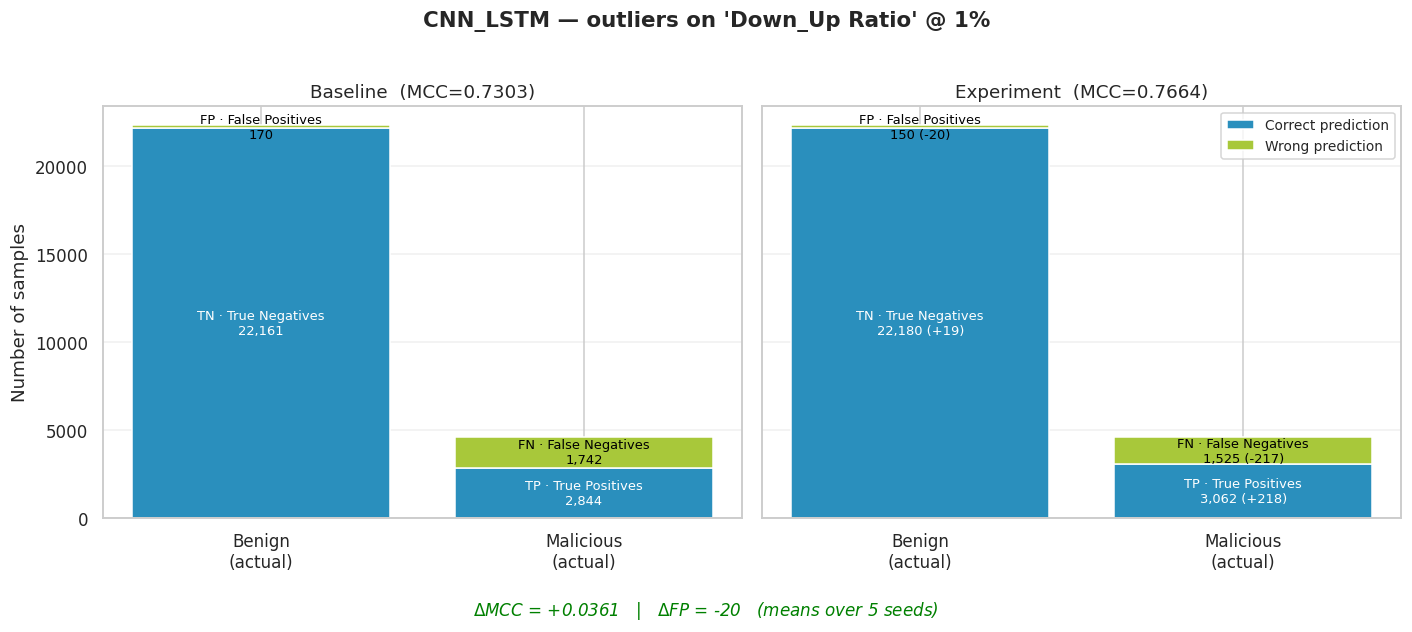

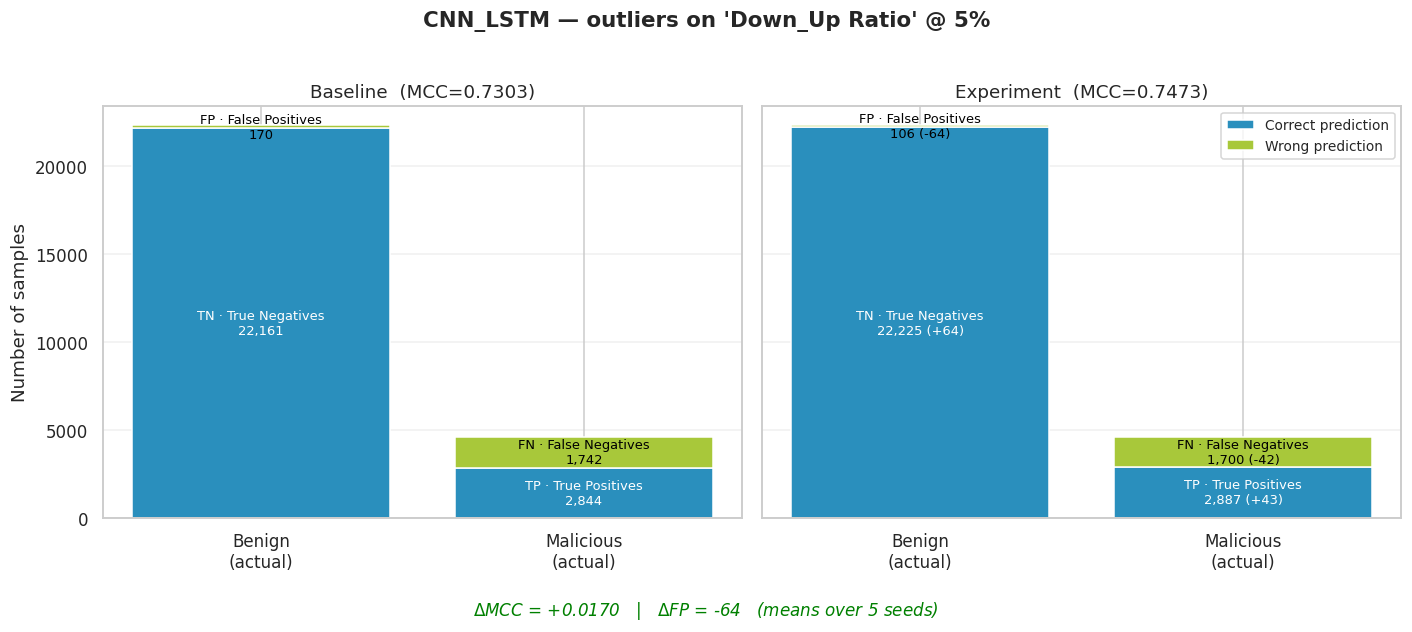

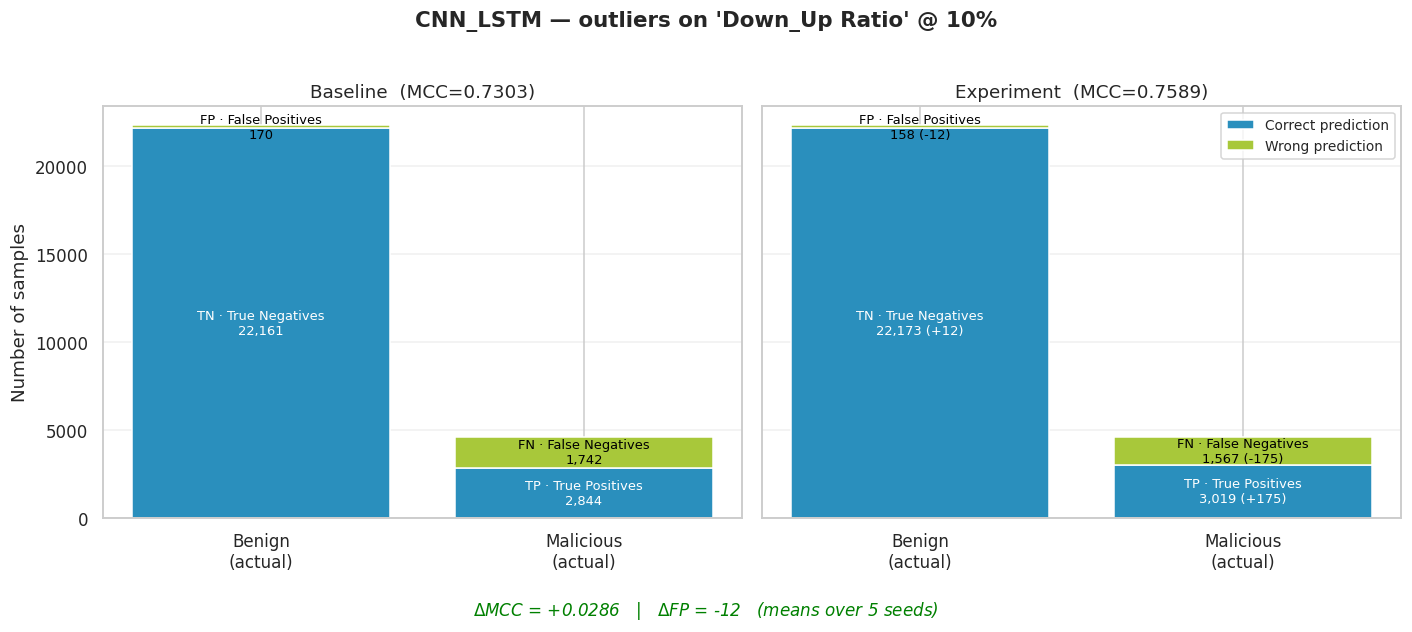

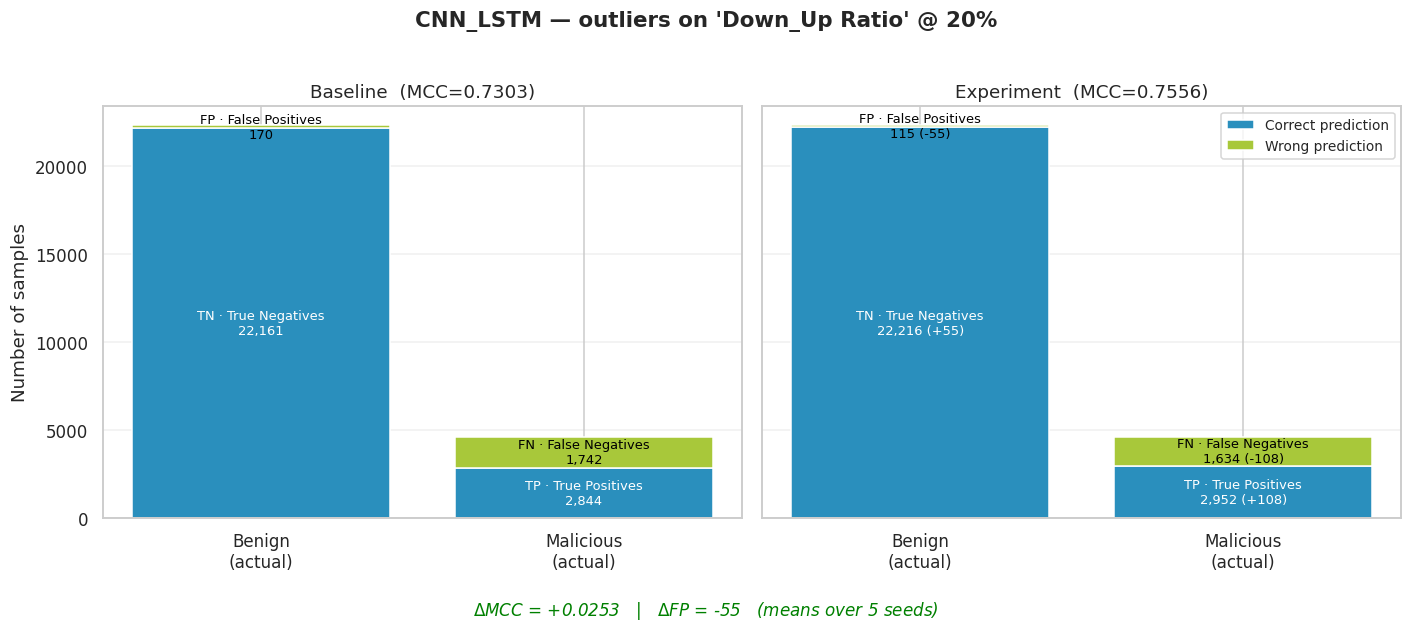

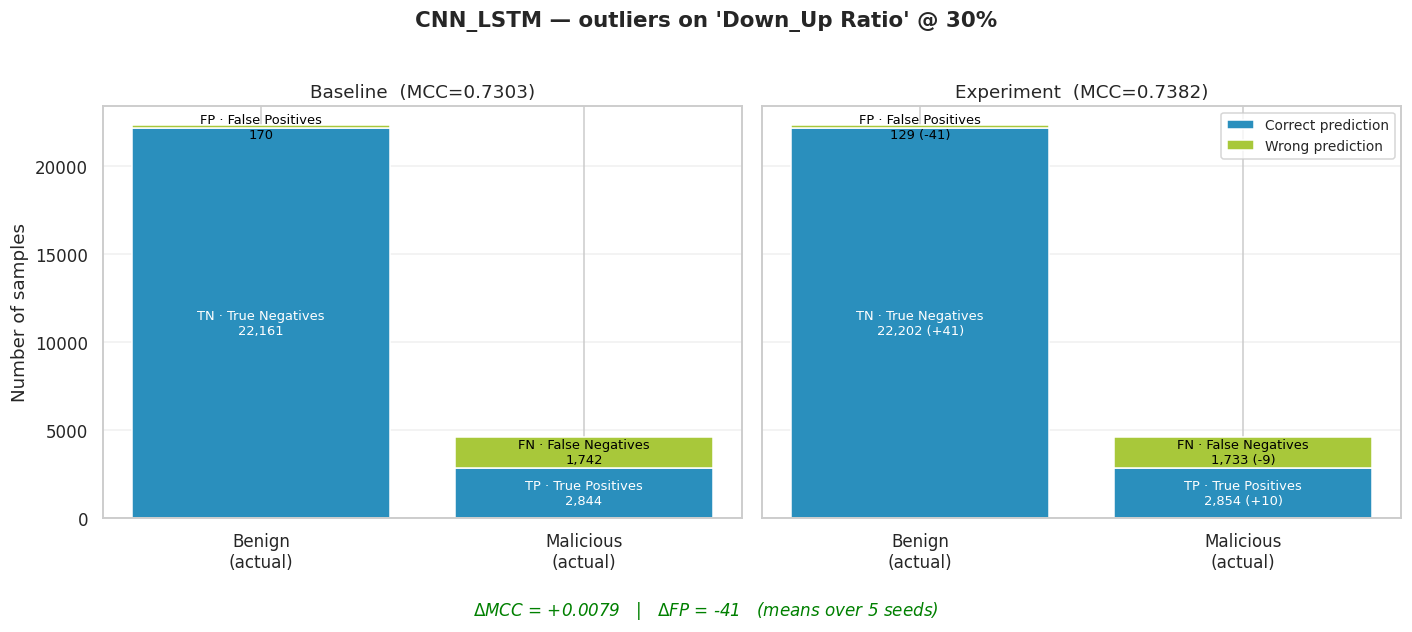

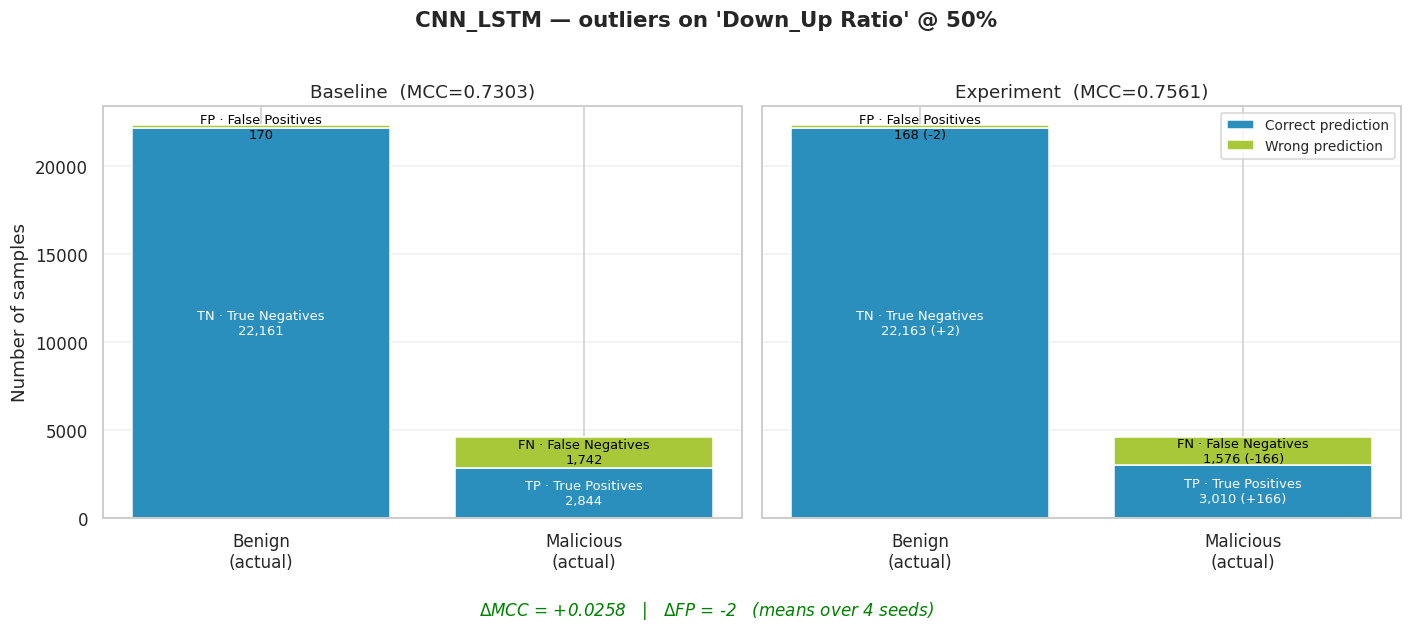

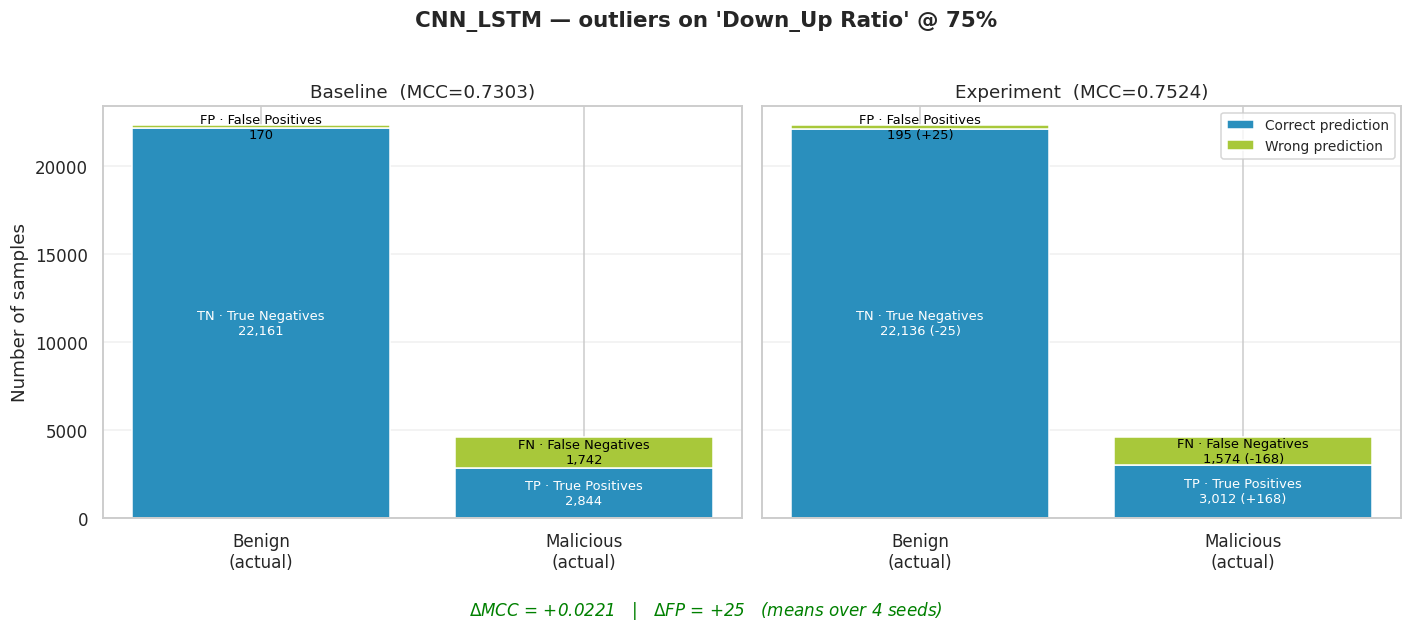

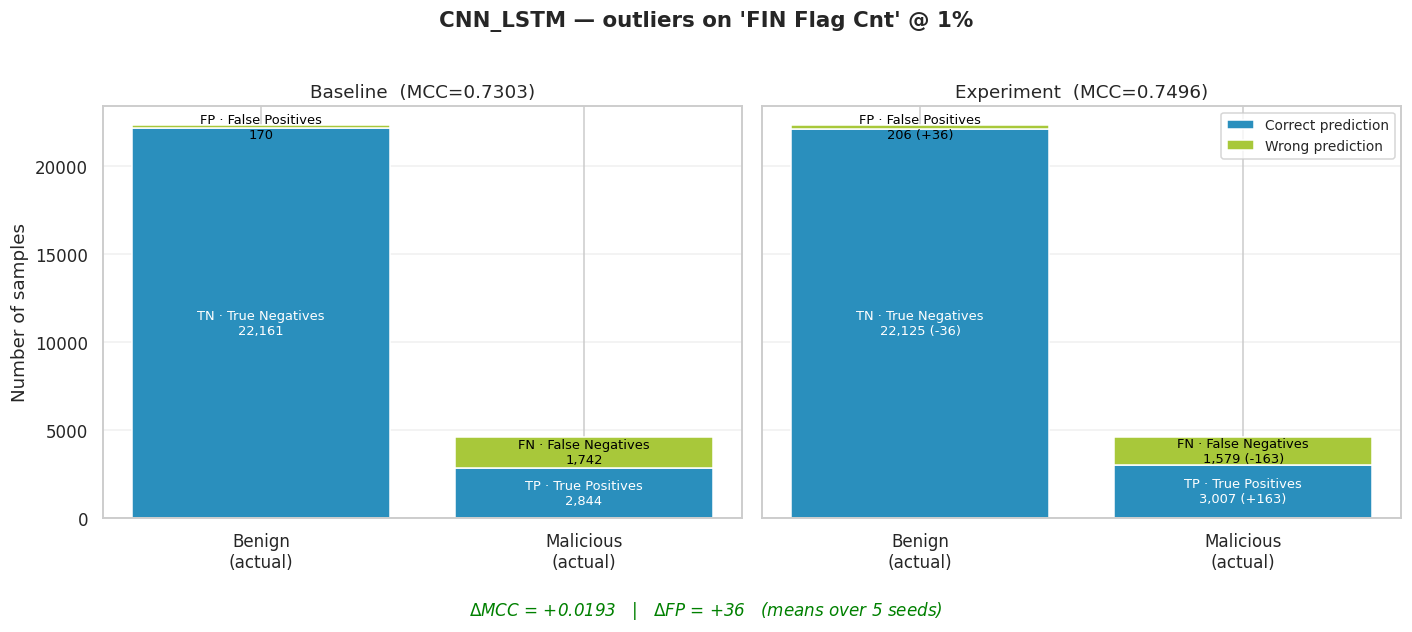

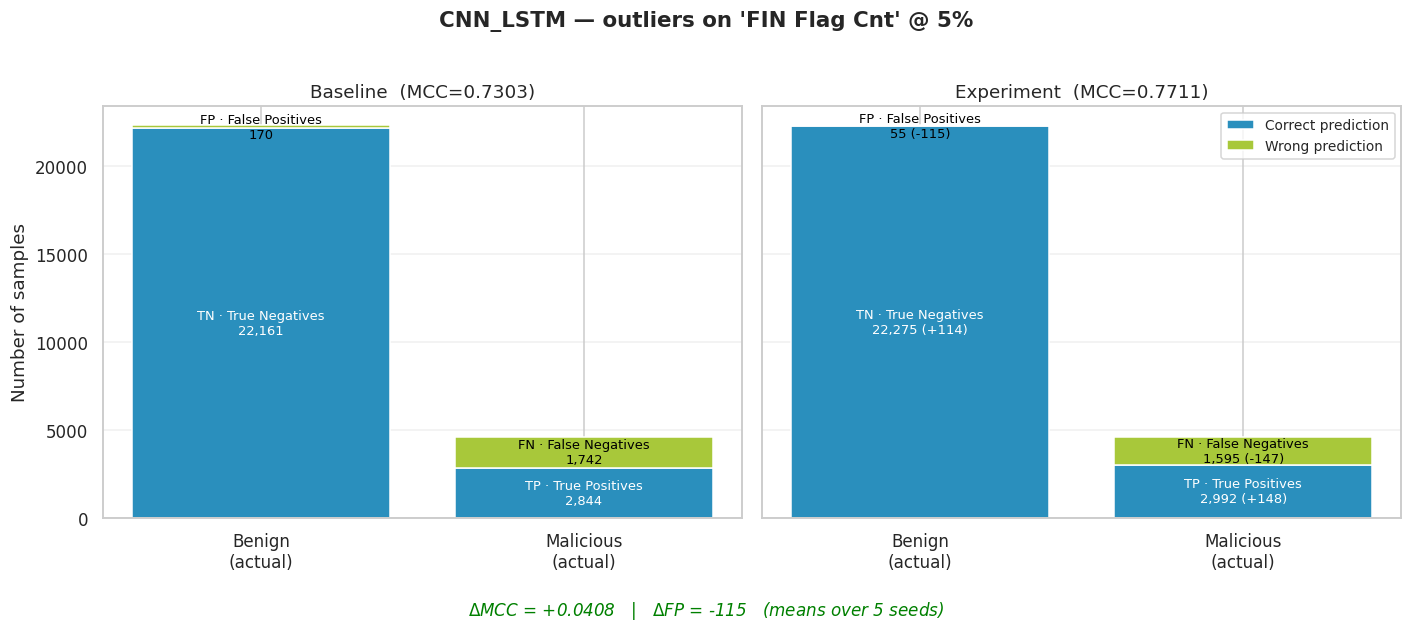

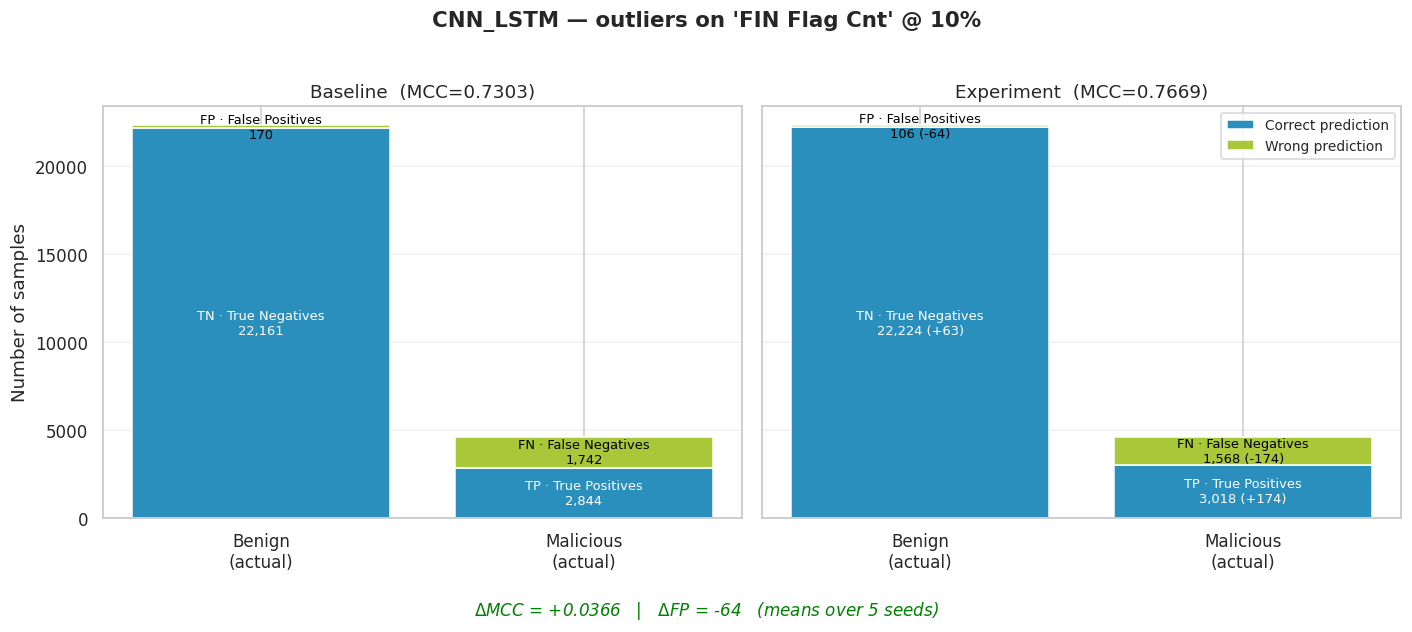

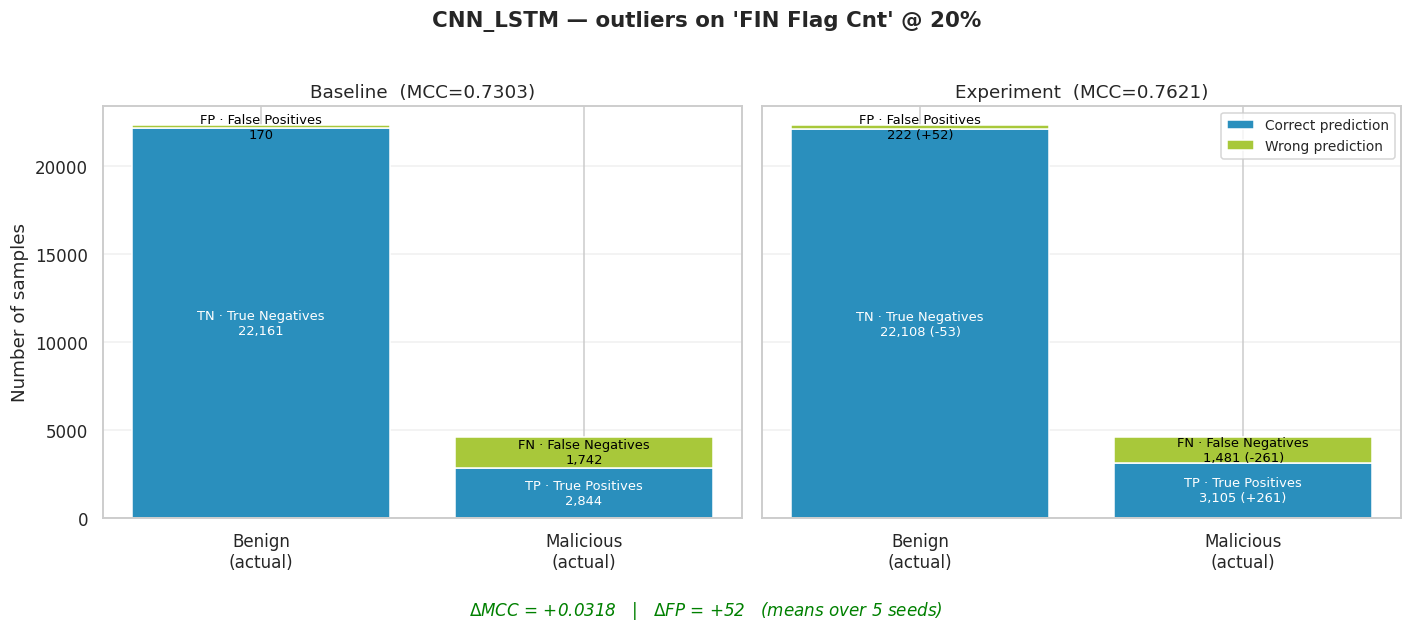

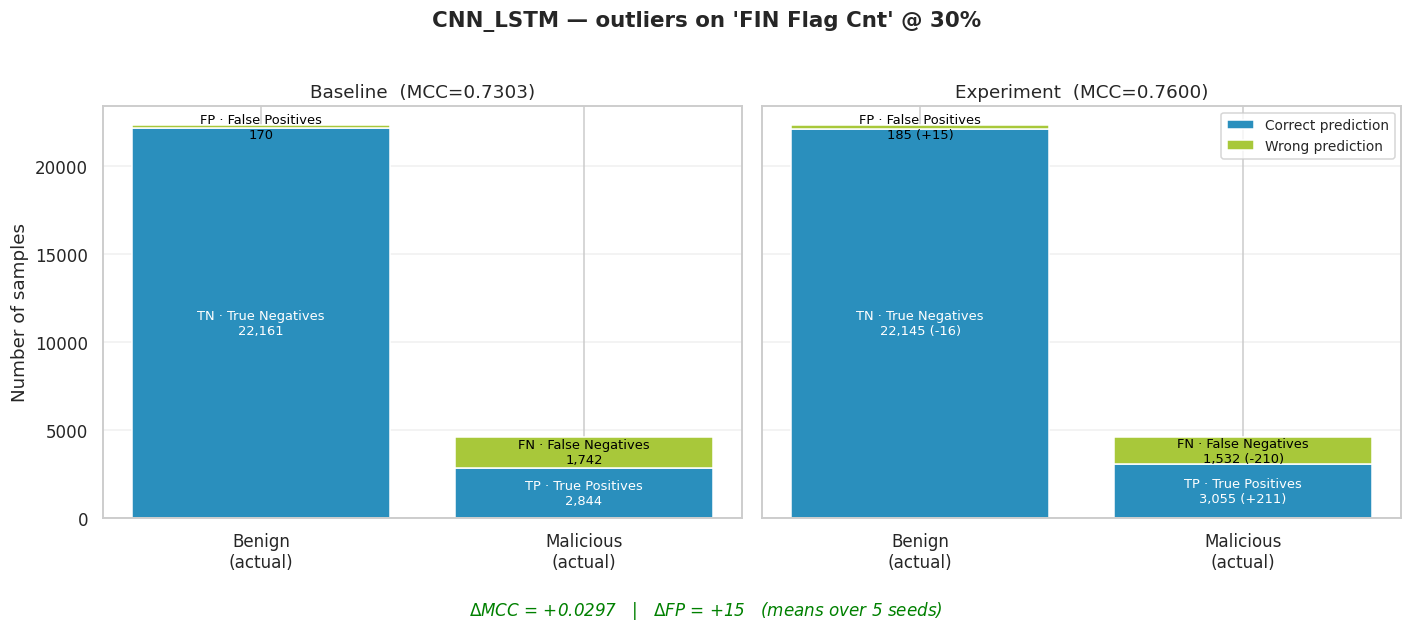

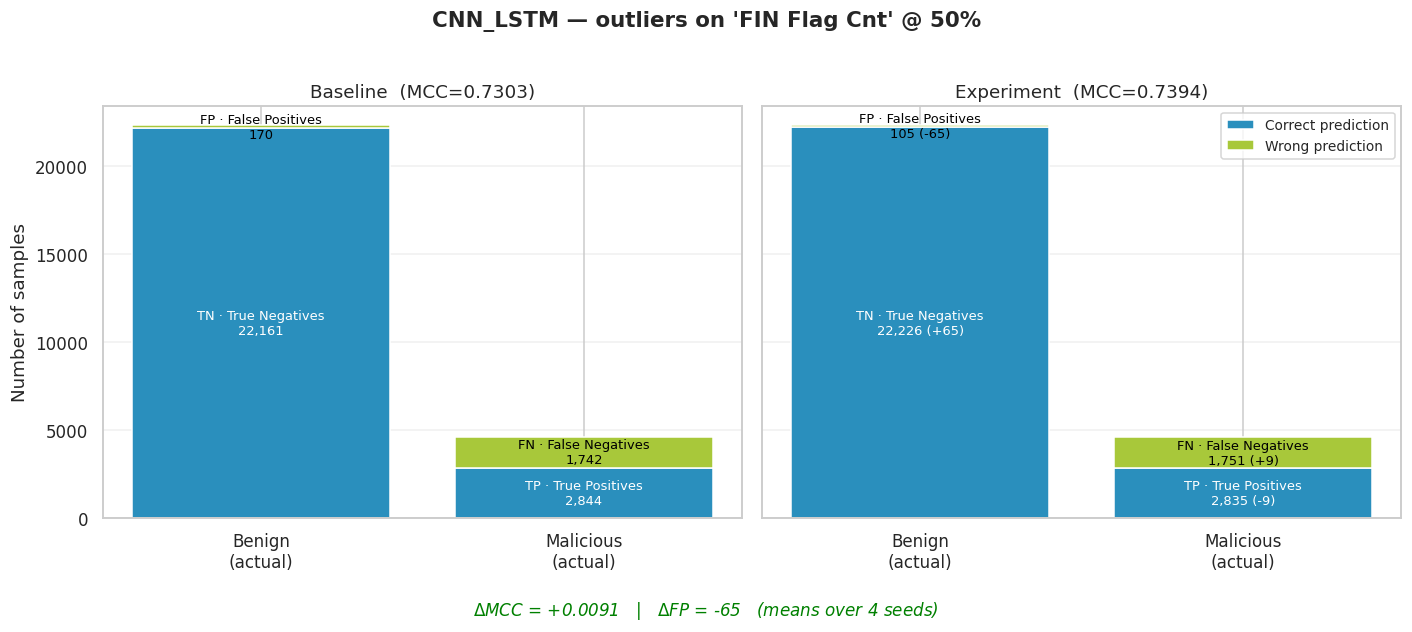

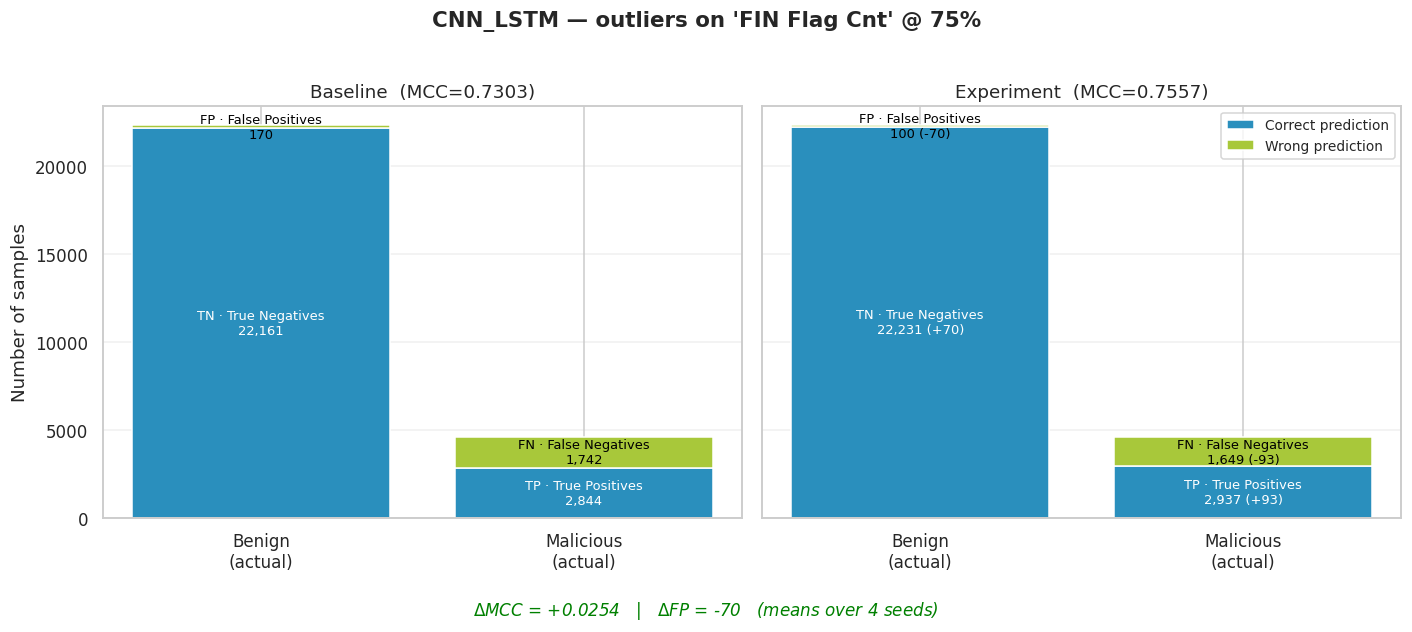

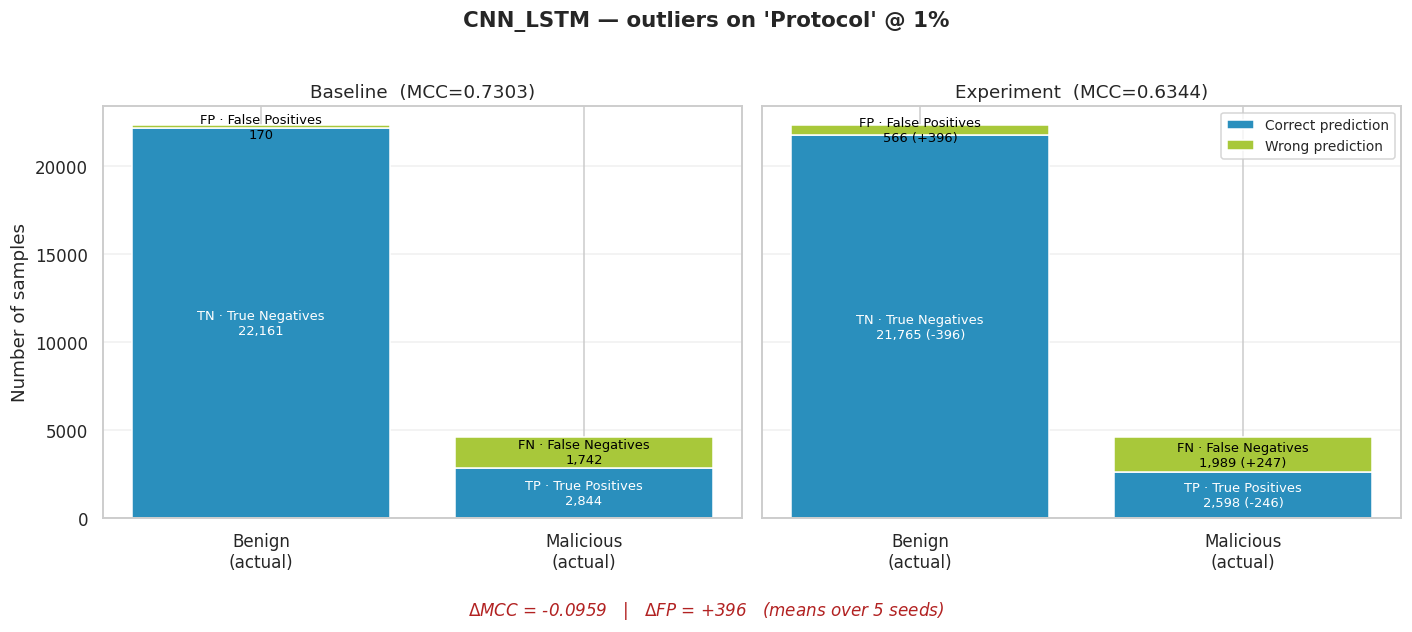

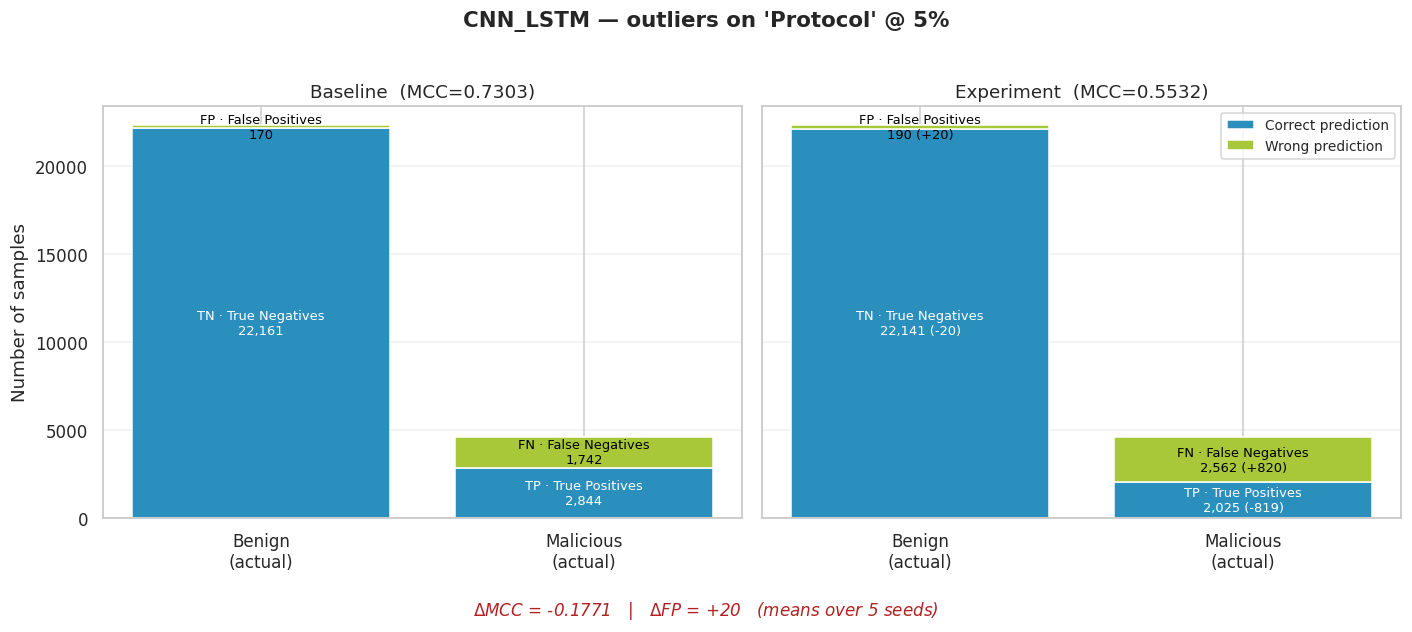

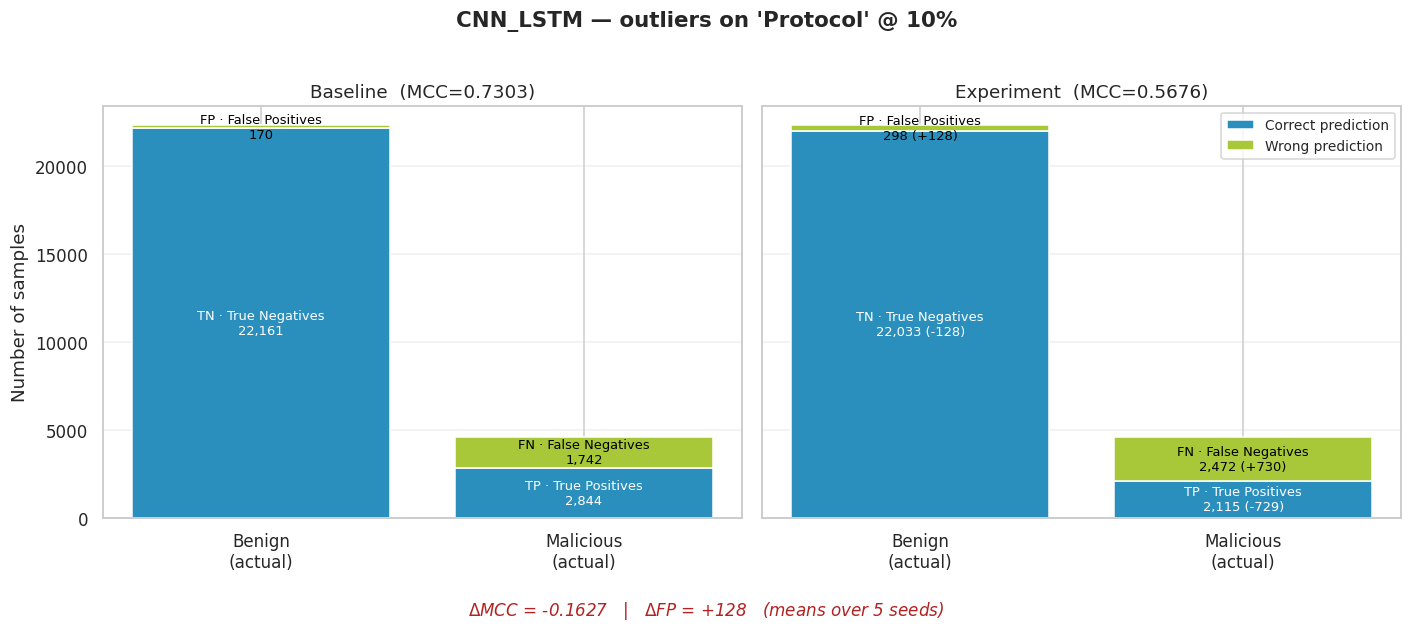

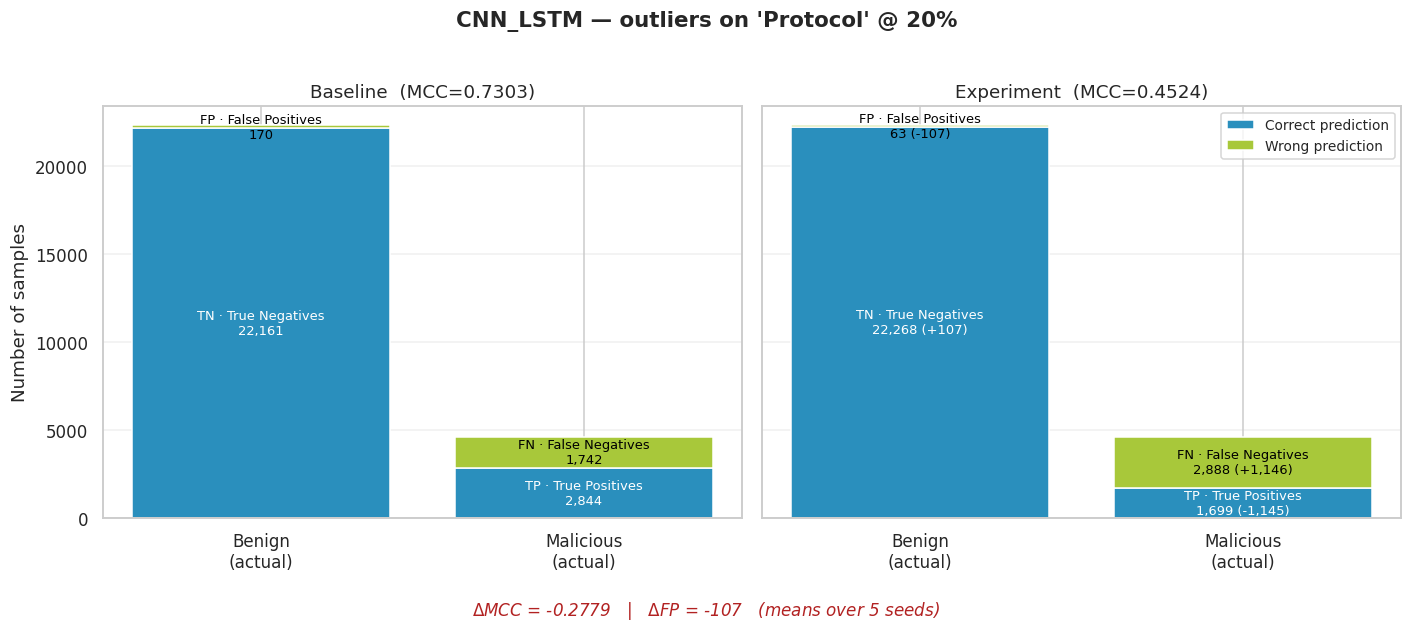

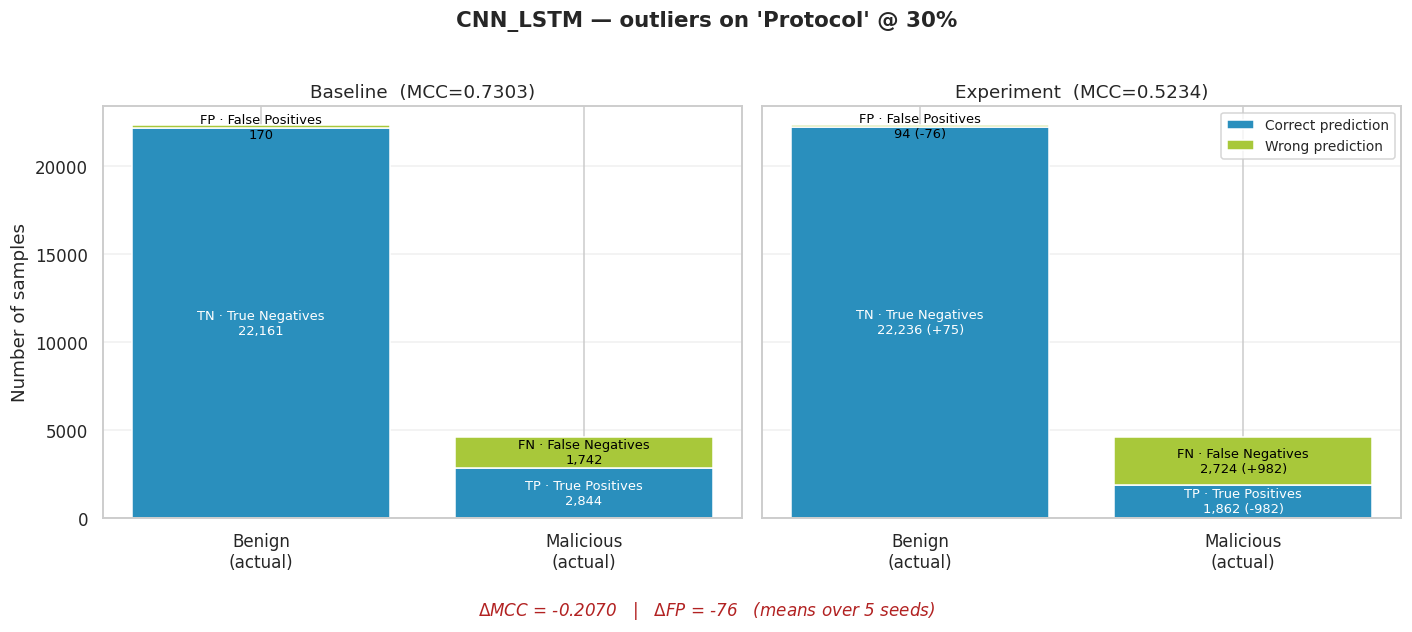

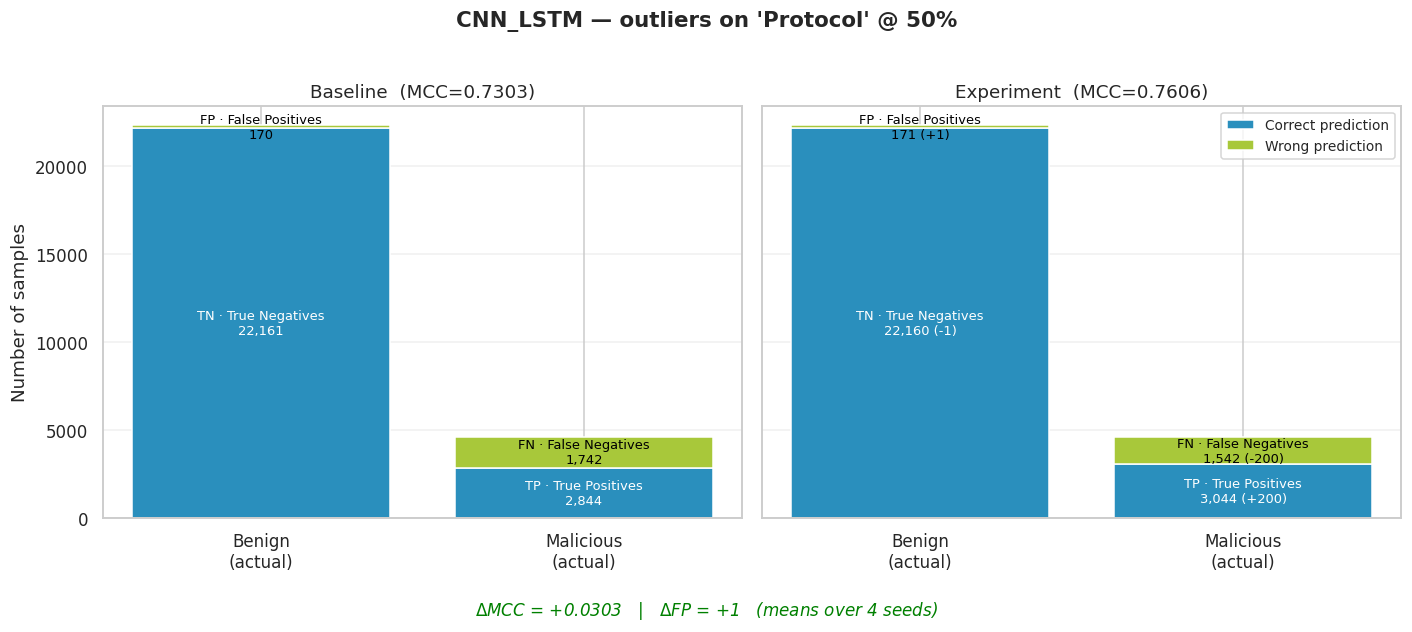

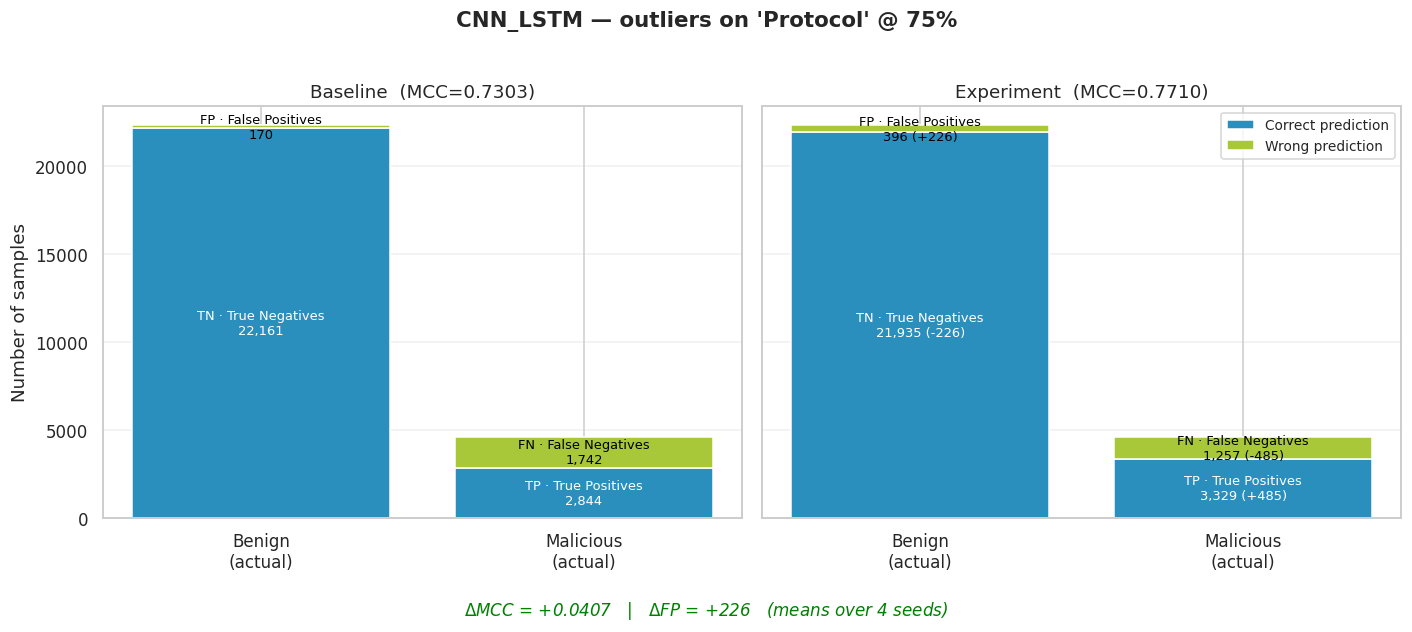

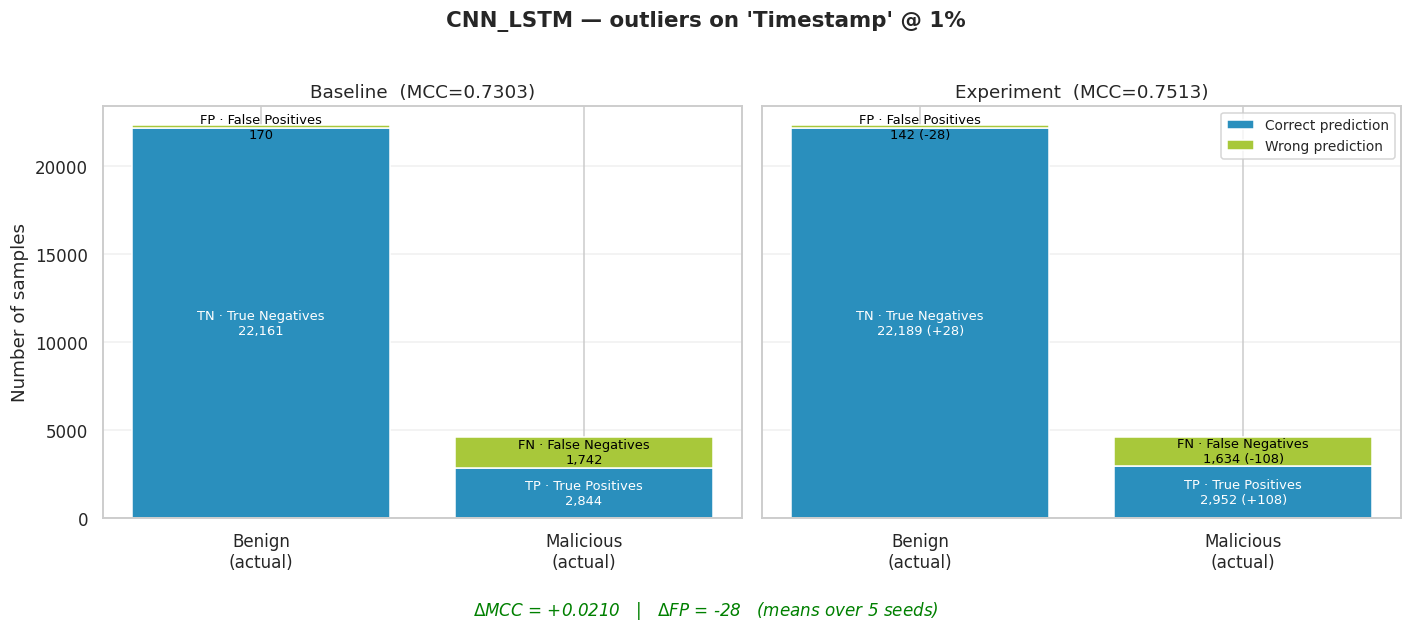

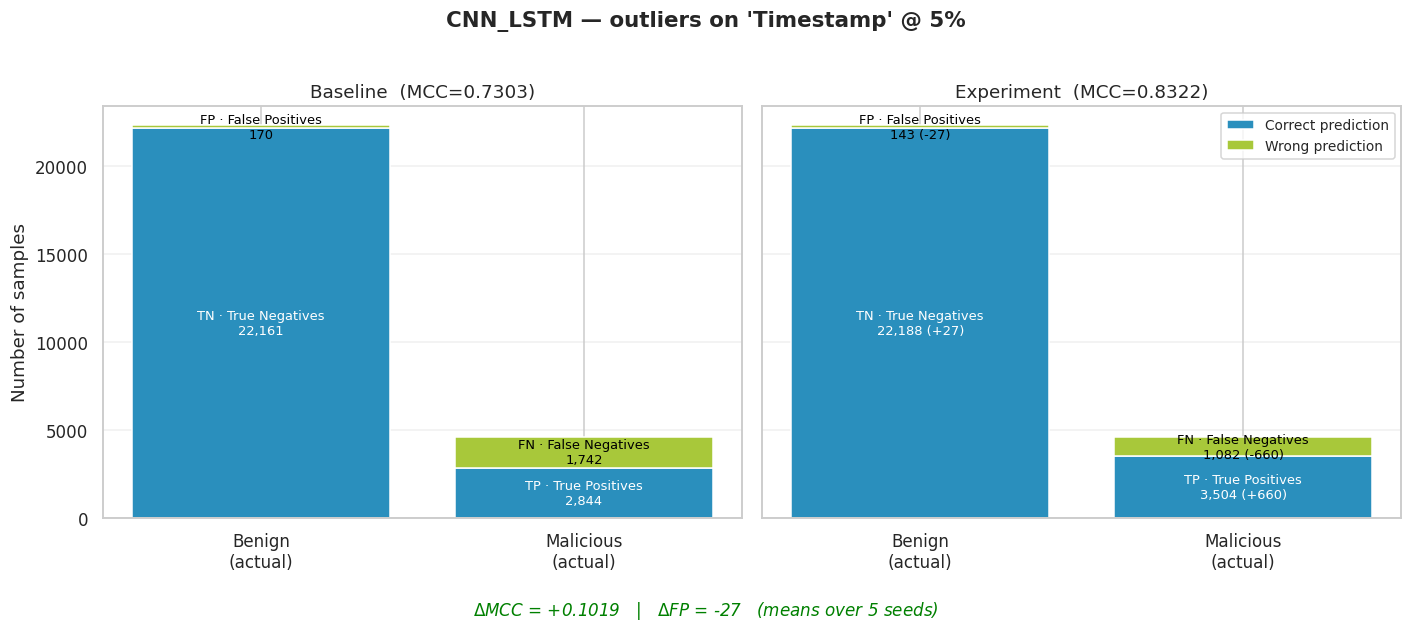

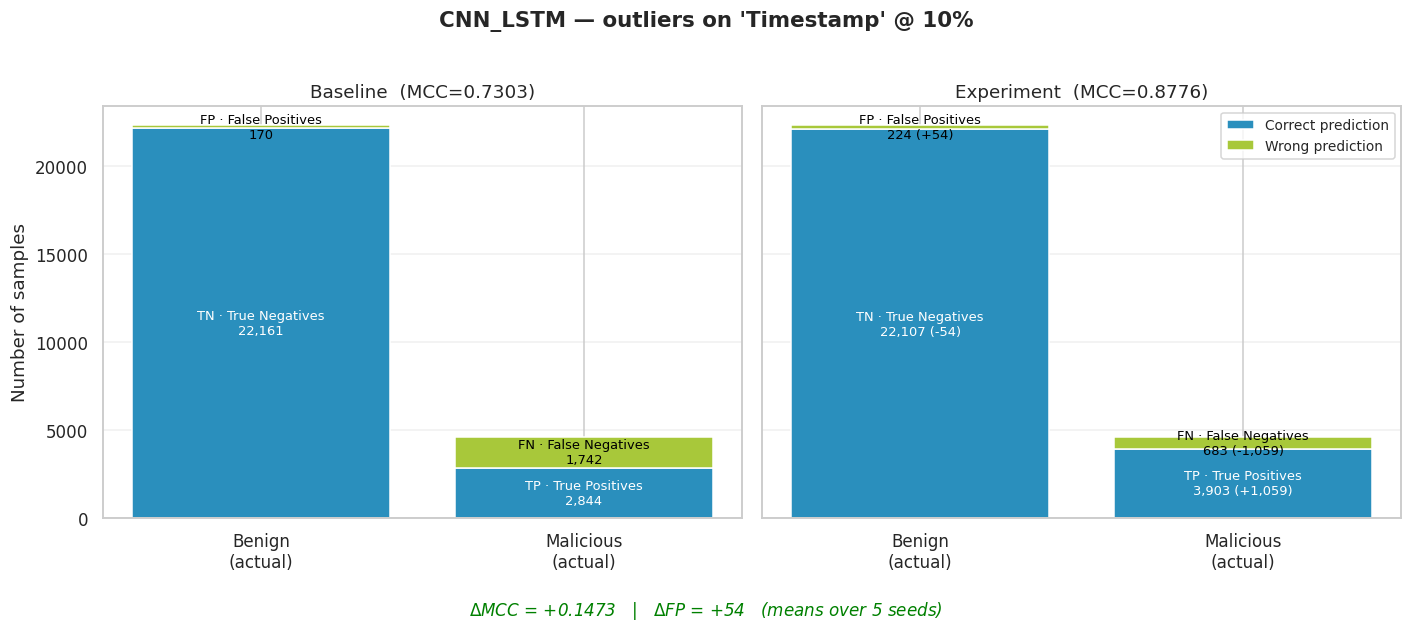

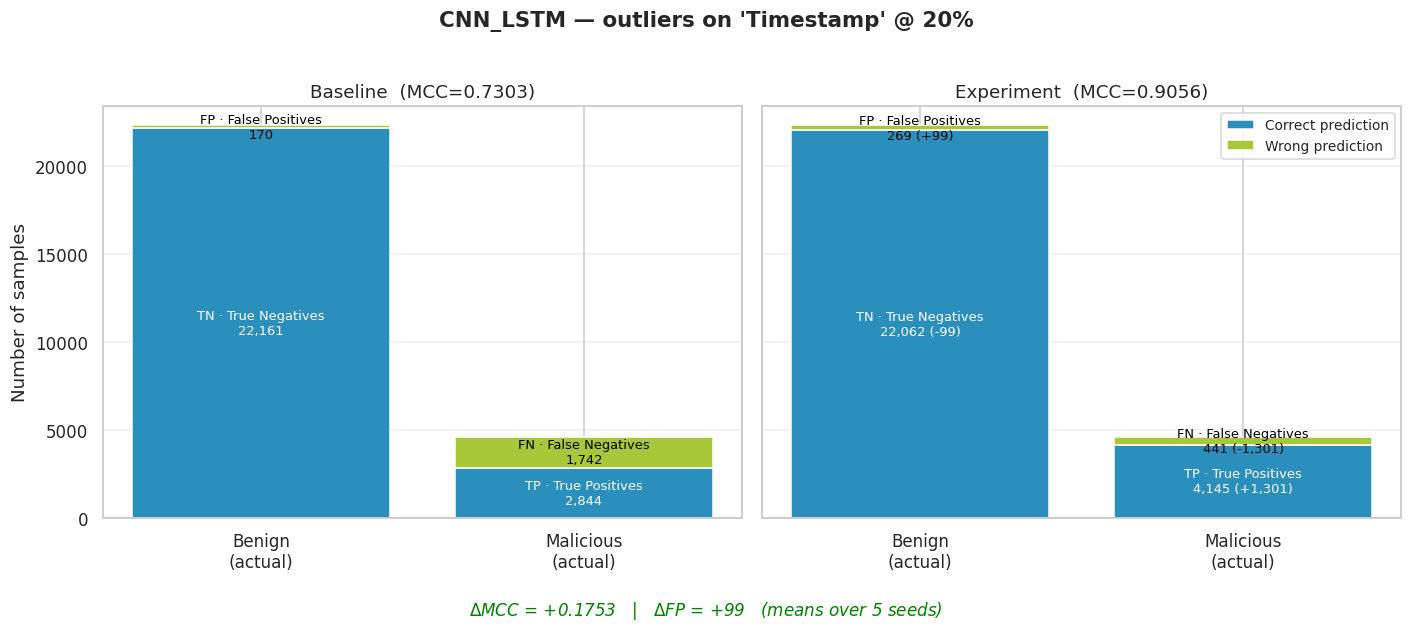

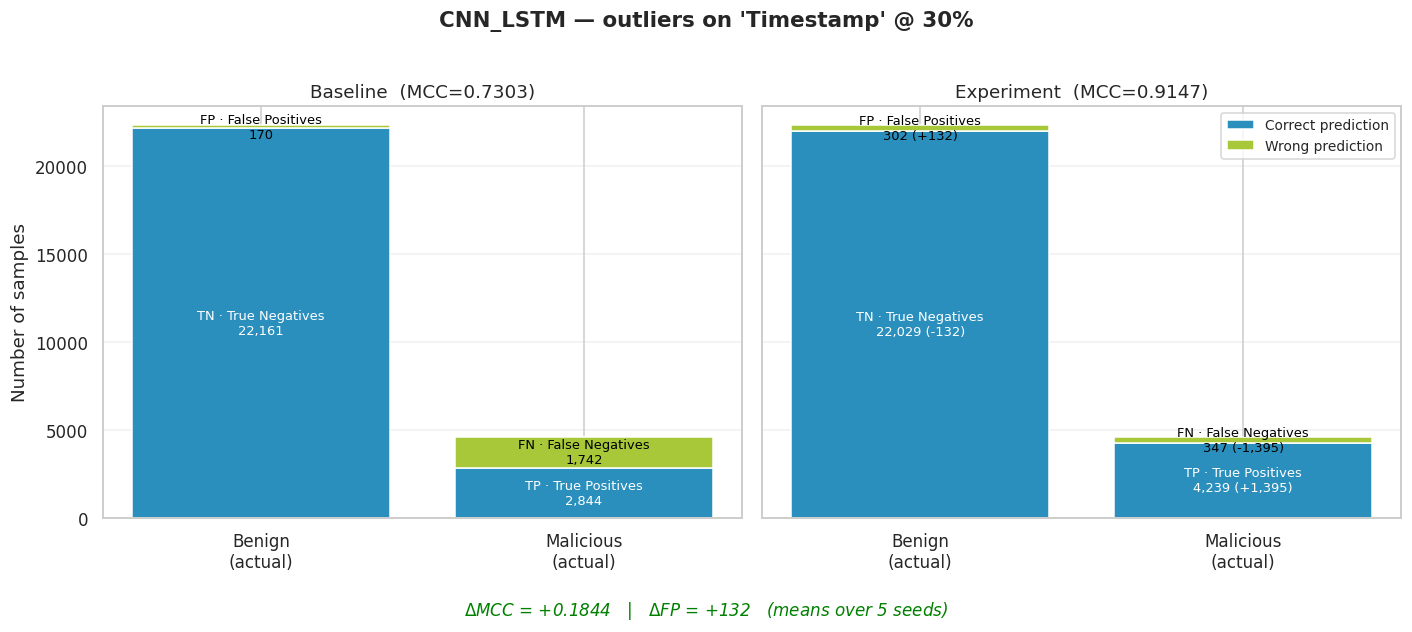

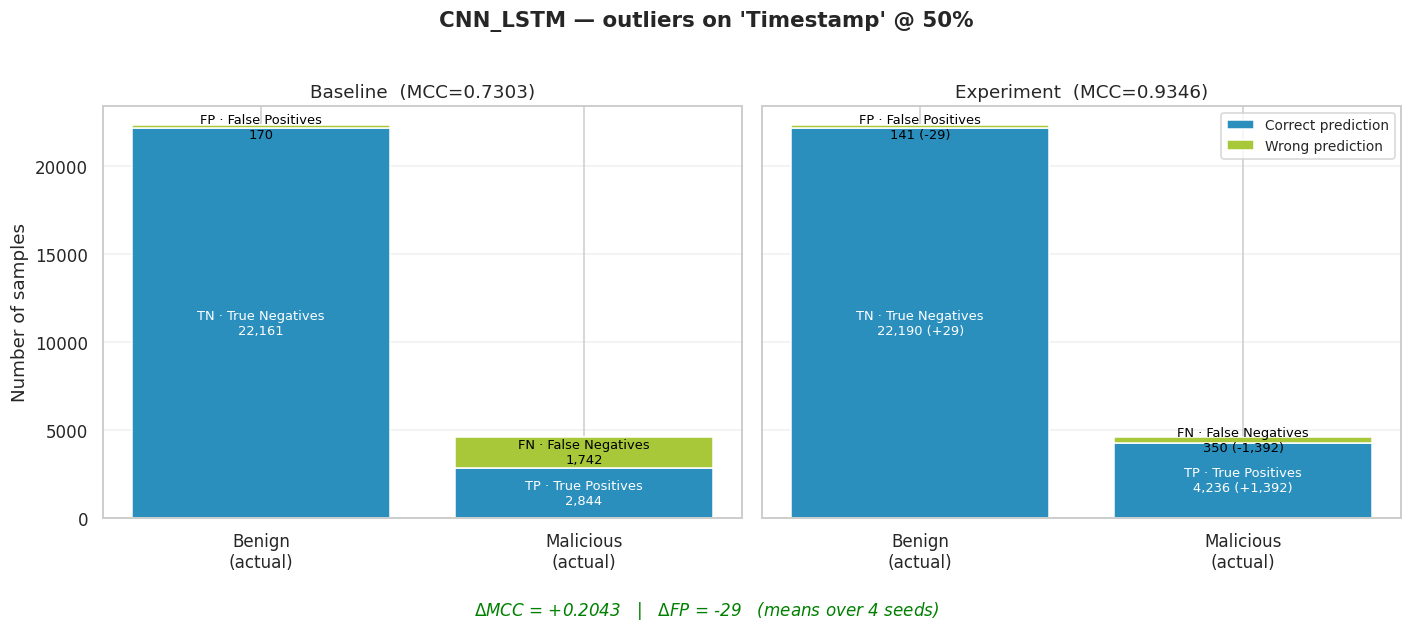

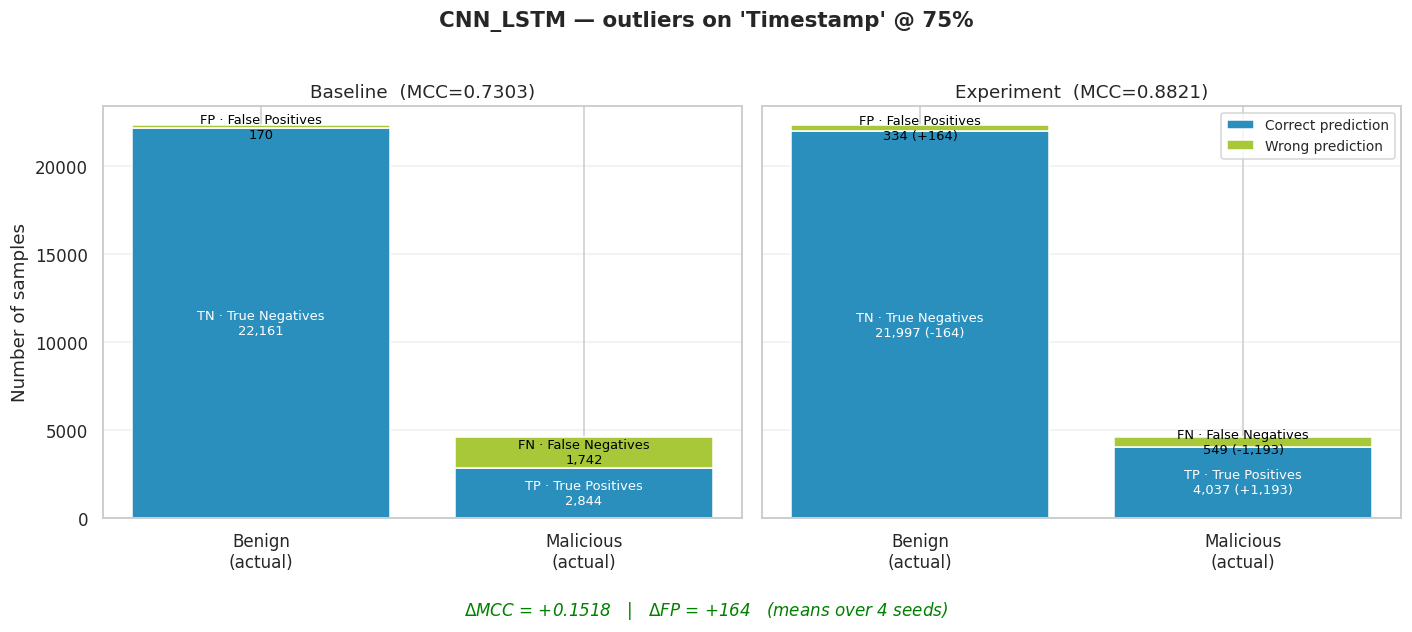

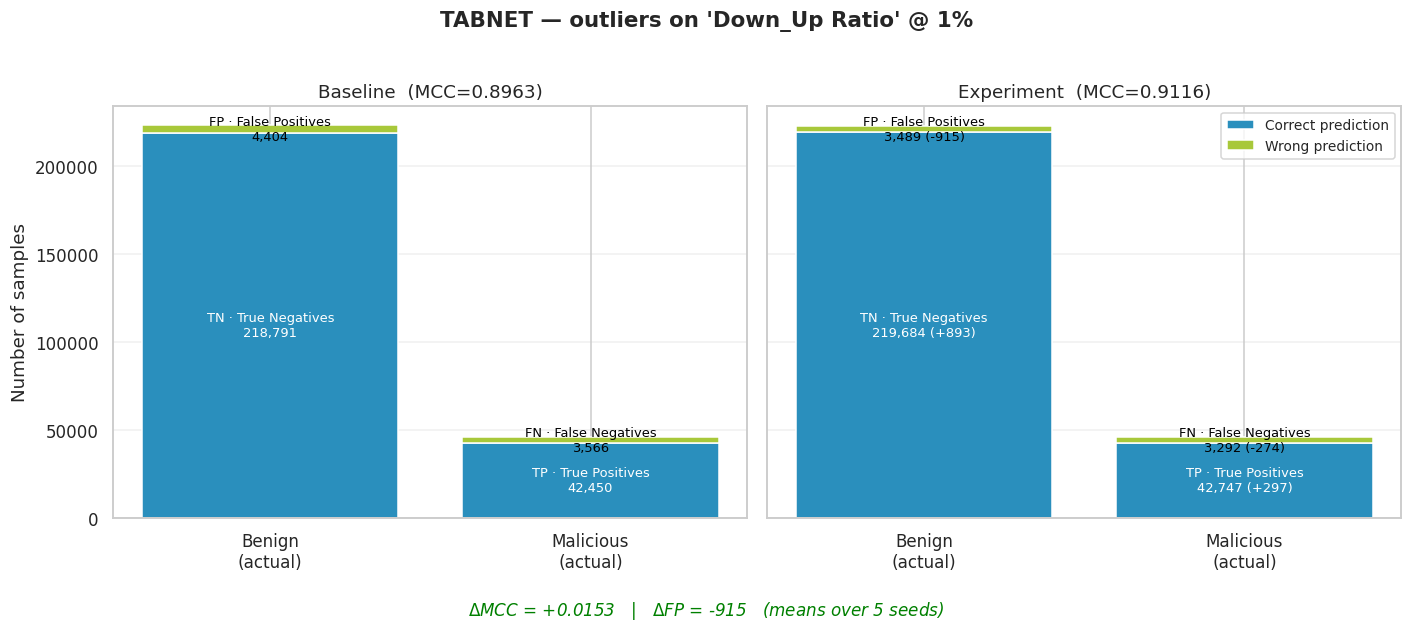

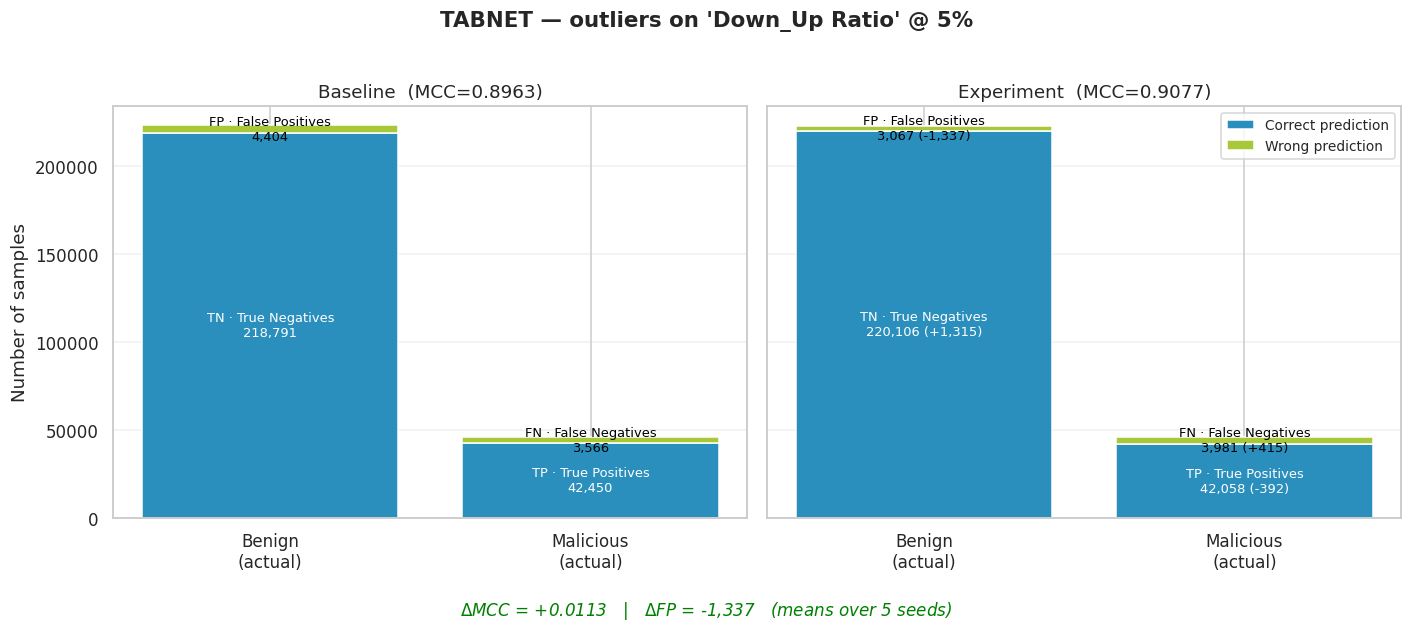

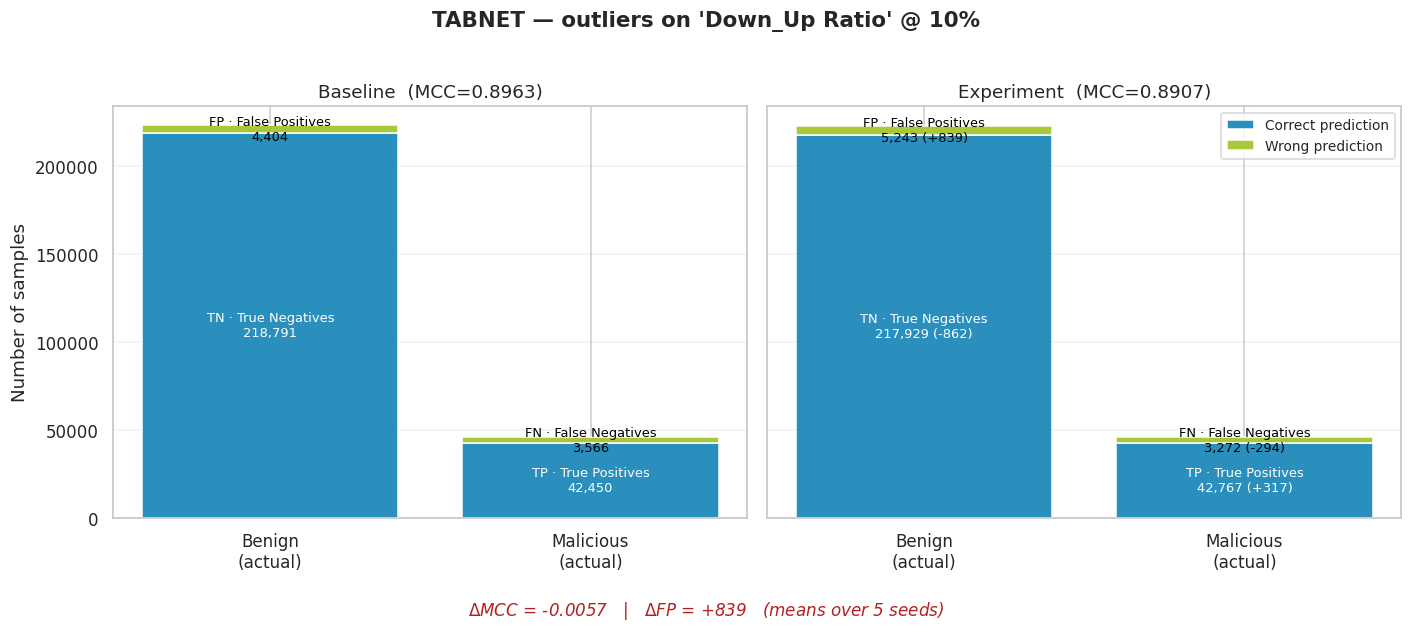

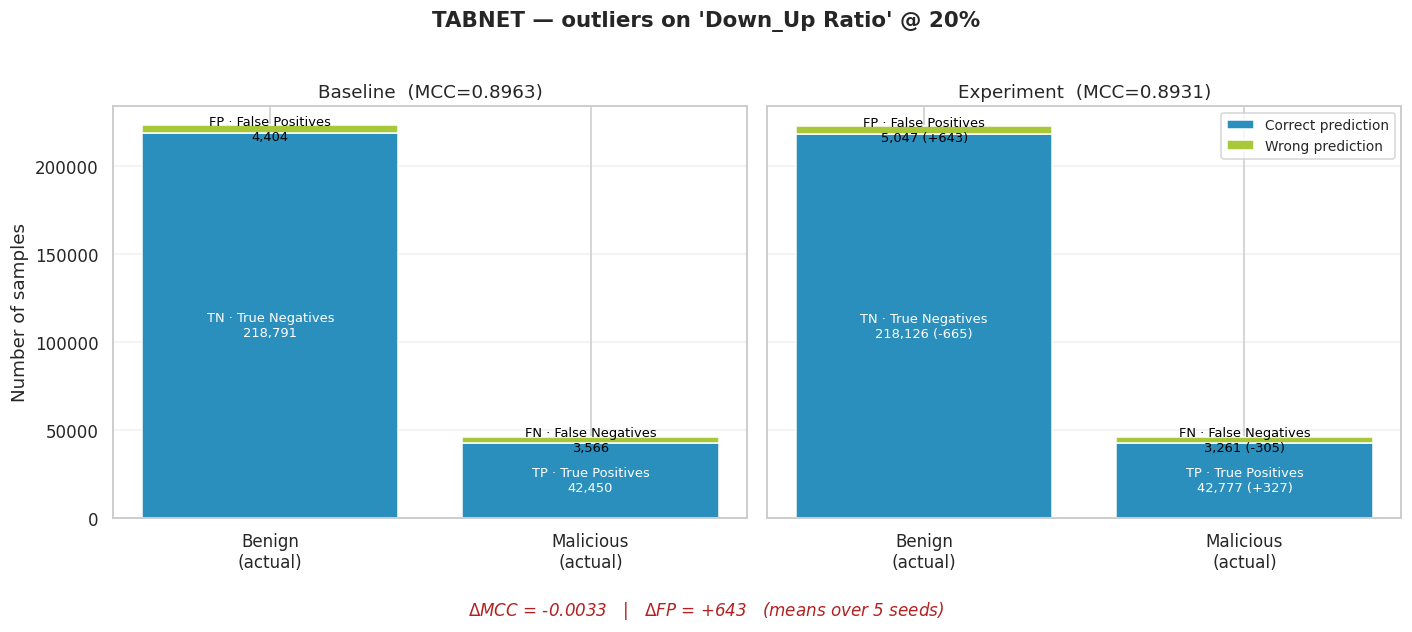

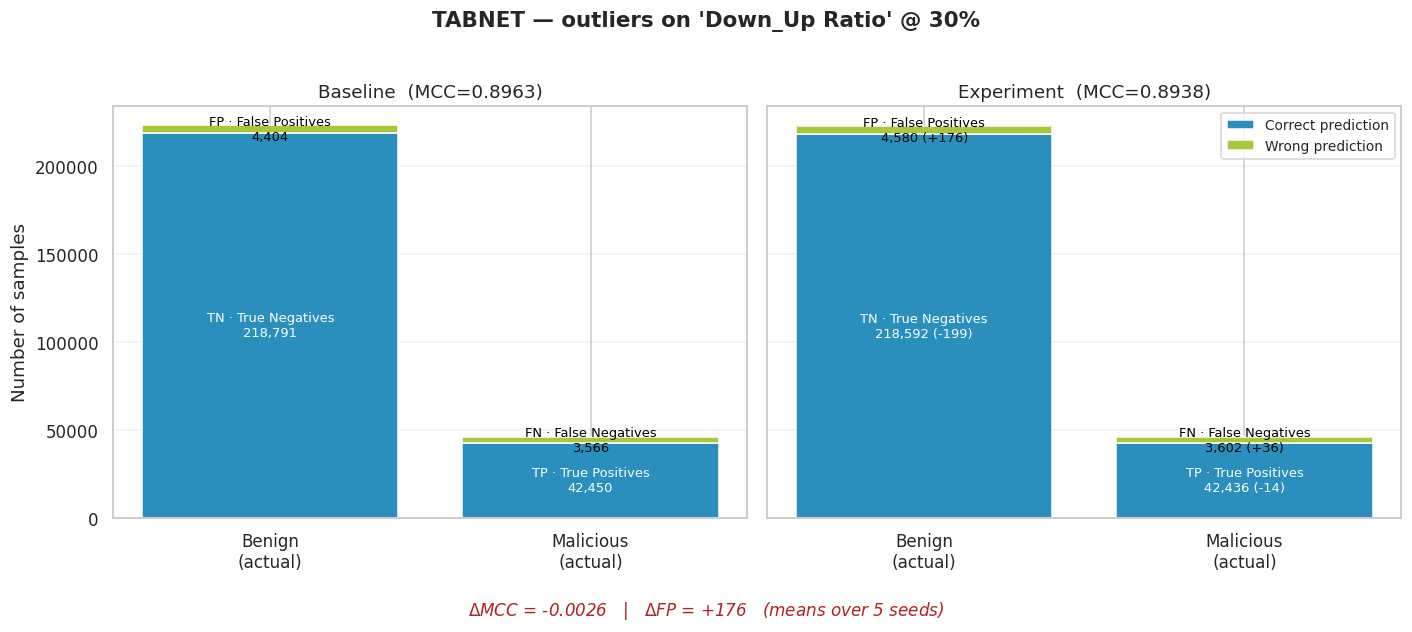

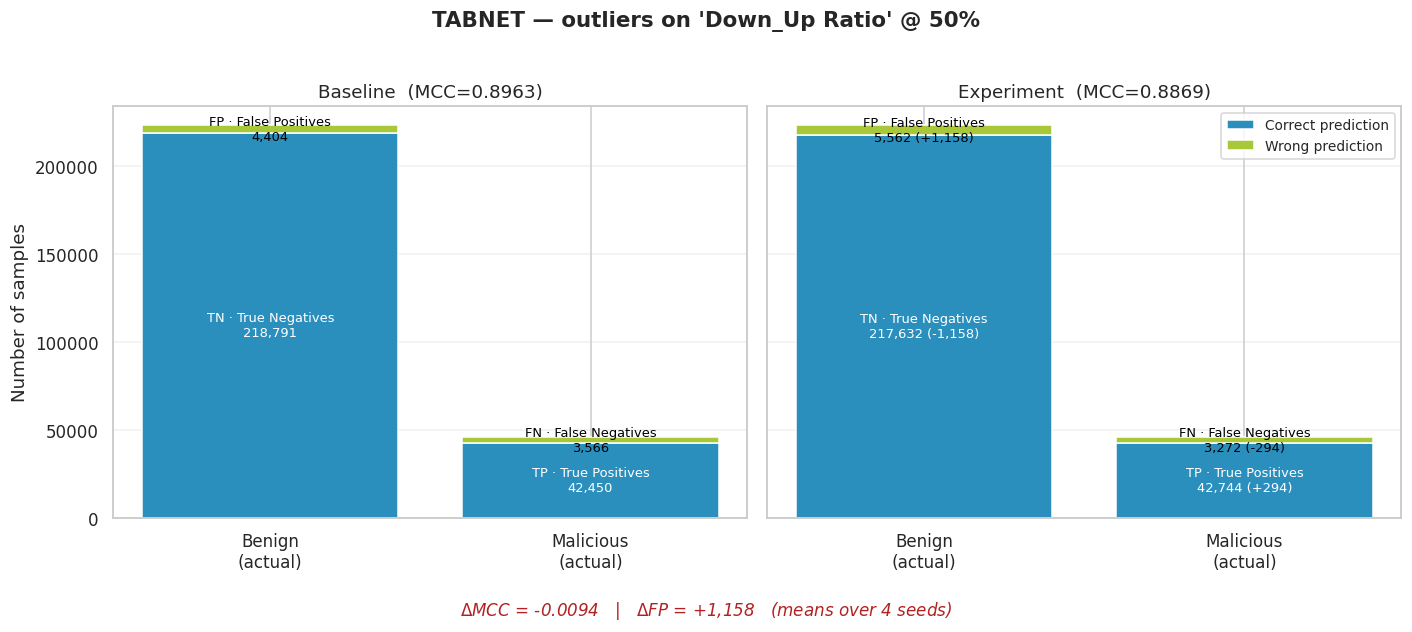

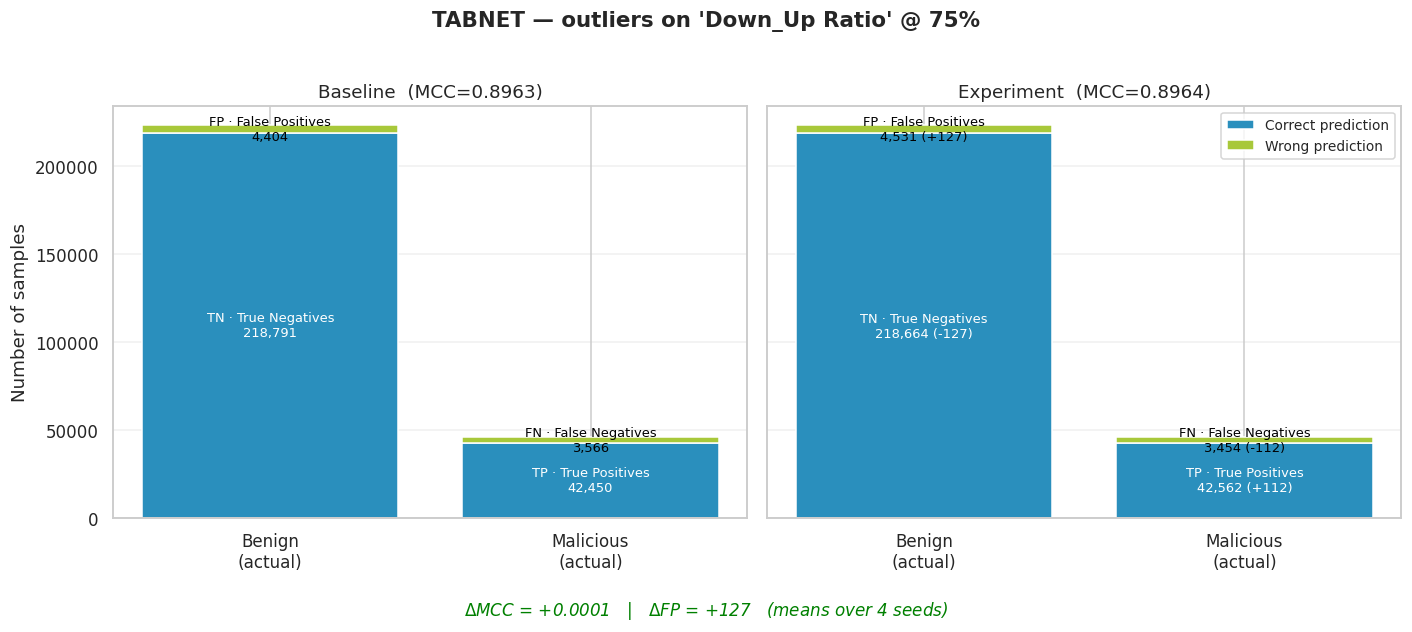

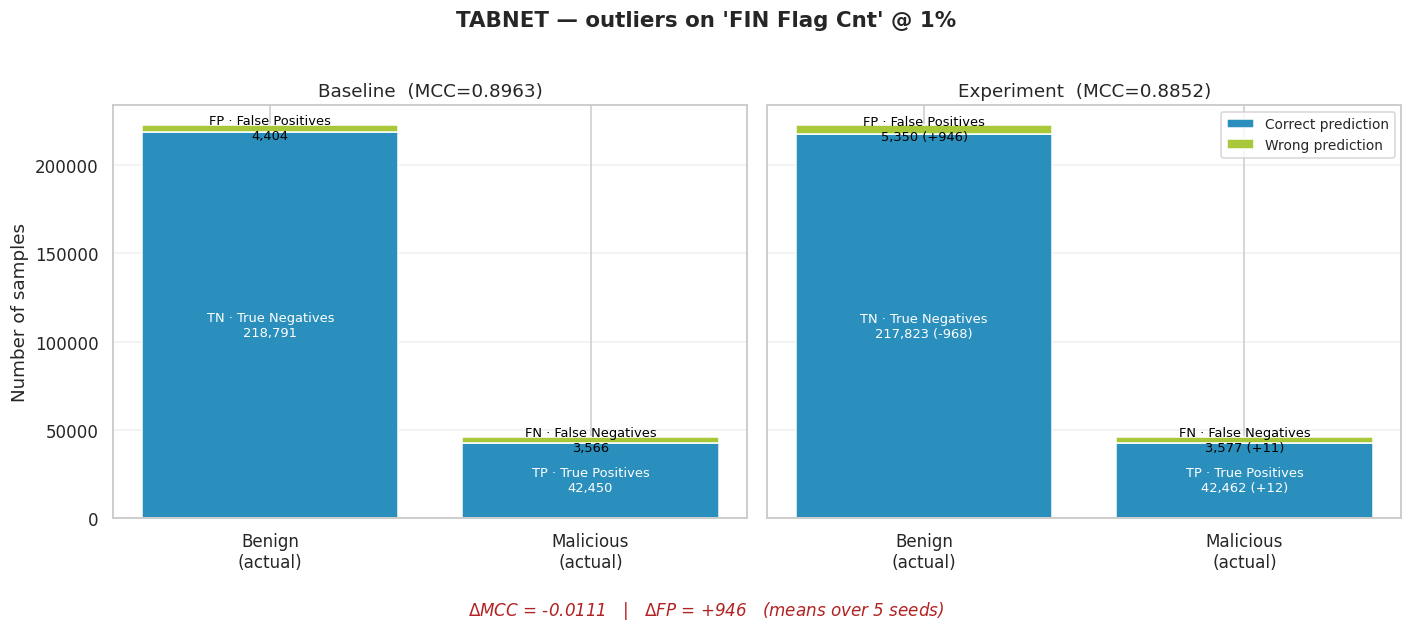

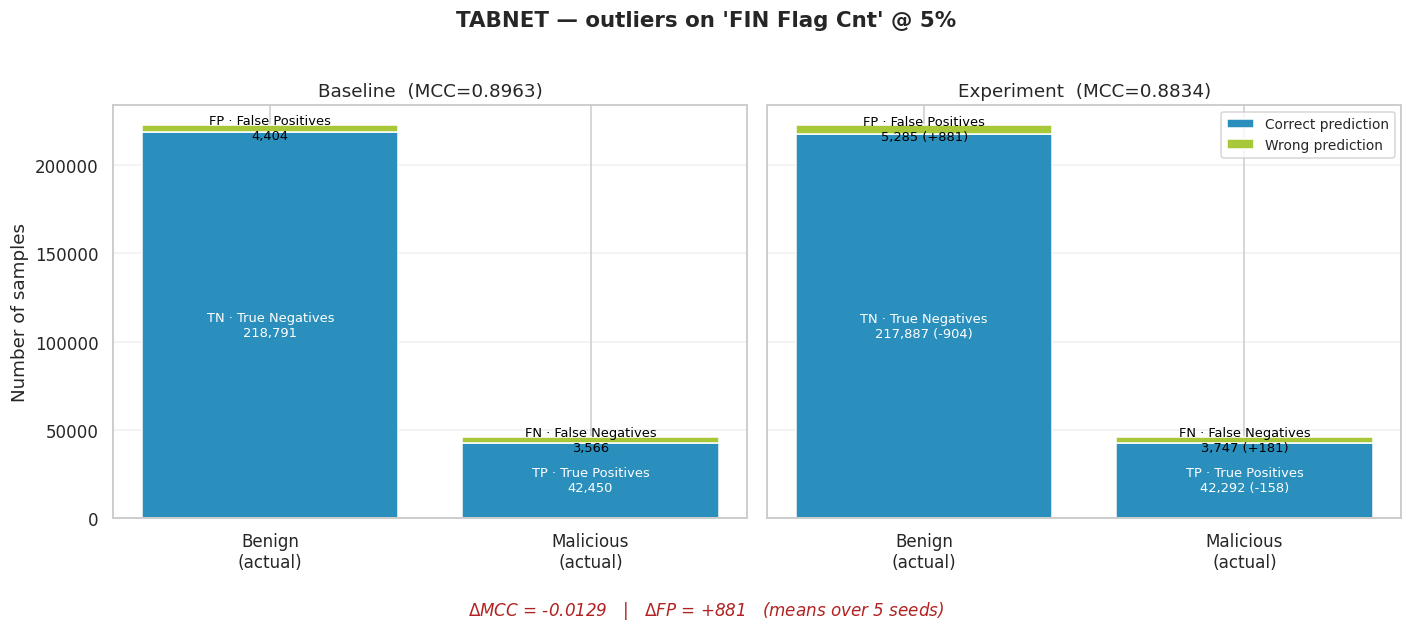

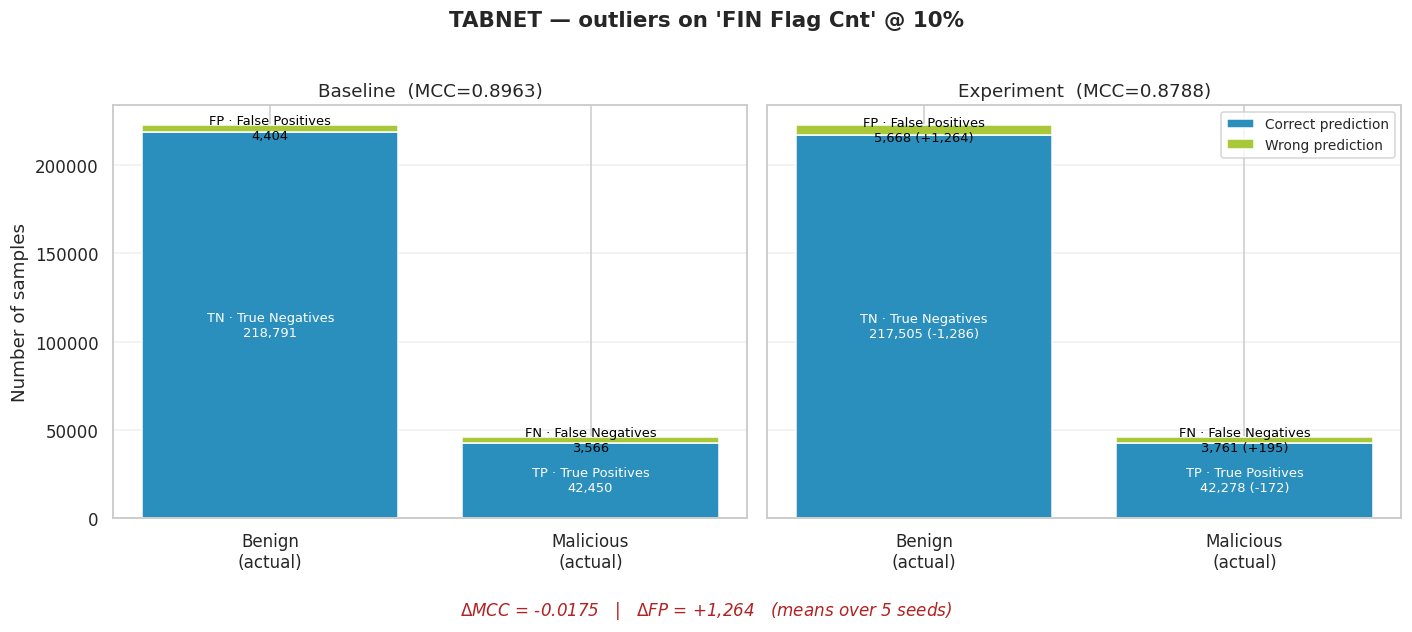

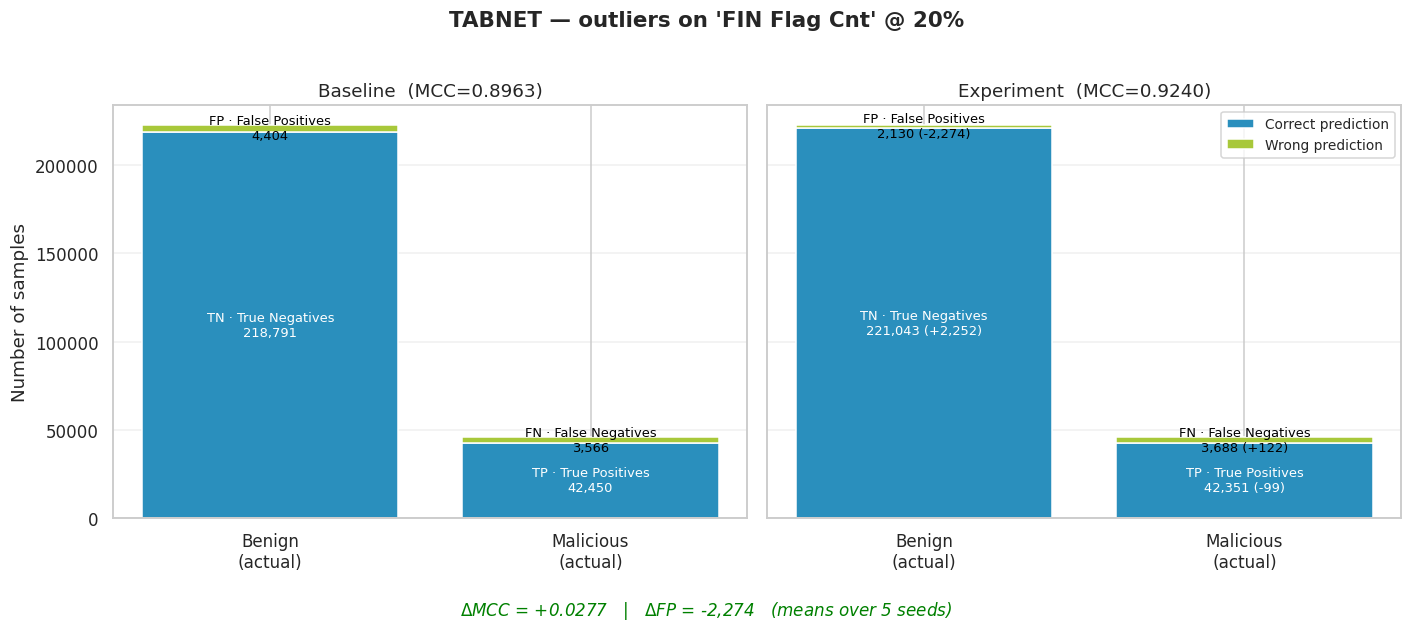

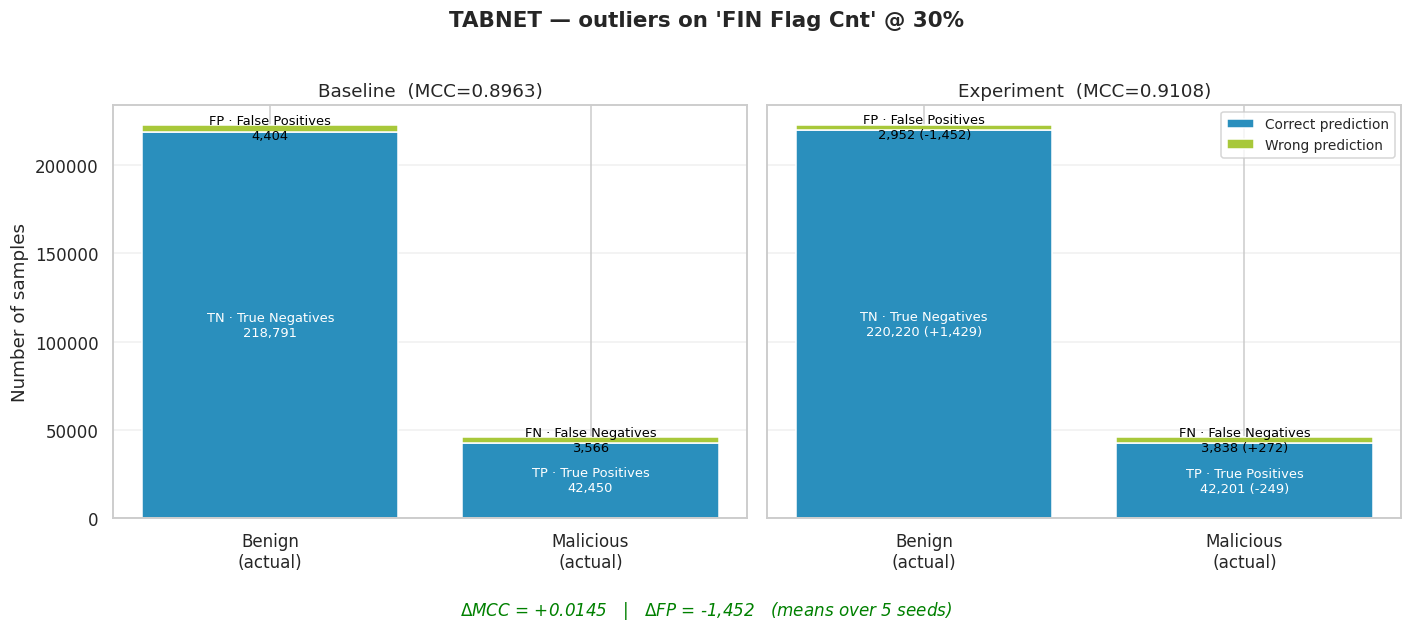

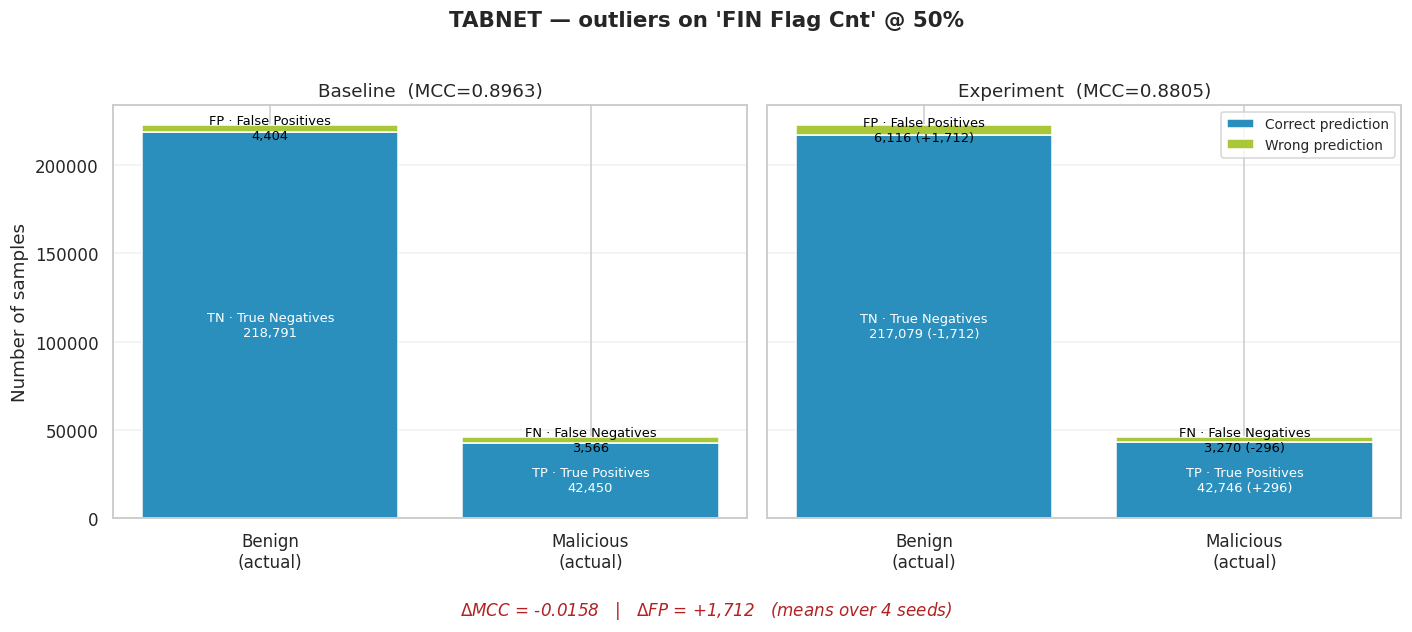

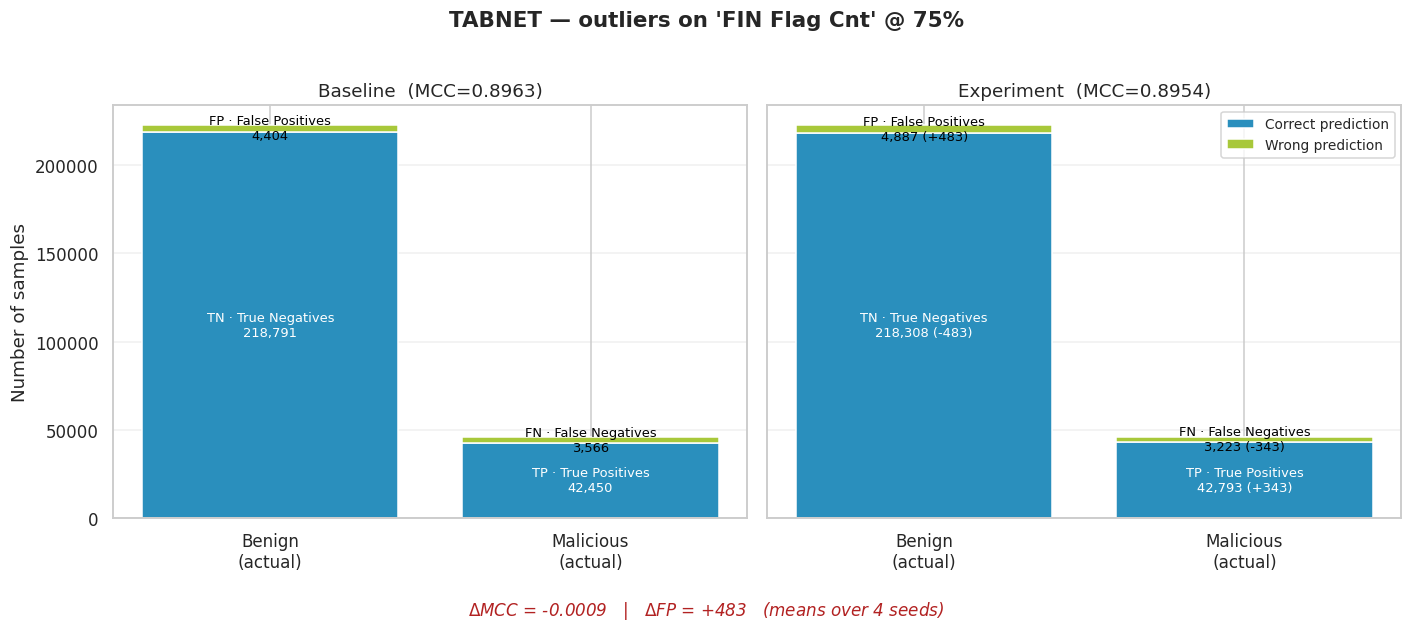

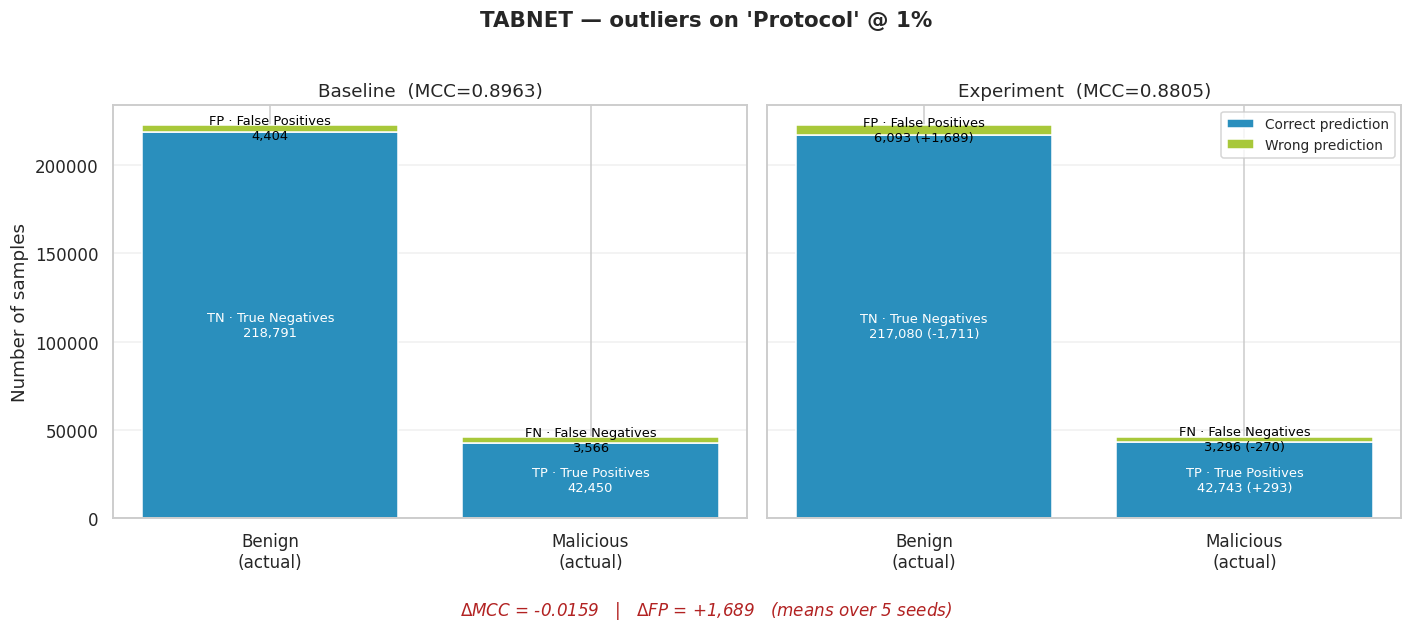

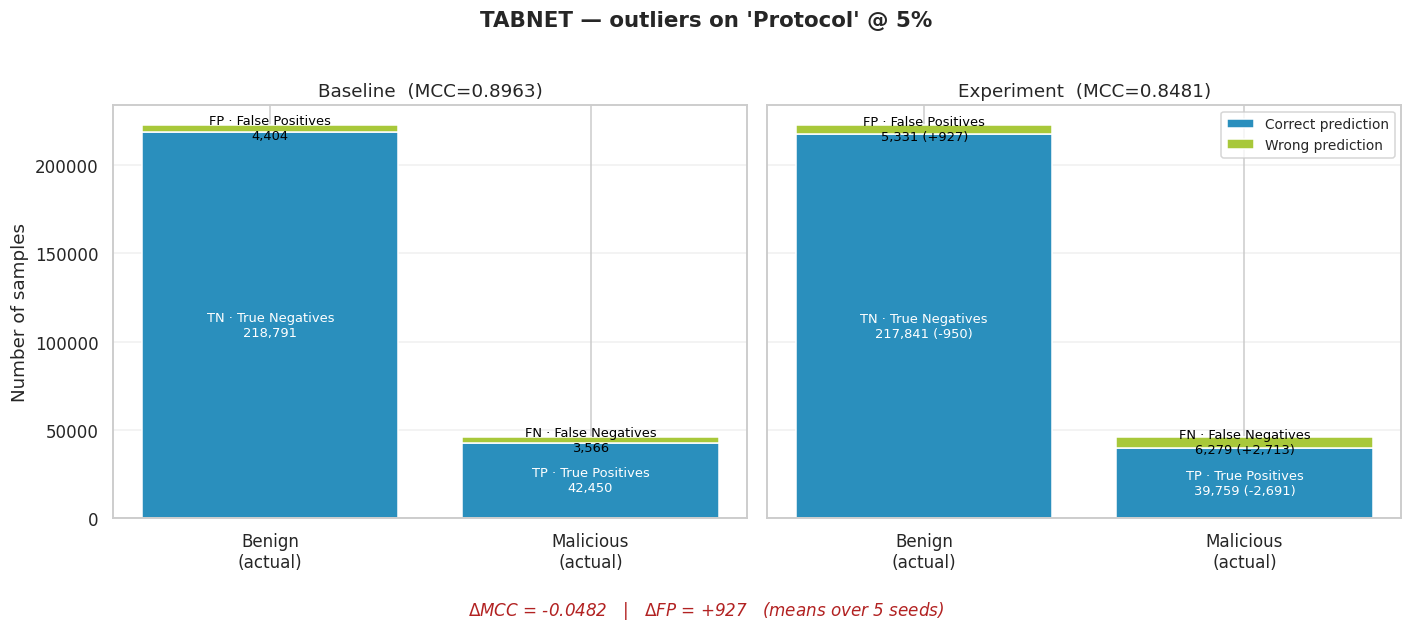

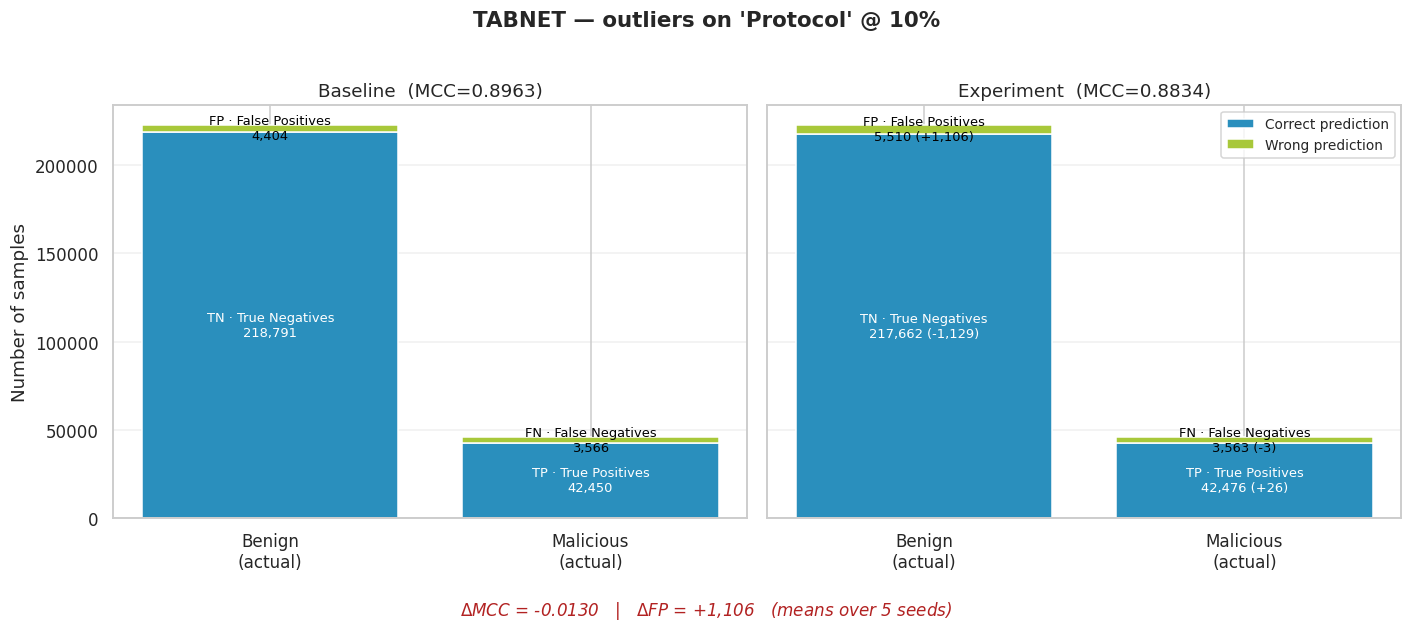

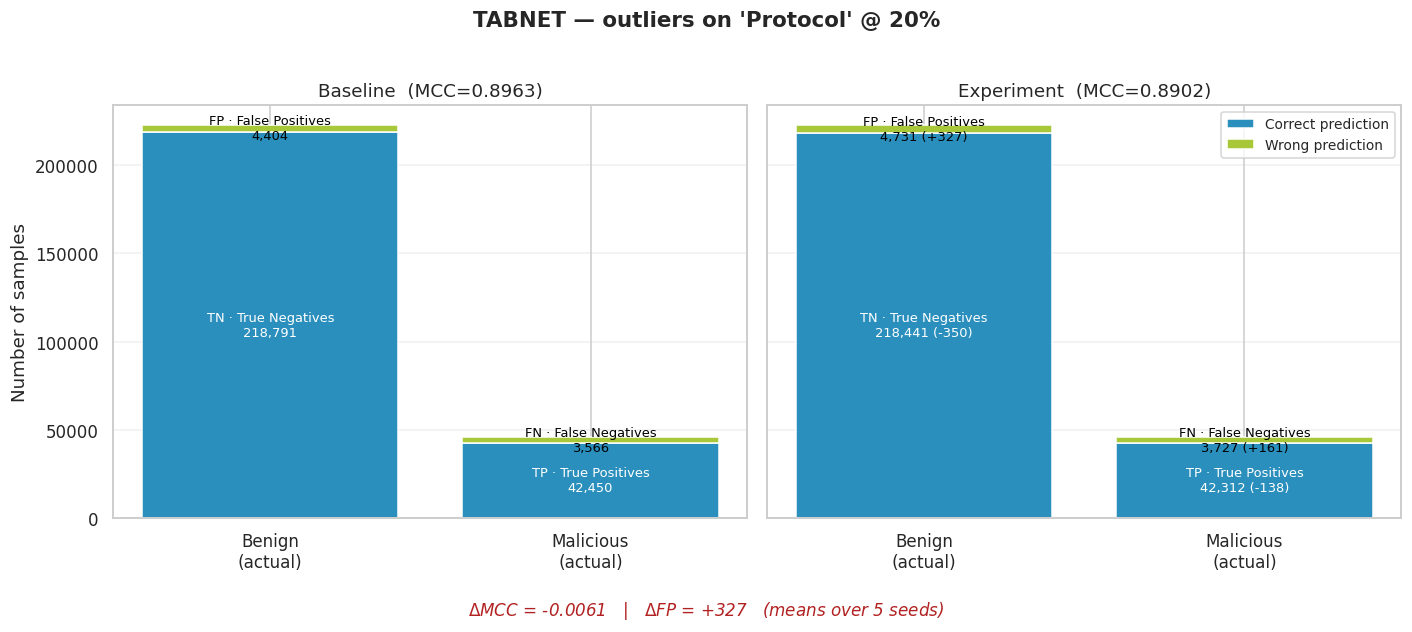

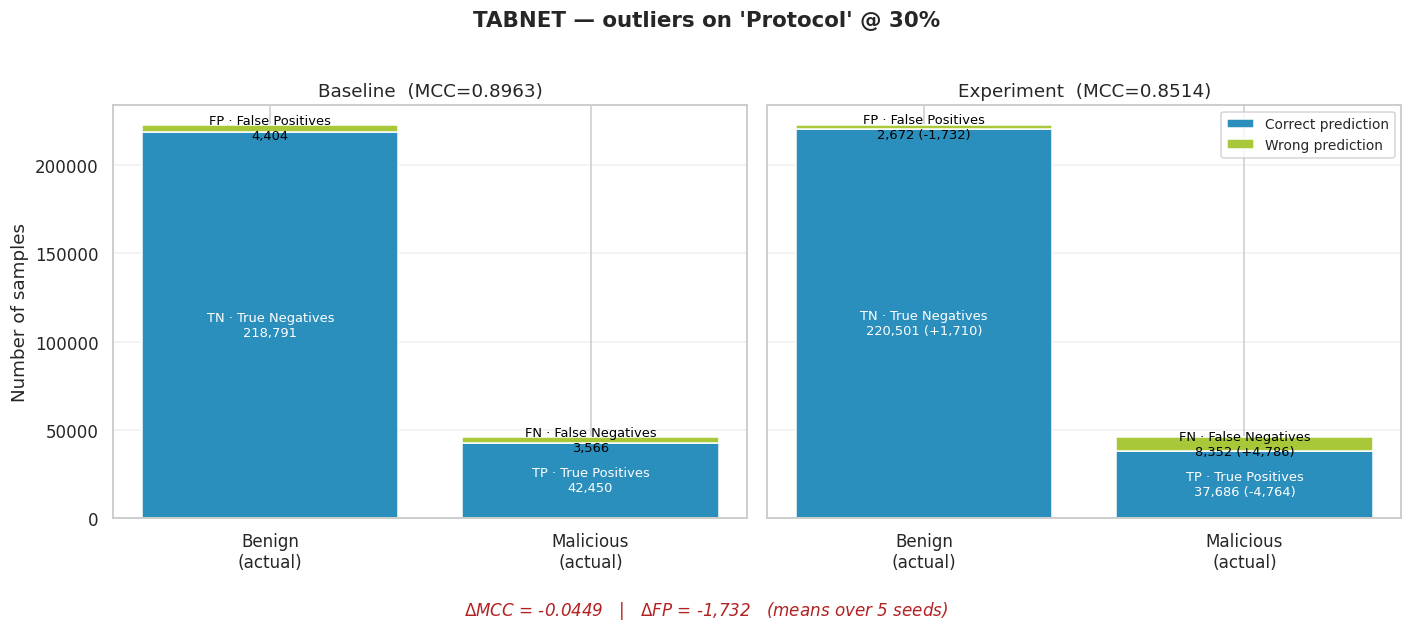

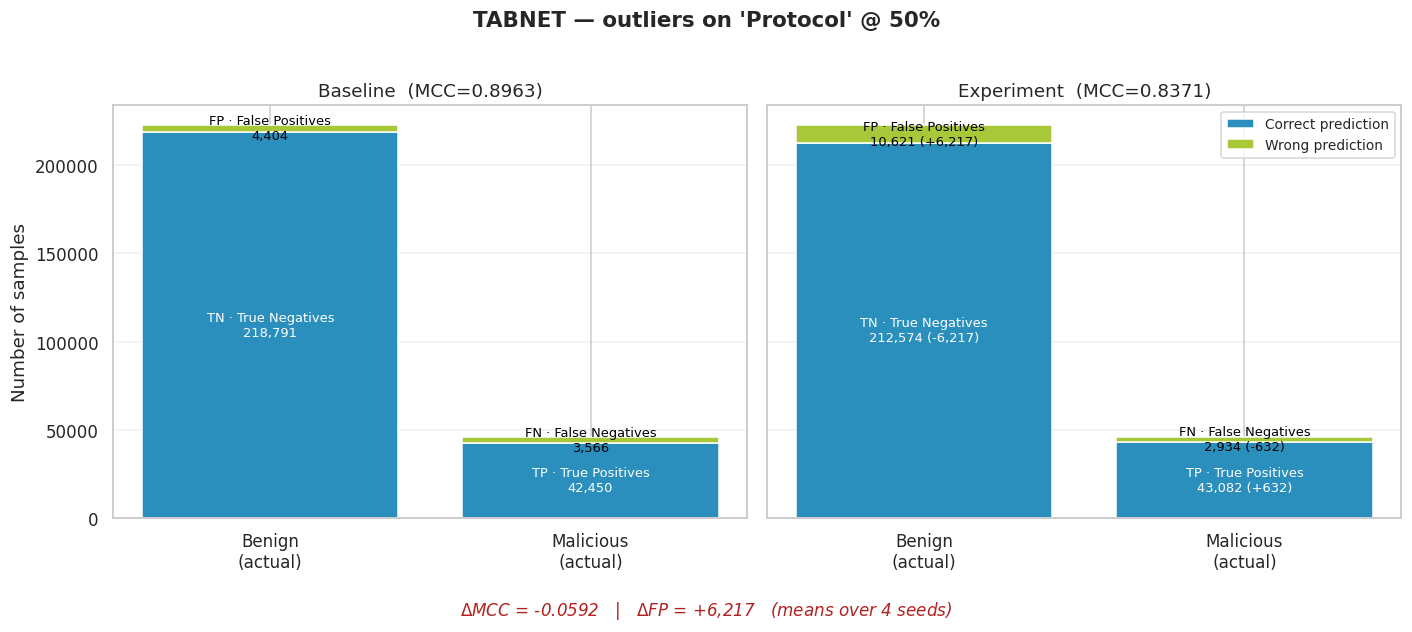

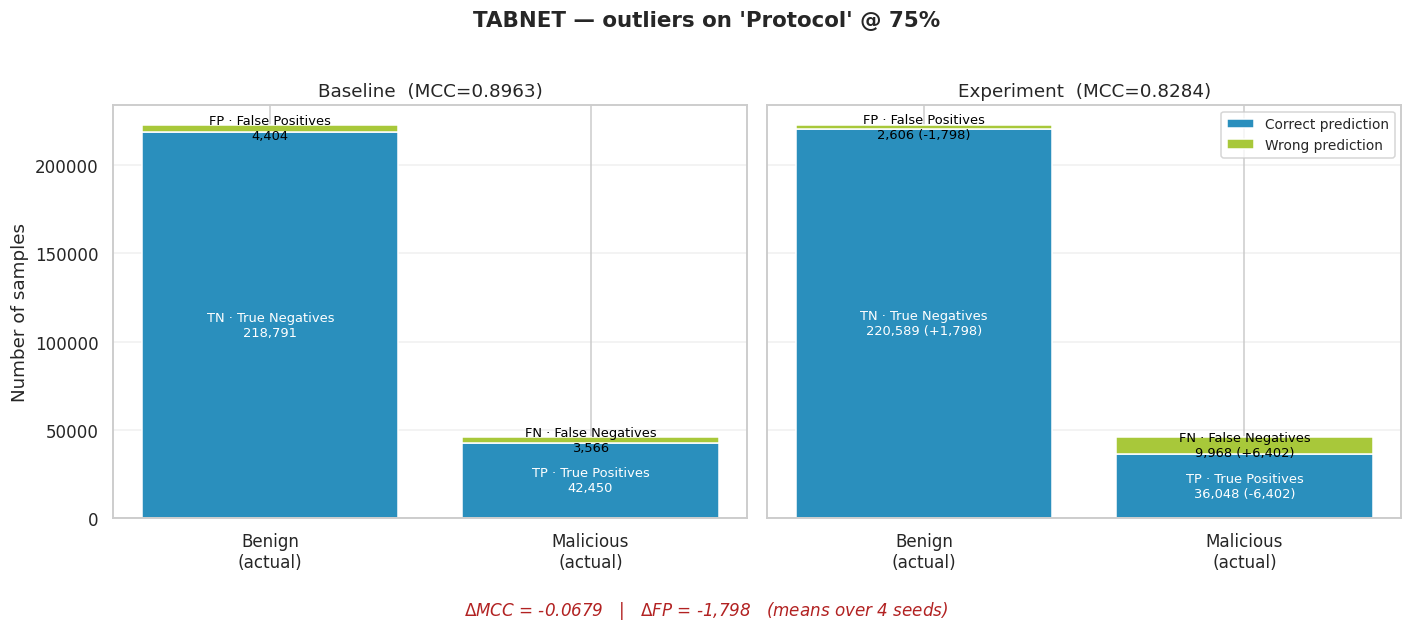

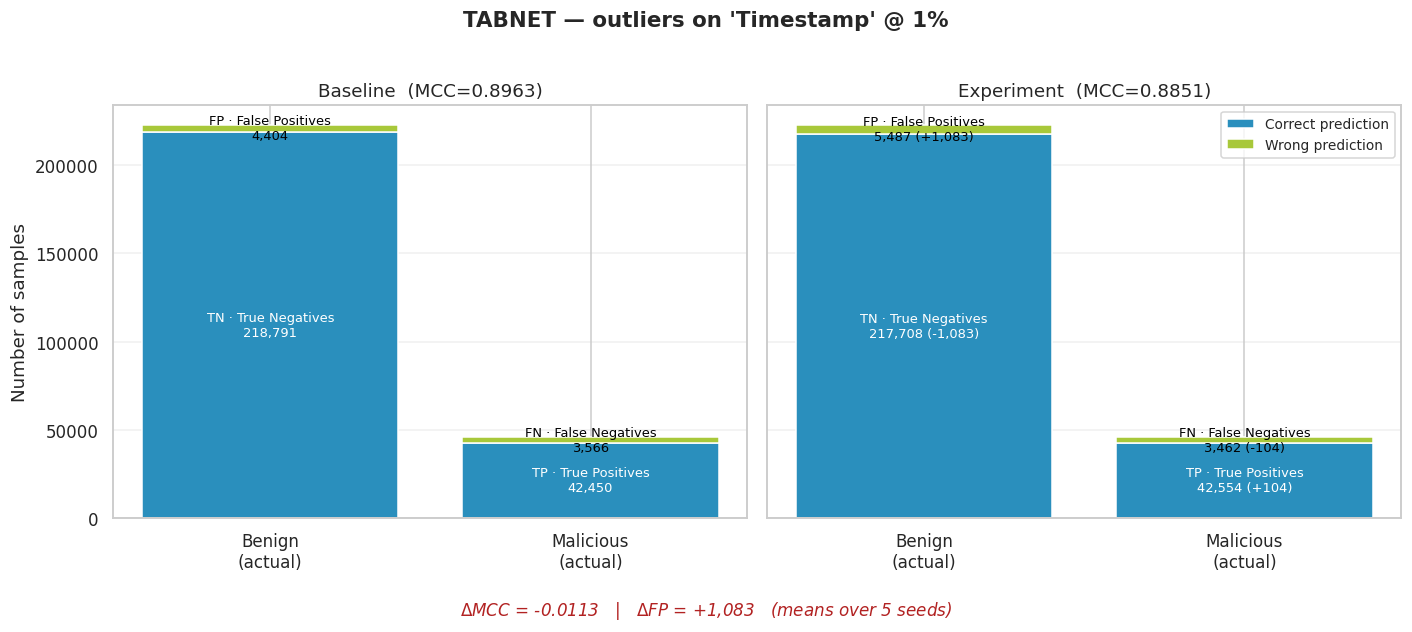

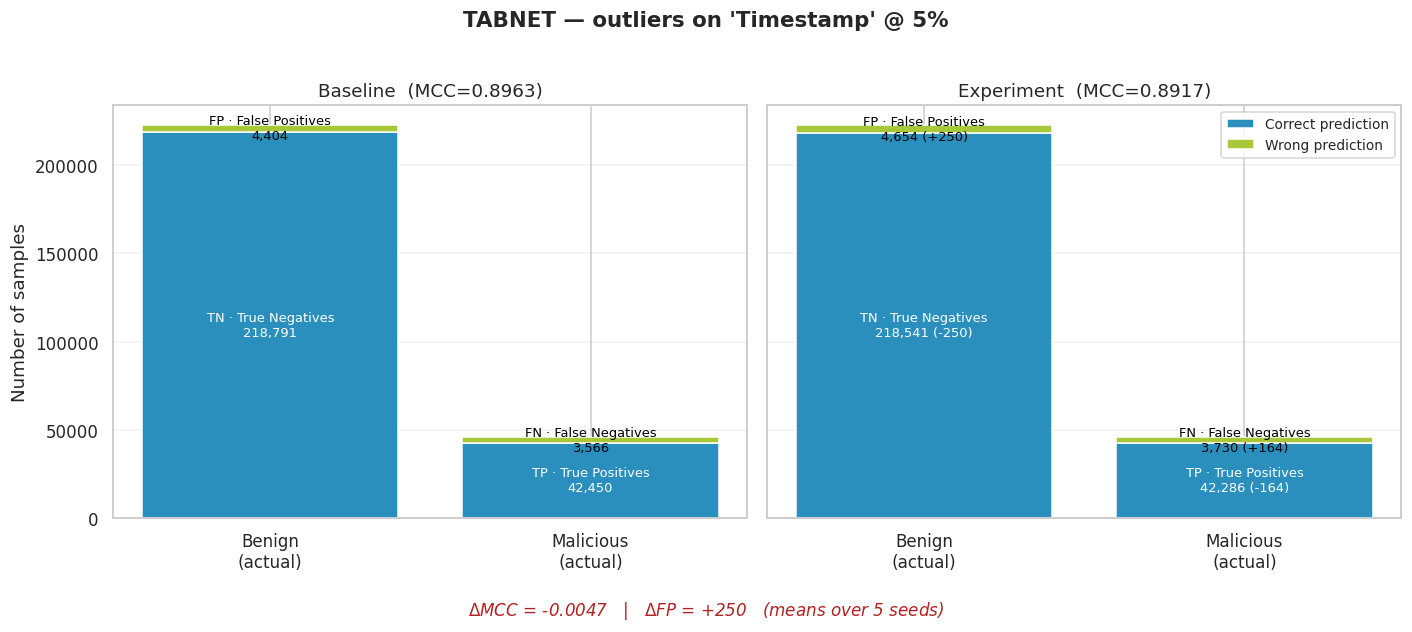

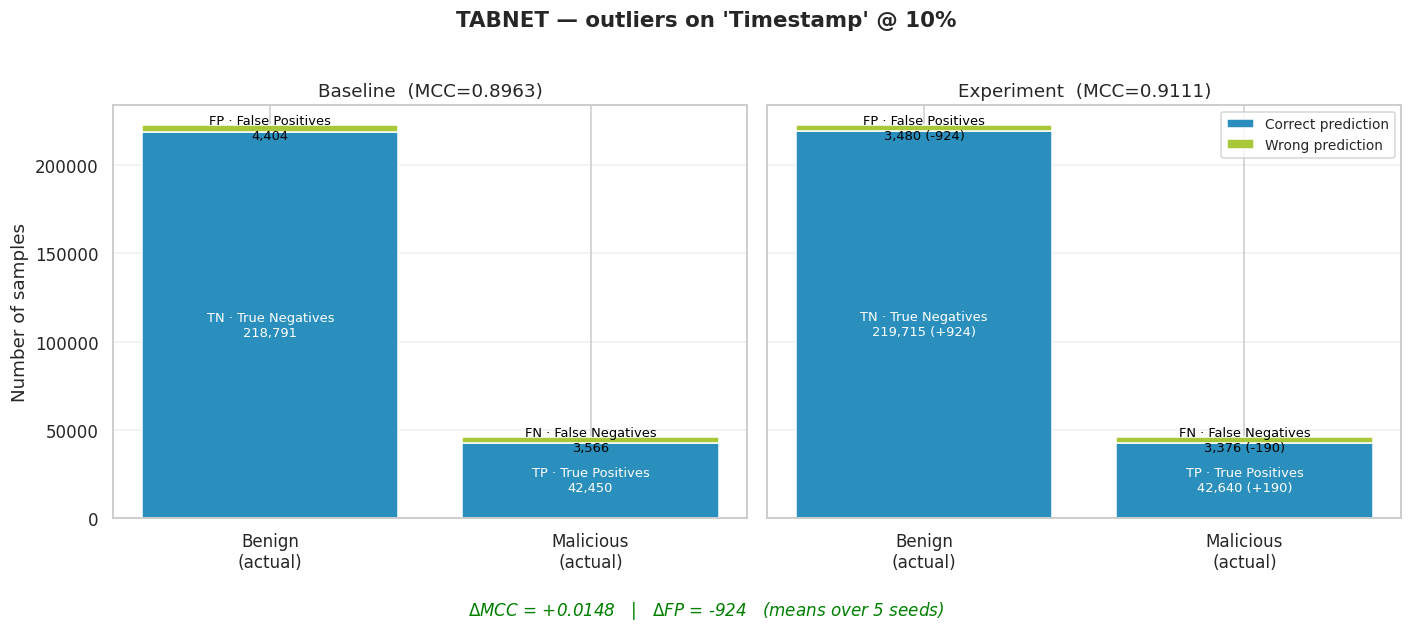

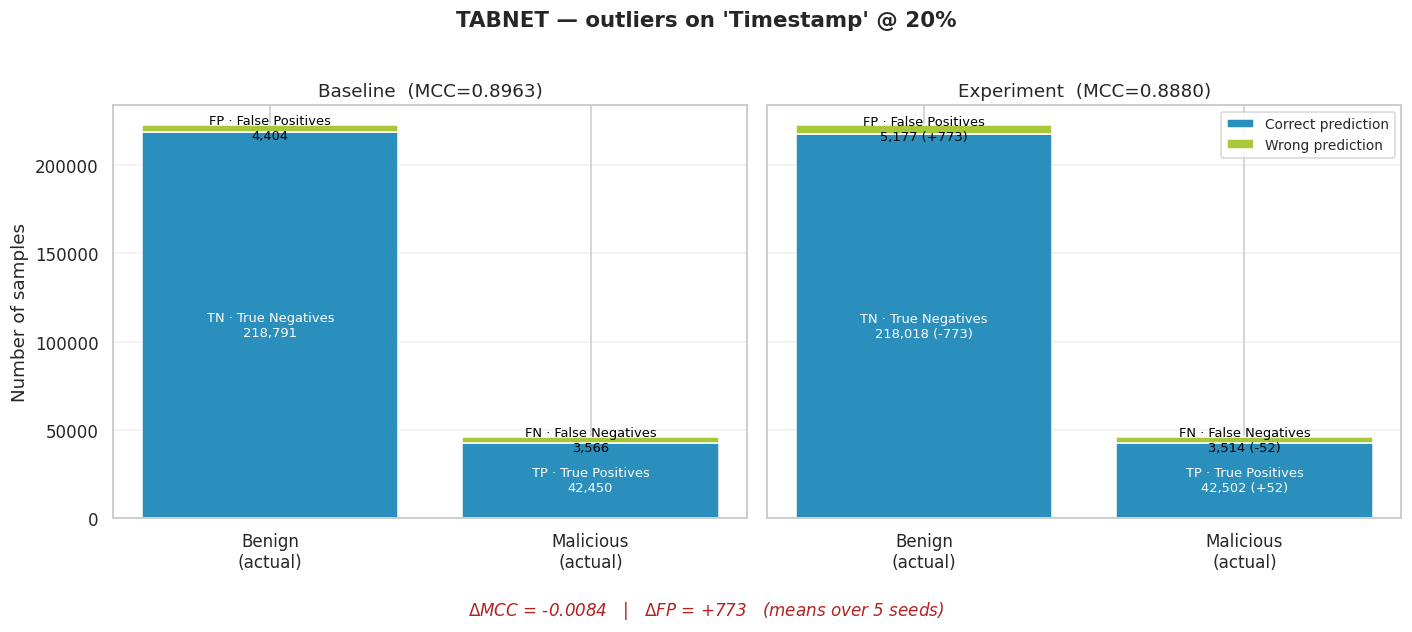

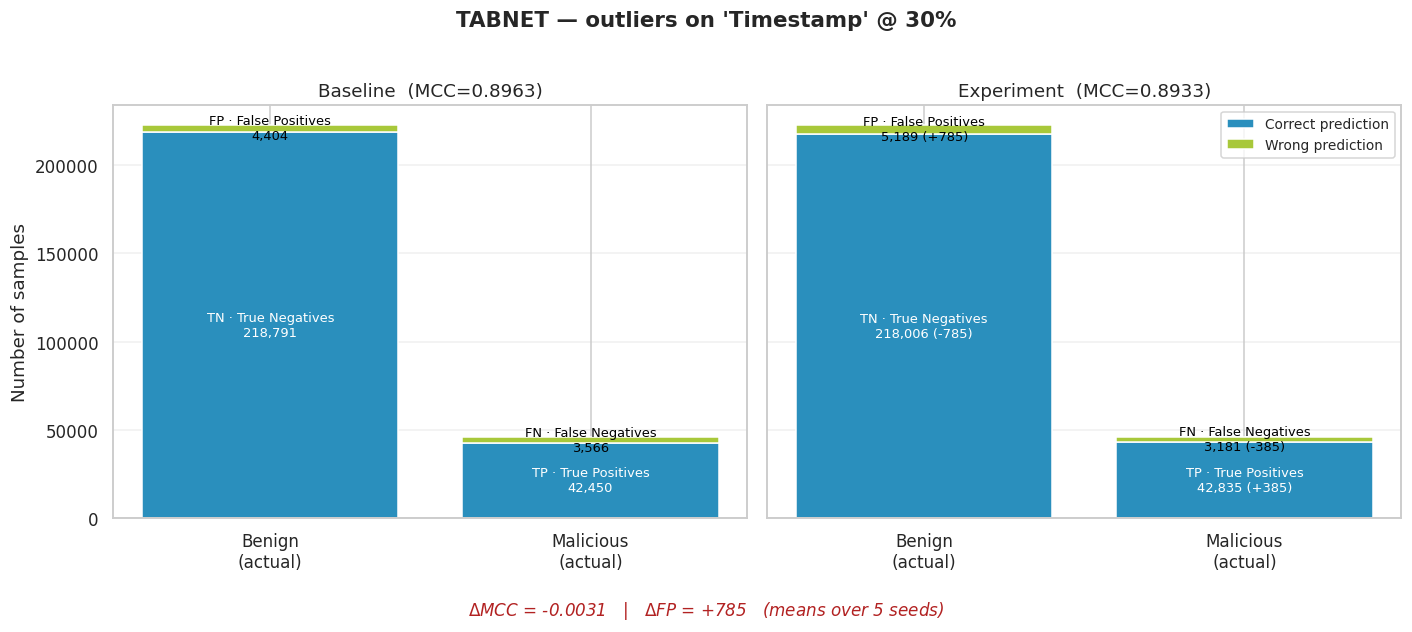

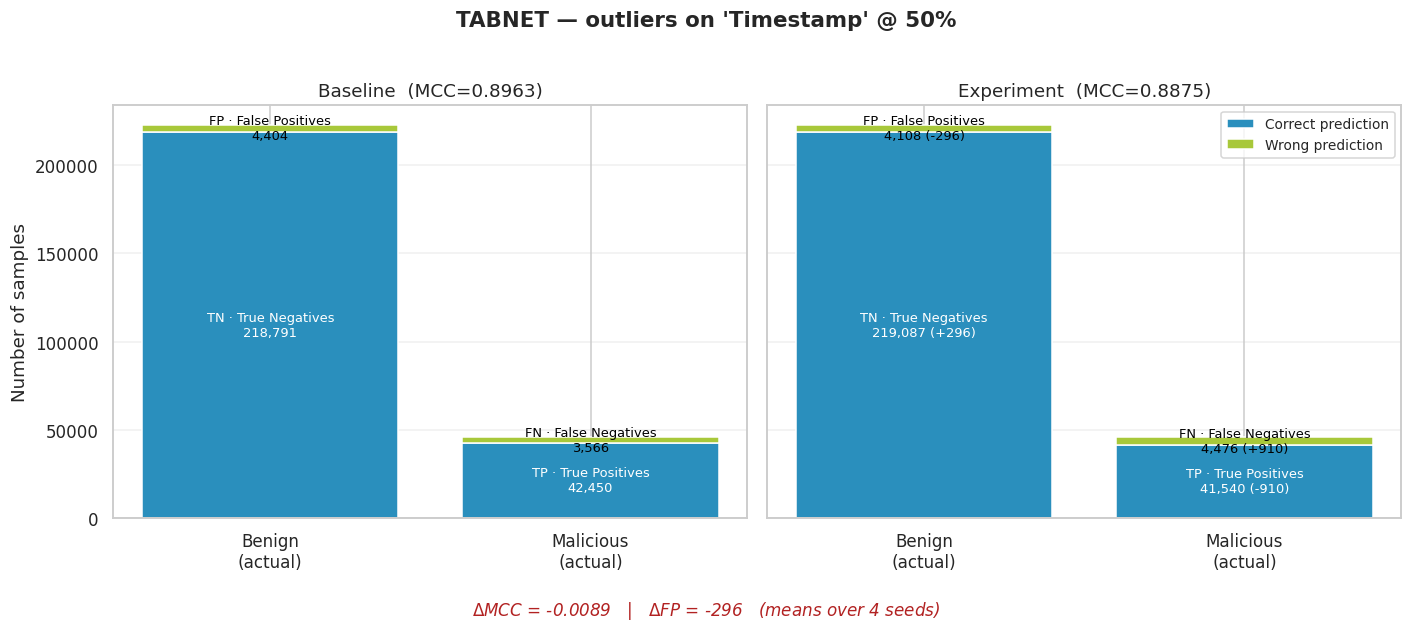

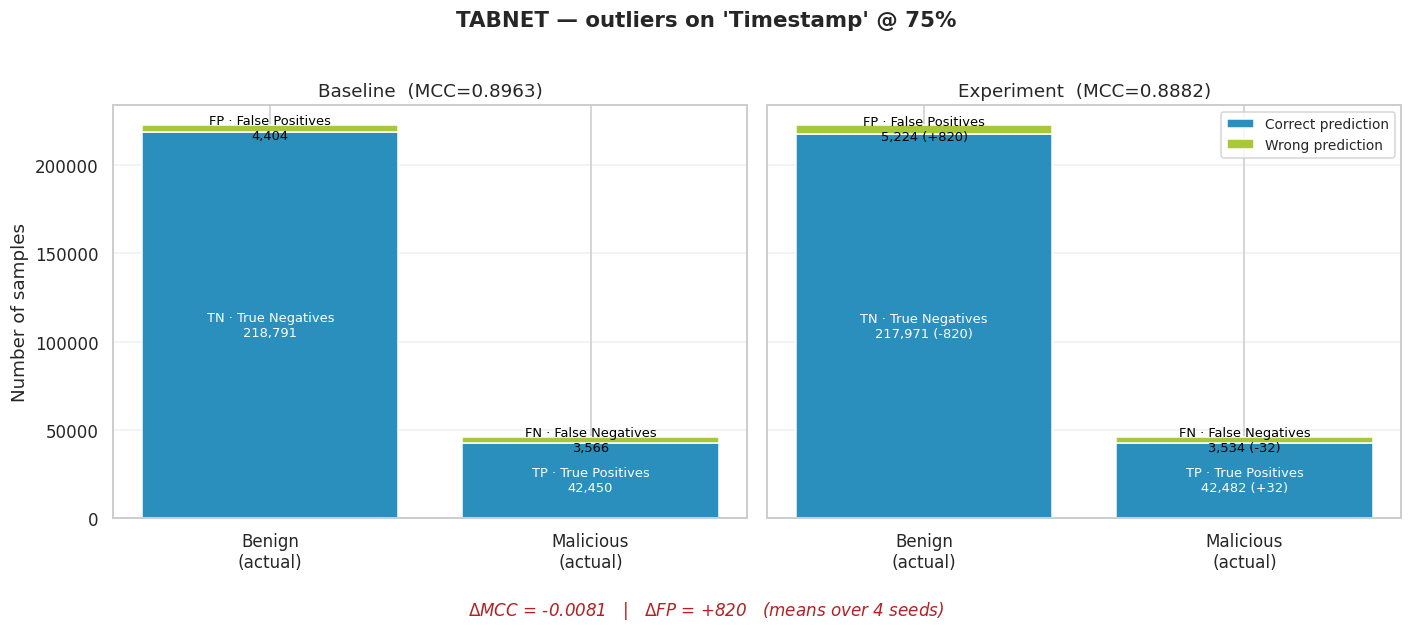

In [44]:
# Choose the PuckTrick method to break down here.
# Options come from the data: missing | outliers | noise | duplicated | labels
CONFUSION_METHOD = "outliers"

cbin = eu.confusion_bin_dataframe(ROOT_DIR)
bcb  = eu.baseline_confusion_bin(ROOT_DIR)
if cbin.empty or bcb.empty:
    print("No confusion-matrix data / baseline available yet.")
elif CONFUSION_METHOD not in set(cbin["method"].dropna().unique()):
    print(f"Method '{CONFUSION_METHOD}' not found. Available:",
          sorted(cbin["method"].dropna().unique()))
else:
    sub = cbin[cbin["method"] == CONFUSION_METHOD]
    for model in sorted(sub["model"].dropna().unique()):
        msub = sub[sub["model"] == model]
        for feature in sorted(msub["feature"].dropna().unique()):
            for pct in sorted(msub[msub["feature"] == feature]
                              ["noise_percentage"].dropna().unique()):
                fig = eu.plot_confusion_breakdown(cbin, bcb, model,
                                                  CONFUSION_METHOD, feature, pct)
                if fig is not None:
                    plt.show()

In [45]:
# Numeric companion: seed-mean TN/FP/FN/TP (+/-CI) and their baseline deltas,
# for the chosen method, per (model, feature, noise level). Also exported to CSV.
if not cbin.empty and not bcb.empty and CONFUSION_METHOD in set(cbin["method"].dropna().unique()):
    tabs = []
    for model in sorted(cbin["model"].dropna().unique()):
        t = eu.confusion_breakdown_table(cbin, bcb, model, CONFUSION_METHOD)
        if not t.empty:
            tabs.append(t)
    if tabs:
        conf_tab = pd.concat(tabs, ignore_index=True)
        out = os.path.join(RESULTS_DIR, f"confusion_breakdown_{CONFUSION_METHOD}.csv")
        conf_tab.to_csv(out, index=False)
        print("[export]", out)
        display(conf_tab[["model", "feature", "noise_percentage", "n",
                          "tn_mean", "fp_mean", "fp_delta",
                          "fn_mean", "fn_delta", "tp_mean",
                          "mcc_mean", "mcc_delta"]].round(3))

[export] evaluation_results/Experiment_A/confusion_breakdown_outliers.csv


,model,feature,noise_percentage,n,tn_mean,fp_mean,fp_delta,fn_mean,fn_delta,tp_mean,mcc_mean,mcc_delta
0,cnn_lstm,Down_Up Ratio,1.0,5,22180.20,150.40,-19.60,1524.80,-217.20,3061.60,0.766,0.036
1,cnn_lstm,Down_Up Ratio,5.0,5,22225.00,105.60,-64.40,1699.60,-42.40,2886.80,0.747,0.017
2,cnn_lstm,Down_Up Ratio,10.0,5,22172.60,158.00,-12.00,1567.20,-174.80,3019.20,0.759,0.029
3,cnn_lstm,Down_Up Ratio,20.0,5,22216.00,114.60,-55.40,1634.40,-107.60,2952.00,0.756,0.025
4,cnn_lstm,Down_Up Ratio,30.0,5,22202.00,128.60,-41.40,1732.80,-9.20,2853.60,0.738,0.008
5,cnn_lstm,Down_Up Ratio,50.0,4,22162.75,168.25,-1.75,1575.50,-166.50,3010.50,0.756,0.026
6,cnn_lstm,Down_Up Ratio,75.0,4,22136.00,195.00,25.00,1574.50,-167.50,3011.50,0.752,0.022
7,cnn_lstm,FIN Flag Cnt,1.0,5,22125.00,205.60,35.60,1579.00,-163.00,3007.40,0.750,0.019
8,cnn_lstm,FIN Flag Cnt,5.0,5,22275.40,55.20,-114.80,1594.80,-147.20,2991.60,0.771,0.041
9,cnn_lstm,FIN Flag Cnt,10.0,5,22224.40,106.20,-63.80,1568.20,-173.80,3018.20,0.767,0.037


---

### Caveats to carry into the write-up

* **Small sample (5 seeds).** Confidence intervals are wide and the Wilcoxon
  test has little power; phrase Experiment A findings as *indicative*. The
  larger Experiment B (`6B`) is where firm conclusions belong.
* **Clean baseline is a single deterministic run** (no seeds), so the
  vs-baseline test (6a) is a one-sample test: it asks whether the *seed
  distribution* of a noisy config sits above/below a fixed clean value.
* **Feature-reduced dataset.** Results here are not directly comparable to
  Experiment B, which keeps the full feature set.